In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway
import pingouin as pg


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [23]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})

In [2]:
light_dark_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_final_part1.h5")
light_dark_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_final_part2.h5")
light_dark = pd.concat([light_dark_1,light_dark_2])

In [4]:
def ts_calculate_relative_distance(df):
    """calculates relative distance of nose to point on obstacle using x-coordinate only"""
    for direction, direction_frame in df.groupby(['odd']):
        for ind, row in direction_frame.iterrows():  
            if direction == 'right':
                try:
                    nose_x = row['ts_nose_x_cm']
                    distances = []
                    for i, x_pos in enumerate(nose_x):
                        obstacle_x = np.mean([row['gt_obstacleTR_x_cm'], row['gt_obstacleBR_x_cm']])
                        
                        # Calculate distance as simple x-coordinate difference
                        distance = x_pos - obstacle_x
                        distances.append(distance)
                        
                except (IndexError, TypeError):
                    distances = [np.nan]
                
                df.at[ind, 'ts_distance_from_edge'] = np.array(distances).astype(object)
                df.at[ind, 'ts_len_distance_from_edge'] = np.array(distances).astype(object).size
                
            if direction == 'left':
                try:
                    nose_x = row['ts_nose_x_cm']
                    distances = []
                    for i, x_pos in enumerate(nose_x):
                        obstacle_x = np.mean([row['gt_obstacleTL_x_cm'], row['gt_obstacleBL_x_cm']])
                        
                        # Calculate distance as simple x-coordinate difference
                        distance = -1*(x_pos - obstacle_x)
                        distances.append(distance)
                        
                except (IndexError, TypeError):
                    distances = [np.nan]
                
                df.at[ind, 'ts_distance_from_edge'] = np.array(distances).astype(object)
                df.at[ind, 'ts_len_distance_from_edge'] = np.array(distances).astype(object).size

In [5]:
def get_mean_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate mean trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both mean and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
   
    
   ## Set distance bins based on turn direction and start position
   #if turn_direction == 'left' and start_position == 'bottom':
   #    distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
   #elif turn_direction == 'right' and start_position == 'bottom':
   #    distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
   #elif turn_direction == 'left' and start_position == 'top':
   #    distance_bins = np.arange(45, 0, -1) 
   #elif turn_direction == 'right' and start_position == 'top':
   #    distance_bins = np.arange(9, 50, 1) 

        # Set distance bins based on turn direction and start position
 
    if turn_direction == 'left':
        distance_bins = np.arange(55, 10, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)   # Right turns from bottom right
  
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate mean trajectory
    mean_trajectory = np.nanmean(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_mean = pd.Series(mean_trajectory)
    valid_mean.fillna(method='bfill', inplace=True)
    valid_mean.fillna(method='ffill', inplace=True)
    mean_trajectory = valid_mean.to_numpy()
    
    if return_matrix:
        return mean_trajectory, trajectory_matrix
    else:
        return mean_trajectory,distance_bins

In [6]:
def get_mean_trajectory(df, x_key: str, y_key: str, 
                         animal_key: str = 'animal',
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate mean trajectory by first averaging within animals, then across animals.
    Interpolates y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - animal_key: Column name containing animal IDs
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both mean and all animal-level trajectories
    
    Returns:
    - Population mean trajectory (mean of animal means)
    - If return_matrix=True: also returns animal-level trajectories and distance bins
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
    
    # Set distance bins based on turn direction and start position
    if turn_direction == 'left':
        distance_bins = np.arange(55, 10, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)   # Right turns from bottom right
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, animal_key, turn_direction_key, start_position_key])
    
    # Get unique animals
    unique_animals = df[animal_key].unique()
    
    # Initialize matrix to store animal-level mean trajectories
    animal_trajectories = np.zeros((len(unique_animals), len(distance_bins)))
    animal_trajectories[:] = np.nan  # Initialize with NaNs
    
    # Process each animal separately
    for animal_idx, animal in enumerate(unique_animals):
        # Get data for this animal
        animal_df = df[df[animal_key] == animal]
        
        # Initialize matrix to store individual trials for this animal
        animal_trials_matrix = np.zeros((len(animal_df), len(distance_bins)))
        animal_trials_matrix[:] = np.nan
        
        # Process each trial for this animal
        for trial_idx, (_, row) in enumerate(animal_df.iterrows()):
            x_original = row[x_key].astype(float)
            y_original = row[y_key].astype(float)
            
            # Remove duplicate x-values (keep first occurrence)
            unique_indices = np.unique(x_original, return_index=True)[1]
            x_unique = x_original[np.sort(unique_indices)]
            y_unique = y_original[np.sort(unique_indices)]
            
            # Only interpolate if we have at least 2 points
            if len(x_unique) >= 2:
                try:
                    interpolator = interp1d(x_unique, y_unique, 
                                          bounds_error=False,
                                          fill_value=np.nan)
                    animal_trials_matrix[trial_idx, :] = interpolator(distance_bins)
                except:
                    continue
        
        # Calculate mean trajectory for this animal (mean across trials)
        animal_mean = np.nanmean(animal_trials_matrix, axis=0)
        
        # Fill NaNs in animal mean with neighboring values
        valid_animal_mean = pd.Series(animal_mean)
        valid_animal_mean.fillna(method='bfill', inplace=True)
        valid_animal_mean.fillna(method='ffill', inplace=True)
        animal_trajectories[animal_idx, :] = valid_animal_mean.to_numpy()
    
    # Calculate population mean trajectory (mean across animals)
    population_mean = np.nanmean(animal_trajectories, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_pop_mean = pd.Series(population_mean)
    valid_pop_mean.fillna(method='bfill', inplace=True)
    valid_pop_mean.fillna(method='ffill', inplace=True)
    population_mean = valid_pop_mean.to_numpy()
    
    if return_matrix:
        return population_mean, animal_trajectories, distance_bins
    else:
        return population_mean, distance_bins


# Alternative simplified version if you want less intermediate storage
def get_mean_trajectory_simple(df, x_key: str, y_key: str, 
                               animal_key: str = 'animal',
                               turn_direction_key: str = 'turn_direction_left_right',
                               start_position_key: str = 'start'):
    """
    Simplified version that calculates mean trajectory by averaging within animals first.
    Returns only the population mean and distance bins.
    """
    # Determine turn direction
    turn_direction = df[turn_direction_key].iloc[0].lower()
    
    # Set distance bins
    if turn_direction == 'left':
        distance_bins = np.arange(55, 10, -1)
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, animal_key, turn_direction_key, start_position_key])
    
    # Dictionary to store animal means
    animal_means_dict = {}
    
    # Process each animal
    for animal in df[animal_key].unique():
        animal_df = df[df[animal_key] == animal]
        animal_trajectories = []
        
        # Process each trial for this animal
        for _, row in animal_df.iterrows():
            x_original = row[x_key].astype(float)
            y_original = row[y_key].astype(float)
            
            # Remove duplicates
            unique_indices = np.unique(x_original, return_index=True)[1]
            x_unique = x_original[np.sort(unique_indices)]
            y_unique = y_original[np.sort(unique_indices)]
            
            if len(x_unique) >= 2:
                try:
                    interpolator = interp1d(x_unique, y_unique, 
                                          bounds_error=False,
                                          fill_value=np.nan)
                    interpolated_y = interpolator(distance_bins)
                    
                    # Clean interpolated values
                    interpolated_series = pd.Series(interpolated_y)
                    interpolated_series.fillna(method='bfill', inplace=True)
                    interpolated_series.fillna(method='ffill', inplace=True)
                    
                    animal_trajectories.append(interpolated_series.to_numpy())
                except:
                    continue
        
        # Calculate mean for this animal if we have valid trajectories
        if animal_trajectories:
            animal_mean = np.nanmean(animal_trajectories, axis=0)
            animal_means_dict[animal] = animal_mean
    
    # Calculate population mean (mean of animal means)
    if animal_means_dict:
        animal_means_array = np.array(list(animal_means_dict.values()))
        population_mean = np.nanmean(animal_means_array, axis=0)
    else:
        # Fallback to original method if no animals have data
        print("Warning: No valid animal trajectories found, using trial-level mean")
        return get_mean_trajectory_original(df, x_key, y_key, turn_direction_key, start_position_key)
    
    return population_mean, distance_bins


# Helper function for fallback
def get_mean_trajectory_original(df, x_key, y_key, turn_direction_key, start_position_key):
    """Original method that doesn't account for animals"""
    turn_direction = df[turn_direction_key].iloc[0].lower()
    
    if turn_direction == 'left':
        distance_bins = np.arange(55, 10, -1)
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan
    
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    mean_trajectory = np.nanmean(trajectory_matrix, axis=0)
    valid_mean = pd.Series(mean_trajectory)
    valid_mean.fillna(method='bfill', inplace=True)
    valid_mean.fillna(method='ffill', inplace=True)
    
    return valid_mean.to_numpy(), distance_bins

In [11]:
def get_median_trajectory(df, x_key: str, y_key: str, 
                         animal_key: str = 'animal',
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by first averaging within animals, then across animals.
    Interpolates y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - animal_key: Column name containing animal IDs
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all animal-level trajectories
    
    Returns:
    - Population median trajectory (median of animal medians)
    - If return_matrix=True: also returns animal-level trajectories and distance bins
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
    
    # Set distance bins based on turn direction and start position
    if turn_direction == 'left':
        distance_bins = np.arange(55, 10, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)   # Right turns from bottom right
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, animal_key, turn_direction_key, start_position_key])
    
    # Get unique animals
    unique_animals = df[animal_key].unique()
    
    # Initialize matrix to store animal-level median trajectories
    animal_trajectories = np.zeros((len(unique_animals), len(distance_bins)))
    animal_trajectories[:] = np.nan  # Initialize with NaNs
    
    # Process each animal separately
    for animal_idx, animal in enumerate(unique_animals):
        # Get data for this animal
        animal_df = df[df[animal_key] == animal]
        
        # Initialize matrix to store individual trials for this animal
        animal_trials_matrix = np.zeros((len(animal_df), len(distance_bins)))
        animal_trials_matrix[:] = np.nan
        
        # Process each trial for this animal
        for trial_idx, (_, row) in enumerate(animal_df.iterrows()):
            x_original = row[x_key].astype(float)
            y_original = row[y_key].astype(float)
            
            # Remove duplicate x-values (keep first occurrence)
            unique_indices = np.unique(x_original, return_index=True)[1]
            x_unique = x_original[np.sort(unique_indices)]
            y_unique = y_original[np.sort(unique_indices)]
            
            # Only interpolate if we have at least 2 points
            if len(x_unique) >= 2:
                try:
                    interpolator = interp1d(x_unique, y_unique, 
                                          bounds_error=False,
                                          fill_value=np.nan)
                    animal_trials_matrix[trial_idx, :] = interpolator(distance_bins)
                except:
                    continue
        
        # Calculate median trajectory for this animal (median across trials)
        animal_median = np.nanmedian(animal_trials_matrix, axis=0)
        
        # Fill NaNs in animal median with neighboring values
        valid_animal_median = pd.Series(animal_median)
        valid_animal_median.fillna(method='bfill', inplace=True)
        valid_animal_median.fillna(method='ffill', inplace=True)
        animal_trajectories[animal_idx, :] = valid_animal_median.to_numpy()
    
    # Calculate population median trajectory (median across animals)
    population_median = np.nanmedian(animal_trajectories, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_pop_median = pd.Series(population_median)
    valid_pop_median.fillna(method='bfill', inplace=True)
    valid_pop_median.fillna(method='ffill', inplace=True)
    population_median = valid_pop_median.to_numpy()
    
    if return_matrix:
        return population_median, animal_trajectories, distance_bins
    else:
        return population_median, distance_bins

In [25]:
ts_calculate_relative_distance(light_dark)

In [4]:
light_dark

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,positive_left_ips,positive_right_ips,negative_peaks,negative_heights,negative_left_ips,negative_right_ips,non_main_head_turn_starts,non_main_head_turn_ends,angles_before_head_turns,angles_after_head_turns
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,"[4.348496372157843, 84.57520408092827]","[16.19392975054704, 89.74667185224443]","[29, 51, 80, 101, 109, 150]","[-3.538385458538178, -6.072763103973279, -15.5...","[25.905246144139266, 47.32339025628978, 75.456...","[32.12845040781993, 54.57613982891745, 82.6354...","[4, 26, 47, 75, 93, 107, 147]","[16, 32, 55, 83, 104, 111, 152]","[6.538167246503866, 30.163775194661955, 9.6389...","[24.572067356337893, 13.206937651525928, 36.12..."
1,1,48059.792371,48066.055564,"[48059.801369, 48059.818099, 48059.834739, 480...","[1015, 1016, 1017, 1018, 1019, 1020, 1021, 102...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[100.70337677001953, 100.96659851074219, 100.9...","[229.06690979003906, 229.2141571044922, 229.14...","[97.77118682861328, 97.44432830810547, 97.2664...",...,"[14.29968179236998, 34.45417430857124, 108.476...","[21.134328939577735, 47.497331594384946, 114.8...","[96, 163]","[-2.413617774709466, -11.687030545744493]","[82.55248376495766, 159.07390765799332]","[102.39349268820607, 168.62908849933083]","[14, 34, 108, 151, 184, 83, 159]","[21, 47, 115, 158, 191, 102, 169]","[5.574090581245366, 76.93902982344129, 107.174...","[55.096723742024594, 116.45118664695975, 119.6..."
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,[121.20229250444804],[124.89723004182653],"[60, 73, 105]","[-2.770484234614008, -2.029725669811883, -5.38...","[49.027626511169174, 70.0490124411182, 101.532...","[63.70320204647564, 75.23238818008673, 109.858...","[121, 49, 70]","[125, 64, 75]","[14.16310612904111, 56.966866792285025, 42.624...","[49.773470466177024, 36.57290635336601, 38.631..."
3,3,48070.369088,48076.550553,"[48070.37175, 48070.388352, 48070.40526, 48070...","[1649, 1650, 1651, 1652, 1653, 1654, 1655, 165...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[102.01713562011719, 102.3261489868164, 102.09...","[225.12435913085938, 225.2169189453125, 225.56...","[97.98050689697266, 98.4389877319336, 98.42494...",...,"[27.244918924558764, 53.3115602295209, 143.401...","[39.43742784770508, 60.374004770466016, 177.02...","[11, 69, 182]","[-2.5443679094536087, -3.6578902681437153, -72...","[8.573024614211446, 63.715550619300544, 179.07...","[14.41270127641714, 143.4012321586152, 184.978...","[27, 53, 143, 9, 64]","[39, 60, 177, 14, 143]","[110.36781416942407, 72.28972193611615, 15.398...","[74.24863955900334, 88.01691168966701, 67.8248..."
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.0059814453125, 654.872...",...,[],[],[],[],[],[],[nan],[nan],[nan],[nan]
...,...,...,.

In [5]:
data = pd.concat([light_dark])


light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

print(len(light))

print(len(dark))

8881
5672


In [6]:
data = pd.concat([light_dark])
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0] 
data = data[data.intial_distance<=15] 

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

print(len(light))

print(len(dark))



2214
1456


In [28]:
675270/2708705

0.24929625042224976

In [29]:
444080/1729960

0.2566995768688293

ANIMAL-LEVEL ANALYSIS SUMMARY

LIGHT CONDITION:
Number of animals: 13
Mean tortuosity (animal means): 1.293 ± 0.013

DARK CONDITION:
Number of animals: 13
Mean tortuosity (animal means): 1.375 ± 0.017


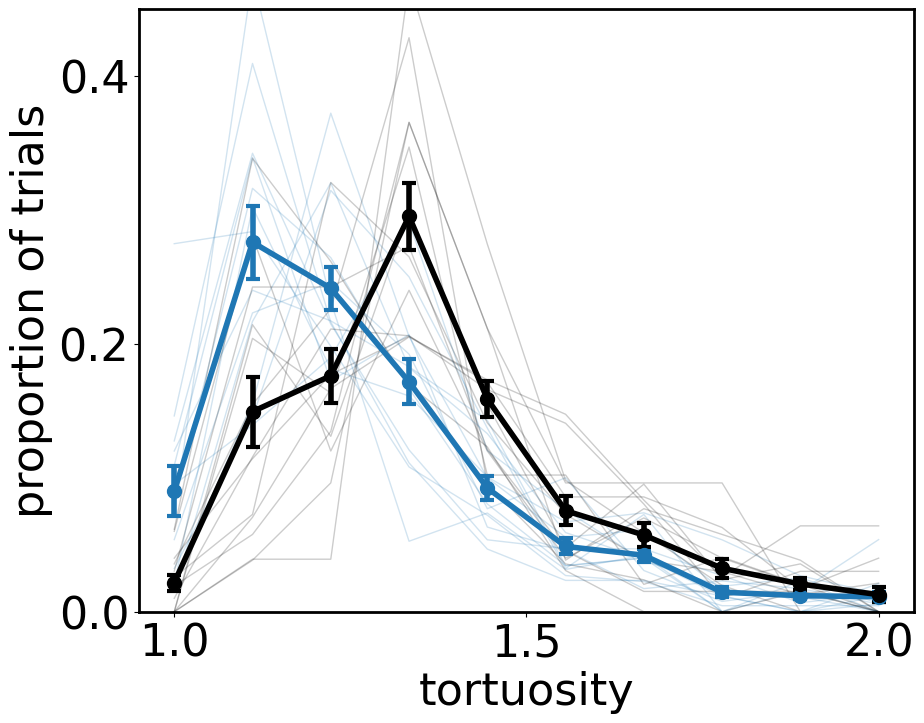


STATISTICAL COMPARISON (animal-level means)

Mean tortuosity comparison:
Light: 1.293 ± 0.013 (n=13)
Dark:  1.375 ± 0.017 (n=13)
t = -3.896, p = 0.0008
✓ SIGNIFICANT difference between conditions

SUMMARY TABLE

Condition  Animals    Trials     Mean ± SEM     
---------------------------------------------
Light      13         2214       1.293 ± 0.013
Dark       13         1456       1.375 ± 0.017


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])

# Filtering
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0] 
data = data[data.intial_distance<=15] 

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Process light condition
light = data[data.task == 'oa']

# Process individual animals for light condition
light_animal_hists = []  # Store histograms for each animal
light_lines = []  # Store lines for plotting
light_means = []  # Store mean tortuosity for each animal

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    # Skip animals with no data
    if len(ani_light_dists) == 0:
        continue
    
    counts, bins = np.histogram(ani_light_dists, bins=10, range=(1, 2))
    
    # Calculate proportion for this animal
    if sum(counts) > 0:
        prob = counts / sum(counts)
    else:
        prob = np.zeros_like(counts).astype(float)
    
    light_animal_hists.append(prob)
    light_means.append(np.nanmean(ani_light_dists))
    
    # Store for line plots
    light_lines.append((xnew, prob, ani))

# Convert to array for calculations
light_animal_hists = np.array(light_animal_hists)

# Calculate POPULATION MEAN as mean of animal means (not from pooled data!)
if len(light_animal_hists) > 0:
    light_pop_mean = np.nanmean(light_animal_hists, axis=0)
    
    # Calculate SEM across animals (proper error bars)
    light_sem = np.nanstd(light_animal_hists, axis=0) / np.sqrt(
        np.sum(~np.isnan(light_animal_hists), axis=0))
else:
    light_pop_mean = np.zeros(10)
    light_sem = np.zeros(10)

# Process dark condition
dark = data[data.task == 'oadark']

# Process individual animals for dark condition
dark_animal_hists = []  # Store histograms for each animal
dark_lines = []  # Store lines for plotting
dark_means = []  # Store mean tortuosity for each animal

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    # Skip animals with no data
    if len(ani_dark_dists) == 0:
        continue
    
    counts, bins = np.histogram(ani_dark_dists, bins=10, range=(1, 2))
    
    # Calculate proportion for this animal
    if sum(counts) > 0:
        prob = counts / sum(counts)
    else:
        prob = np.zeros_like(counts).astype(float)
    
    dark_animal_hists.append(prob)
    dark_means.append(np.nanmean(ani_dark_dists))
    
    # Store for line plots
    dark_lines.append((xnew, prob, ani))

# Convert to array for calculations
dark_animal_hists = np.array(dark_animal_hists)

# Calculate POPULATION MEAN as mean of animal means
if len(dark_animal_hists) > 0:
    dark_pop_mean = np.nanmean(dark_animal_hists, axis=0)
    
    # Calculate SEM across animals (proper error bars)
    dark_sem = np.nanstd(dark_animal_hists, axis=0) / np.sqrt(
        np.sum(~np.isnan(dark_animal_hists), axis=0))
else:
    dark_pop_mean = np.zeros(10)
    dark_sem = np.zeros(10)

# Print summary statistics
print("=" * 60)
print("ANIMAL-LEVEL ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nLIGHT CONDITION:")
print(f"Number of animals: {len(light_animal_hists)}")
if len(light_means) > 0:
    print(f"Mean tortuosity (animal means): {np.mean(light_means):.3f} ± {np.std(light_means, ddof=1)/np.sqrt(len(light_means)):.3f}")

print(f"\nDARK CONDITION:")
print(f"Number of animals: {len(dark_animal_hists)}")
if len(dark_means) > 0:
    print(f"Mean tortuosity (animal means): {np.mean(dark_means):.3f} ± {np.std(dark_means, ddof=1)/np.sqrt(len(dark_means)):.3f}")

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.2, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.2, linewidth=1, zorder=1)

# Plot POPULATION MEAN lines with SEM error bars (from animal means)
ax.errorbar(xnew, light_pop_mean, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='light', zorder=5)

ax.errorbar(xnew, dark_pop_mean, yerr=dark_sem,
           fmt='-o', color='black', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('proportion of trials', fontweight='normal')
ax.set_xlabel('tortuosity', fontweight='normal')
ax.set_ylim([0, 0.45])  # Adjust if needed



plt.tight_layout()

# Show the plot
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\tortuosity_lines_short_1.pdf", 
#           dpi=300, transparent=True)
plt.show()

# ============================================================================
# STATISTICAL COMPARISON (animal-level means)
# ============================================================================
print("\n" + "=" * 60)
print("STATISTICAL COMPARISON (animal-level means)")
print("=" * 60)

if len(light_means) > 1 and len(dark_means) > 1:
    # Independent t-test (different animals in each condition)
    t_stat, p_val = stats.ttest_ind(light_means, dark_means, equal_var=False)
    
    print(f"\nMean tortuosity comparison:")
    print(f"Light: {np.mean(light_means):.3f} ± {np.std(light_means, ddof=1)/np.sqrt(len(light_means)):.3f} (n={len(light_means)})")
    print(f"Dark:  {np.mean(dark_means):.3f} ± {np.std(dark_means, ddof=1)/np.sqrt(len(dark_means)):.3f} (n={len(dark_means)})")
    print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
    
    if p_val < 0.05:
        print("✓ SIGNIFICANT difference between conditions")
    else:
        print("✗ NO significant difference between conditions")
else:
    print("\n⚠️  Not enough animals for statistical comparison")
    print(f"Light animals: {len(light_means)}, Dark animals: {len(dark_means)}")

# ============================================================================
# BONUS: Create a summary table
# ============================================================================
print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)

print(f"\n{'Condition':<10} {'Animals':<10} {'Trials':<10} {'Mean ± SEM':<15}")
print("-" * 45)

# Count total trials for each condition
light_trials = len(light_dist) if 'light_dist' in locals() else len(light)
dark_trials = len(dark_dist) if 'dark_dist' in locals() else len(dark)

print(f"{'Light':<10} {len(light_means):<10} {light_trials:<10} {np.mean(light_means):.3f} ± {np.std(light_means, ddof=1)/np.sqrt(len(light_means)):.3f}")
print(f"{'Dark':<10} {len(dark_means):<10} {dark_trials:<10} {np.mean(dark_means):.3f} ± {np.std(dark_means, ddof=1)/np.sqrt(len(dark_means)):.3f}")

In [11]:
light_dark.date_index.unique()

array([0., 1., 2., 4., 3., 5., 6.])

ANIMAL-LEVEL ANALYSIS SUMMARY

LIGHT CONDITION:
Number of animals: 13
Mean tortuosity (animal means): 1.220 ± 0.007

DARK CONDITION:
Number of animals: 4
Mean tortuosity (animal means): 1.302 ± 0.022


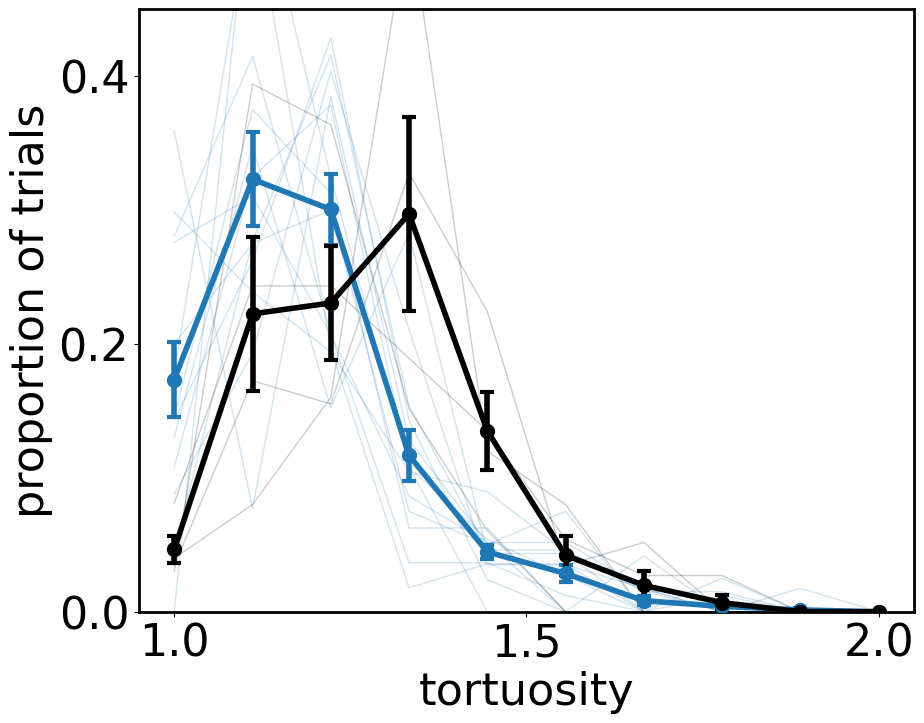


STATISTICAL COMPARISON (animal-level means)

Mean tortuosity comparison:
Light: 1.220 ± 0.007 (n=13)
Dark:  1.302 ± 0.022 (n=4)
t = -3.524, p = 0.0277
✓ SIGNIFICANT difference between conditions

SUMMARY TABLE

Condition  Animals    Trials     Mean ± SEM     
---------------------------------------------
Light      13         676        1.220 ± 0.007
Dark       4          160        1.302 ± 0.022


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])

# Filtering
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0] 
data = data[data.intial_distance>=15] 
data = data[data.date_index>4] 

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Process light condition
light = data[data.task == 'oa']

# Process individual animals for light condition
light_animal_hists = []  # Store histograms for each animal
light_lines = []  # Store lines for plotting
light_means = []  # Store mean tortuosity for each animal

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    # Skip animals with no data
    if len(ani_light_dists) == 0:
        continue
    
    counts, bins = np.histogram(ani_light_dists, bins=10, range=(1, 2))
    
    # Calculate proportion for this animal
    if sum(counts) > 0:
        prob = counts / sum(counts)
    else:
        prob = np.zeros_like(counts).astype(float)
    
    light_animal_hists.append(prob)
    light_means.append(np.nanmean(ani_light_dists))
    
    # Store for line plots
    light_lines.append((xnew, prob, ani))

# Convert to array for calculations
light_animal_hists = np.array(light_animal_hists)

# Calculate POPULATION MEAN as mean of animal means (not from pooled data!)
if len(light_animal_hists) > 0:
    light_pop_mean = np.nanmean(light_animal_hists, axis=0)
    
    # Calculate SEM across animals (proper error bars)
    light_sem = np.nanstd(light_animal_hists, axis=0) / np.sqrt(
        np.sum(~np.isnan(light_animal_hists), axis=0))
else:
    light_pop_mean = np.zeros(10)
    light_sem = np.zeros(10)

# Process dark condition
dark = data[data.task == 'oadark']

# Process individual animals for dark condition
dark_animal_hists = []  # Store histograms for each animal
dark_lines = []  # Store lines for plotting
dark_means = []  # Store mean tortuosity for each animal

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    # Skip animals with no data
    if len(ani_dark_dists) == 0:
        continue
    
    counts, bins = np.histogram(ani_dark_dists, bins=10, range=(1, 2))
    
    # Calculate proportion for this animal
    if sum(counts) > 0:
        prob = counts / sum(counts)
    else:
        prob = np.zeros_like(counts).astype(float)
    
    dark_animal_hists.append(prob)
    dark_means.append(np.nanmean(ani_dark_dists))
    
    # Store for line plots
    dark_lines.append((xnew, prob, ani))

# Convert to array for calculations
dark_animal_hists = np.array(dark_animal_hists)

# Calculate POPULATION MEAN as mean of animal means
if len(dark_animal_hists) > 0:
    dark_pop_mean = np.nanmean(dark_animal_hists, axis=0)
    
    # Calculate SEM across animals (proper error bars)
    dark_sem = np.nanstd(dark_animal_hists, axis=0) / np.sqrt(
        np.sum(~np.isnan(dark_animal_hists), axis=0))
else:
    dark_pop_mean = np.zeros(10)
    dark_sem = np.zeros(10)

# Print summary statistics
print("=" * 60)
print("ANIMAL-LEVEL ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nLIGHT CONDITION:")
print(f"Number of animals: {len(light_animal_hists)}")
if len(light_means) > 0:
    print(f"Mean tortuosity (animal means): {np.mean(light_means):.3f} ± {np.std(light_means, ddof=1)/np.sqrt(len(light_means)):.3f}")

print(f"\nDARK CONDITION:")
print(f"Number of animals: {len(dark_animal_hists)}")
if len(dark_means) > 0:
    print(f"Mean tortuosity (animal means): {np.mean(dark_means):.3f} ± {np.std(dark_means, ddof=1)/np.sqrt(len(dark_means)):.3f}")

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.2, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.2, linewidth=1, zorder=1)

# Plot POPULATION MEAN lines with SEM error bars (from animal means)
ax.errorbar(xnew, light_pop_mean, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='light', zorder=5)

ax.errorbar(xnew, dark_pop_mean, yerr=dark_sem,
           fmt='-o', color='black', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('proportion of trials', fontweight='normal')
ax.set_xlabel('tortuosity', fontweight='normal')
ax.set_ylim([0, 0.45])  # Adjust if needed


plt.tight_layout()

# Show the plot
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\tortuosity_lines_1.pdf", 
#           dpi=300, transparent=True)

plt.show()

# ============================================================================
# STATISTICAL COMPARISON (animal-level means)
# ============================================================================
print("\n" + "=" * 60)
print("STATISTICAL COMPARISON (animal-level means)")
print("=" * 60)

if len(light_means) > 1 and len(dark_means) > 1:
    # Independent t-test (different animals in each condition)
    t_stat, p_val = stats.ttest_ind(light_means, dark_means, equal_var=False)
    
    print(f"\nMean tortuosity comparison:")
    print(f"Light: {np.mean(light_means):.3f} ± {np.std(light_means, ddof=1)/np.sqrt(len(light_means)):.3f} (n={len(light_means)})")
    print(f"Dark:  {np.mean(dark_means):.3f} ± {np.std(dark_means, ddof=1)/np.sqrt(len(dark_means)):.3f} (n={len(dark_means)})")
    print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
    
    if p_val < 0.05:
        print("✓ SIGNIFICANT difference between conditions")
    else:
        print("✗ NO significant difference between conditions")
else:
    print("\n⚠️  Not enough animals for statistical comparison")
    print(f"Light animals: {len(light_means)}, Dark animals: {len(dark_means)}")

# ============================================================================
# BONUS: Create a summary table
# ============================================================================
print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)

print(f"\n{'Condition':<10} {'Animals':<10} {'Trials':<10} {'Mean ± SEM':<15}")
print("-" * 45)

# Count total trials for each condition
light_trials = len(light_dist) if 'light_dist' in locals() else len(light)
dark_trials = len(dark_dist) if 'dark_dist' in locals() else len(dark)

print(f"{'Light':<10} {len(light_means):<10} {light_trials:<10} {np.mean(light_means):.3f} ± {np.std(light_means, ddof=1)/np.sqrt(len(light_means)):.3f}")
print(f"{'Dark':<10} {len(dark_means):<10} {dark_trials:<10} {np.mean(dark_means):.3f} ± {np.std(dark_means, ddof=1)/np.sqrt(len(dark_means)):.3f}")

In [94]:
flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())

array([23.774760141808805, 23.395250978056566, 23.270437619444856, ...,
       -24.106907440837475, -24.186412768461857, -24.21477961109938],
      dtype=object)

DISTANCE TO OBSTACLE - ANIMAL-LEVEL ANALYSIS

LIGHT CONDITION:
Number of animals: 13
  Animal G8CK1LN: mean distance = 8.71 cm
  Animal G8CK1LT: mean distance = 9.85 cm
  Animal G8CK1RT: mean distance = 7.96 cm
  Animal G8CK1TT: mean distance = 8.82 cm
  Animal G8CKLN: mean distance = 8.49 cm
  Animal G8CKLT: mean distance = 9.44 cm
  Animal G8CKRN: mean distance = 9.05 cm
  Animal G8CKRT: mean distance = 9.10 cm
  Animal G8CKTT: mean distance = 9.59 cm
  Animal J701LT: mean distance = 8.78 cm
  Animal J701NN: mean distance = 8.34 cm
  Animal J701RN: mean distance = 9.31 cm
  Animal J701RT: mean distance = 8.05 cm

DARK CONDITION:
Number of animals: 13
  Animal G8CK1LN: mean distance = 9.00 cm
  Animal G8CK1LT: mean distance = 8.42 cm
  Animal G8CK1RT: mean distance = 7.95 cm
  Animal G8CK1TT: mean distance = 8.45 cm
  Animal G8CKLN: mean distance = 7.24 cm
  Animal G8CKLT: mean distance = 7.79 cm
  Animal G8CKRN: mean distance = 7.13 cm
  Animal G8CKRT: mean distance = 7.78 cm
  Anima

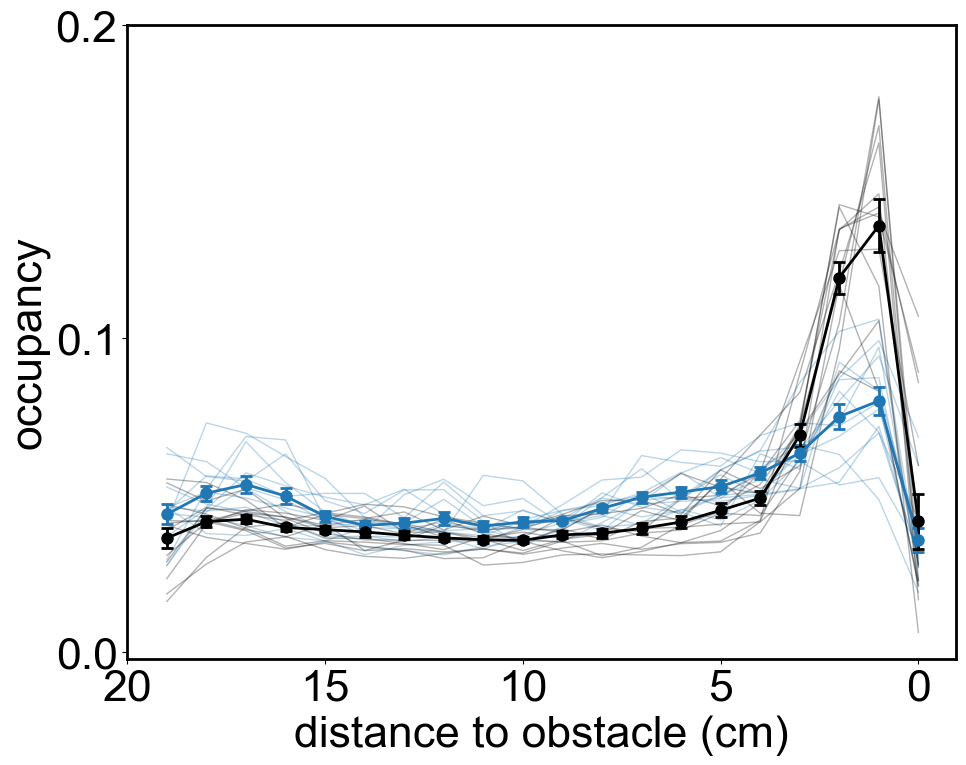


SUMMARY TABLE

Condition  Animals    Time Samples    Mean Dist (cm) 
--------------------------------------------------
Light      13         176648          8.88 ± 0.16
Dark       13         99042           7.77 ± 0.18


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

xnew = np.arange(0, 20, 1)
data = pd.concat([light_dark]) 
#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]  

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'normal', 'size': 18}
plt.rc('font', **font)

# Helper function to flatten arrays
def flatten_list_of_arrays(arr_list):
    """Flatten a list of arrays or a numpy array of arrays"""
    if isinstance(arr_list, np.ndarray) and arr_list.dtype == object:
        return np.concatenate(arr_list)
    elif isinstance(arr_list, list):
        return np.concatenate(arr_list)
    else:
        return arr_list

# Process light condition
light = data[data.task == 'oa']

# Process individual animals for light condition
light_animal_hists = []  # Store histograms for each animal
light_lines = []  # Store lines for plotting

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    
    # Skip animals with no data
    if len(ani_light_dists) == 0:
        continue
    
    counts, bins = np.histogram(ani_light_dists, bins=20, range=(0, 20))
    
    # Calculate proportion for this animal
    if sum(counts) > 0:
        prob = counts / sum(counts)
    else:
        prob = np.zeros(20).astype(float)
    
    light_animal_hists.append(prob)
    
    # Store for line plots
    light_lines.append((xnew, prob, ani))

# Convert to array for calculations
light_animal_hists = np.array(light_animal_hists)

# Calculate POPULATION MEAN as mean of animal means
if len(light_animal_hists) > 0:
    light_pop_mean = np.nanmean(light_animal_hists, axis=0)
    
    # Calculate SEM across animals (proper error bars)
    light_sem = np.nanstd(light_animal_hists, axis=0) / np.sqrt(
        np.sum(~np.isnan(light_animal_hists), axis=0))
else:
    light_pop_mean = np.zeros(20)
    light_sem = np.zeros(20)

# Process dark condition
dark = data[data.task == 'oadark']

# Process individual animals for dark condition
dark_animal_hists = []  # Store histograms for each animal
dark_lines = []  # Store lines for plotting

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    
    # Skip animals with no data
    if len(ani_dark_dists) == 0:
        continue
    
    counts, bins = np.histogram(ani_dark_dists, bins=20, range=(0, 20))
    
    # Calculate proportion for this animal
    if sum(counts) > 0:
        prob = counts / sum(counts)
    else:
        prob = np.zeros(20).astype(float)
    
    dark_animal_hists.append(prob)
    
    # Store for line plots
    dark_lines.append((xnew, prob, ani))

# Convert to array for calculations
dark_animal_hists = np.array(dark_animal_hists)

# Calculate POPULATION MEAN as mean of animal means
if len(dark_animal_hists) > 0:
    dark_pop_mean = np.nanmean(dark_animal_hists, axis=0)
    
    # Calculate SEM across animals (proper error bars)
    dark_sem = np.nanstd(dark_animal_hists, axis=0) / np.sqrt(
        np.sum(~np.isnan(dark_animal_hists), axis=0))
else:
    dark_pop_mean = np.zeros(20)
    dark_sem = np.zeros(20)

# Print summary statistics
print("=" * 60)
print("DISTANCE TO OBSTACLE - ANIMAL-LEVEL ANALYSIS")
print("=" * 60)

# Calculate mean distance for each animal
light_mean_distances = []
dark_mean_distances = []

print(f"\nLIGHT CONDITION:")
print(f"Number of animals: {len(light_animal_hists)}")
for i, (x, y, animal) in enumerate(light_lines):
    # Calculate weighted mean distance for this animal
    if len(y) > 0 and np.sum(y) > 0:
        mean_dist = np.average(xnew, weights=y)
        light_mean_distances.append(mean_dist)
        print(f"  Animal {animal}: mean distance = {mean_dist:.2f} cm")

print(f"\nDARK CONDITION:")
print(f"Number of animals: {len(dark_animal_hists)}")
for i, (x, y, animal) in enumerate(dark_lines):
    # Calculate weighted mean distance for this animal
    if len(y) > 0 and np.sum(y) > 0:
        mean_dist = np.average(xnew, weights=y)
        dark_mean_distances.append(mean_dist)
        print(f"  Animal {animal}: mean distance = {mean_dist:.2f} cm")

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot POPULATION MEAN lines with SEM error bars (from animal means)
ax.errorbar(xnew, light_pop_mean, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light', zorder=5)

ax.errorbar(xnew, dark_pop_mean, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('occupancy', fontsize=32, fontweight='normal')
ax.set_xlabel('distance to obstacle (cm)', fontsize=32, fontweight='normal')
ax.invert_xaxis()



plt.tight_layout()

# ============================================================================
# STATISTICAL COMPARISON (animal-level means)
# ============================================================================
print("\n" + "=" * 60)
print("STATISTICAL ANALYSIS")
print("=" * 60)

if len(light_mean_distances) > 1 and len(dark_mean_distances) > 1:
    # Independent t-test (different animals in each condition)
    t_stat, p_val = stats.ttest_ind(light_mean_distances, dark_mean_distances, equal_var=False)
    
    print(f"\nMean distance to obstacle comparison:")
    print(f"Light: {np.mean(light_mean_distances):.2f} ± {np.std(light_mean_distances, ddof=1)/np.sqrt(len(light_mean_distances)):.2f} cm (n={len(light_mean_distances)})")
    print(f"Dark:  {np.mean(dark_mean_distances):.2f} ± {np.std(dark_mean_distances, ddof=1)/np.sqrt(len(dark_mean_distances)):.2f} cm (n={len(dark_mean_distances)})")
    print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
    
    if p_val < 0.001:
        print("*** p < 0.001 - HIGHLY SIGNIFICANT")
    elif p_val < 0.01:
        print("** p < 0.01 - VERY SIGNIFICANT")
    elif p_val < 0.05:
        print("* p < 0.05 - SIGNIFICANT")
    else:
        print("Not significant")
        
    # Calculate effect size (Cohen's d)
    pooled_sd = np.sqrt((np.var(light_mean_distances, ddof=1) * (len(light_mean_distances)-1) + 
                        np.var(dark_mean_distances, ddof=1) * (len(dark_mean_distances)-1)) / 
                       (len(light_mean_distances) + len(dark_mean_distances) - 2))
    cohen_d = (np.mean(light_mean_distances) - np.mean(dark_mean_distances)) / pooled_sd
    print(f"Effect size (Cohen's d): {cohen_d:.3f}")
    
    # Interpretation
    if p_val < 0.05:
        if np.mean(light_mean_distances) > np.mean(dark_mean_distances):
            print("Animals maintain greater distance from obstacle in LIGHT condition")
        else:
            print("Animals maintain greater distance from obstacle in DARK condition")
else:
    print("\n⚠️  Not enough animals for statistical comparison")
    print(f"Light animals: {len(light_mean_distances)}, Dark animals: {len(dark_mean_distances)}")

# ============================================================================
# ADDITIONAL ANALYSES
# ============================================================================

# Calculate proportion of time spent close to obstacle (< 5 cm)
print("\n" + "=" * 60)
print("TIME SPENT CLOSE TO OBSTACLE (< 5 cm)")
print("=" * 60)

light_close_props = []
dark_close_props = []

# Light condition
for i, (x, y, animal) in enumerate(light_lines):
    if len(y) > 0:
        # Get indices where distance < 5 cm (x values > 15 since x-axis is inverted)
        close_indices = np.where(x > 15)[0]  # x > 15 corresponds to distance < 5
        if len(close_indices) > 0:
            close_prop = np.sum(y[close_indices])
            light_close_props.append(close_prop)
            print(f"Light - Animal {animal}: {close_prop:.3f}")

# Dark condition
for i, (x, y, animal) in enumerate(dark_lines):
    if len(y) > 0:
        close_indices = np.where(x > 15)[0]
        if len(close_indices) > 0:
            close_prop = np.sum(y[close_indices])
            dark_close_props.append(close_prop)
            print(f"Dark - Animal {animal}: {close_prop:.3f}")

if light_close_props and dark_close_props:
    print(f"\nSummary:")
    print(f"Light: {np.mean(light_close_props):.3f} ± {np.std(light_close_props, ddof=1)/np.sqrt(len(light_close_props)):.3f} (n={len(light_close_props)})")
    print(f"Dark:  {np.mean(dark_close_props):.3f} ± {np.std(dark_close_props, ddof=1)/np.sqrt(len(dark_close_props)):.3f} (n={len(dark_close_props)})")
    
    t_stat_close, p_val_close = stats.ttest_ind(light_close_props, dark_close_props, equal_var=False)
    print(f"Comparison: t = {t_stat_close:.3f}, p = {p_val_close:.4f}")

# Show the plot
plt.show()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\distance_to_lines_1.pdf", 
#           dpi=300, transparent=True)
# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)

# Count total data points (time samples) for each condition
def count_total_samples(condition_data):
    total = 0
    for _, row in condition_data.iterrows():
        samples = row.ts_distance_from_edge
        samples = samples[(samples >= 0) & (samples <= 20)]
        total += len(samples)
    return total

light_total_samples = count_total_samples(light)
dark_total_samples = count_total_samples(dark)

print(f"\n{'Condition':<10} {'Animals':<10} {'Time Samples':<15} {'Mean Dist (cm)':<15}")
print("-" * 50)

if light_mean_distances:
    print(f"{'Light':<10} {len(light_mean_distances):<10} {light_total_samples:<15} {np.mean(light_mean_distances):.2f} ± {np.std(light_mean_distances, ddof=1)/np.sqrt(len(light_mean_distances)):.2f}")
else:
    print(f"{'Light':<10} {0:<10} {light_total_samples:<15} N/A")

if dark_mean_distances:
    print(f"{'Dark':<10} {len(dark_mean_distances):<10} {dark_total_samples:<15} {np.mean(dark_mean_distances):.2f} ± {np.std(dark_mean_distances, ddof=1)/np.sqrt(len(dark_mean_distances)):.2f}")
else:
    print(f"{'Dark':<10} {0:<10} {dark_total_samples:<15} N/A")

DISTANCE TO OBSTACLE - ANIMAL-LEVEL ANALYSIS

LIGHT CONDITION:
Number of animals: 13
  Animal G8CK1LN: mean distance = 3.61 cm
  Animal G8CK1LT: mean distance = 3.91 cm
  Animal G8CK1RT: mean distance = 3.06 cm
  Animal G8CK1TT: mean distance = 3.62 cm
  Animal G8CKLN: mean distance = 3.65 cm
  Animal G8CKLT: mean distance = 3.62 cm
  Animal G8CKRN: mean distance = 3.63 cm
  Animal G8CKRT: mean distance = 3.98 cm
  Animal G8CKTT: mean distance = 3.47 cm
  Animal J701LT: mean distance = 3.25 cm
  Animal J701NN: mean distance = 3.38 cm
  Animal J701RN: mean distance = 3.49 cm
  Animal J701RT: mean distance = 3.21 cm

DARK CONDITION:
Number of animals: 13
  Animal G8CK1LN: mean distance = 3.11 cm
  Animal G8CK1LT: mean distance = 2.78 cm
  Animal G8CK1RT: mean distance = 2.20 cm
  Animal G8CK1TT: mean distance = 2.39 cm
  Animal G8CKLN: mean distance = 2.46 cm
  Animal G8CKLT: mean distance = 2.66 cm
  Animal G8CKRN: mean distance = 2.22 cm
  Animal G8CKRT: mean distance = 2.07 cm
  Anima

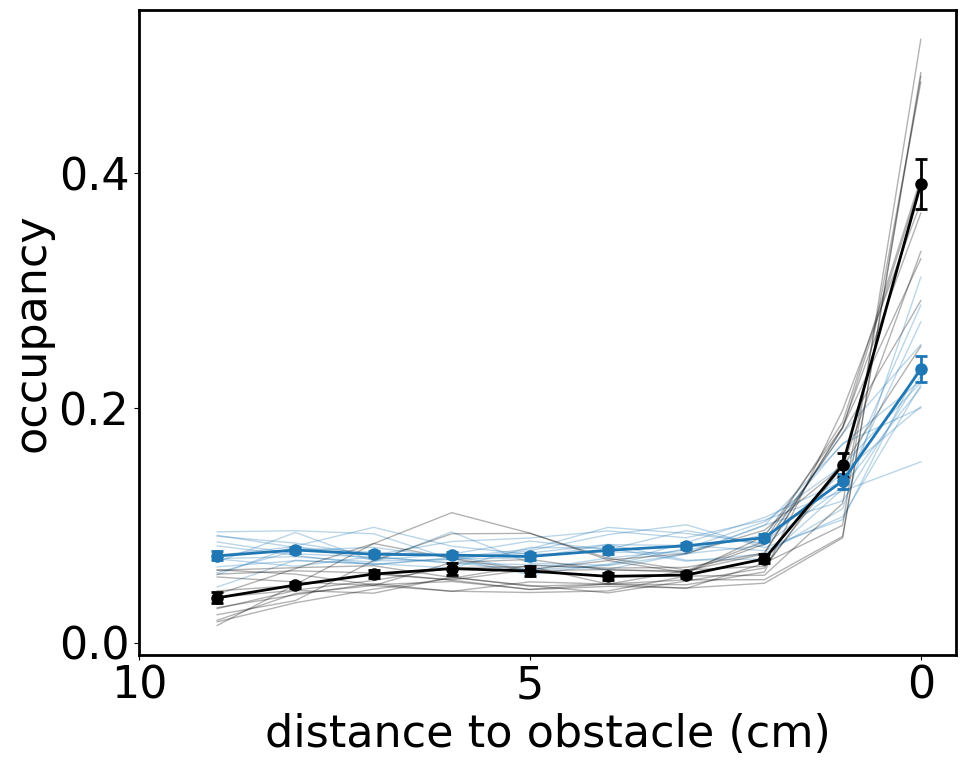


SUMMARY TABLE

Condition  Animals    Time Samples    Mean Dist (cm) 
--------------------------------------------------
Light      13         106663          3.53 ± 0.07
Dark       13         63992           2.53 ± 0.09


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

xnew = np.arange(0, 10, 1)
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance <= 15]  

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'normal', 'size': 18}
plt.rc('font', **font)

# Helper function to flatten arrays
def flatten_list_of_arrays(arr_list):
    """Flatten a list of arrays or a numpy array of arrays"""
    if isinstance(arr_list, np.ndarray) and arr_list.dtype == object:
        return np.concatenate(arr_list)
    elif isinstance(arr_list, list):
        return np.concatenate(arr_list)
    else:
        return arr_list

# Process light condition
light = data[data.task == 'oa']

# Process individual animals for light condition
light_animal_hists = []  # Store histograms for each animal
light_lines = []  # Store lines for plotting

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 10))]
    
    # Skip animals with no data
    if len(ani_light_dists) == 0:
        continue
    
    counts, bins = np.histogram(ani_light_dists, bins=10, range=(0, 10))
    
    # Calculate proportion for this animal
    if sum(counts) > 0:
        prob = counts / sum(counts)
    else:
        prob = np.zeros(10).astype(float)
    
    light_animal_hists.append(prob)
    
    # Store for line plots
    light_lines.append((xnew, prob, ani))

# Convert to array for calculations
light_animal_hists = np.array(light_animal_hists)

# Calculate POPULATION MEAN as mean of animal means
if len(light_animal_hists) > 0:
    light_pop_mean = np.nanmean(light_animal_hists, axis=0)
    
    # Calculate SEM across animals (proper error bars)
    light_sem = np.nanstd(light_animal_hists, axis=0) / np.sqrt(
        np.sum(~np.isnan(light_animal_hists), axis=0))
else:
    light_pop_mean = np.zeros(10)
    light_sem = np.zeros(10)

# Process dark condition
dark = data[data.task == 'oadark']

# Process individual animals for dark condition
dark_animal_hists = []  # Store histograms for each animal
dark_lines = []  # Store lines for plotting

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 10))]
    
    # Skip animals with no data
    if len(ani_dark_dists) == 0:
        continue
    
    counts, bins = np.histogram(ani_dark_dists, bins=10, range=(0, 10))
    
    # Calculate proportion for this animal
    if sum(counts) > 0:
        prob = counts / sum(counts)
    else:
        prob = np.zeros(10).astype(float)
    
    dark_animal_hists.append(prob)
    
    # Store for line plots
    dark_lines.append((xnew, prob, ani))

# Convert to array for calculations
dark_animal_hists = np.array(dark_animal_hists)

# Calculate POPULATION MEAN as mean of animal means
if len(dark_animal_hists) > 0:
    dark_pop_mean = np.nanmean(dark_animal_hists, axis=0)
    
    # Calculate SEM across animals (proper error bars)
    dark_sem = np.nanstd(dark_animal_hists, axis=0) / np.sqrt(
        np.sum(~np.isnan(dark_animal_hists), axis=0))
else:
    dark_pop_mean = np.zeros(10)
    dark_sem = np.zeros(10)

# Print summary statistics
print("=" * 60)
print("DISTANCE TO OBSTACLE - ANIMAL-LEVEL ANALYSIS")
print("=" * 60)

# Calculate mean distance for each animal
light_mean_distances = []
dark_mean_distances = []

print(f"\nLIGHT CONDITION:")
print(f"Number of animals: {len(light_animal_hists)}")
for i, (x, y, animal) in enumerate(light_lines):
    # Calculate weighted mean distance for this animal
    if len(y) > 0 and np.sum(y) > 0:
        mean_dist = np.average(xnew, weights=y)
        light_mean_distances.append(mean_dist)
        print(f"  Animal {animal}: mean distance = {mean_dist:.2f} cm")

print(f"\nDARK CONDITION:")
print(f"Number of animals: {len(dark_animal_hists)}")
for i, (x, y, animal) in enumerate(dark_lines):
    # Calculate weighted mean distance for this animal
    if len(y) > 0 and np.sum(y) > 0:
        mean_dist = np.average(xnew, weights=y)
        dark_mean_distances.append(mean_dist)
        print(f"  Animal {animal}: mean distance = {mean_dist:.2f} cm")

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot POPULATION MEAN lines with SEM error bars (from animal means)
ax.errorbar(xnew, light_pop_mean, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light', zorder=5)

ax.errorbar(xnew, dark_pop_mean, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([ 10, 5, 0])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('occupancy', fontsize=32, fontweight='normal')
ax.set_xlabel('distance to obstacle (cm)', fontsize=32, fontweight='normal')
ax.invert_xaxis()



plt.tight_layout()

# ============================================================================
# STATISTICAL COMPARISON (animal-level means)
# ============================================================================
print("\n" + "=" * 60)
print("STATISTICAL ANALYSIS")
print("=" * 60)

if len(light_mean_distances) > 1 and len(dark_mean_distances) > 1:
    # Independent t-test (different animals in each condition)
    t_stat, p_val = stats.ttest_ind(light_mean_distances, dark_mean_distances, equal_var=False)
    
    print(f"\nMean distance to obstacle comparison:")
    print(f"Light: {np.mean(light_mean_distances):.2f} ± {np.std(light_mean_distances, ddof=1)/np.sqrt(len(light_mean_distances)):.2f} cm (n={len(light_mean_distances)})")
    print(f"Dark:  {np.mean(dark_mean_distances):.2f} ± {np.std(dark_mean_distances, ddof=1)/np.sqrt(len(dark_mean_distances)):.2f} cm (n={len(dark_mean_distances)})")
    print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
    
    if p_val < 0.001:
        print("*** p < 0.001 - HIGHLY SIGNIFICANT")
    elif p_val < 0.01:
        print("** p < 0.01 - VERY SIGNIFICANT")
    elif p_val < 0.05:
        print("* p < 0.05 - SIGNIFICANT")
    else:
        print("Not significant")
        
    # Calculate effect size (Cohen's d)
    pooled_sd = np.sqrt((np.var(light_mean_distances, ddof=1) * (len(light_mean_distances)-1) + 
                        np.var(dark_mean_distances, ddof=1) * (len(dark_mean_distances)-1)) / 
                       (len(light_mean_distances) + len(dark_mean_distances) - 2))
    cohen_d = (np.mean(light_mean_distances) - np.mean(dark_mean_distances)) / pooled_sd
    print(f"Effect size (Cohen's d): {cohen_d:.3f}")
    
    # Interpretation
    if p_val < 0.05:
        if np.mean(light_mean_distances) > np.mean(dark_mean_distances):
            print("Animals maintain greater distance from obstacle in LIGHT condition")
        else:
            print("Animals maintain greater distance from obstacle in DARK condition")
else:
    print("\n⚠️  Not enough animals for statistical comparison")
    print(f"Light animals: {len(light_mean_distances)}, Dark animals: {len(dark_mean_distances)}")

# ============================================================================
# ADDITIONAL ANALYSES
# ============================================================================

# Calculate proportion of time spent close to obstacle (< 5 cm)
print("\n" + "=" * 60)
print("TIME SPENT CLOSE TO OBSTACLE (< 5 cm)")
print("=" * 60)

light_close_props = []
dark_close_props = []

# Light condition
for i, (x, y, animal) in enumerate(light_lines):
    if len(y) > 0:
        # Get indices where distance < 5 cm (x values > 15 since x-axis is inverted)
        close_indices = np.where(x > 15)[0]  # x > 15 corresponds to distance < 5
        if len(close_indices) > 0:
            close_prop = np.sum(y[close_indices])
            light_close_props.append(close_prop)
            print(f"Light - Animal {animal}: {close_prop:.3f}")

# Dark condition
for i, (x, y, animal) in enumerate(dark_lines):
    if len(y) > 0:
        close_indices = np.where(x > 15)[0]
        if len(close_indices) > 0:
            close_prop = np.sum(y[close_indices])
            dark_close_props.append(close_prop)
            print(f"Dark - Animal {animal}: {close_prop:.3f}")

if light_close_props and dark_close_props:
    print(f"\nSummary:")
    print(f"Light: {np.mean(light_close_props):.3f} ± {np.std(light_close_props, ddof=1)/np.sqrt(len(light_close_props)):.3f} (n={len(light_close_props)})")
    print(f"Dark:  {np.mean(dark_close_props):.3f} ± {np.std(dark_close_props, ddof=1)/np.sqrt(len(dark_close_props)):.3f} (n={len(dark_close_props)})")
    
    t_stat_close, p_val_close = stats.ttest_ind(light_close_props, dark_close_props, equal_var=False)
    print(f"Comparison: t = {t_stat_close:.3f}, p = {p_val_close:.4f}")

# Show the plot
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\short_distance_to_lines_1.pdf", 
          # dpi=300, transparent=True)
plt.show()

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)

# Count total data points (time samples) for each condition
def count_total_samples(condition_data):
    total = 0
    for _, row in condition_data.iterrows():
        samples = row.ts_distance_from_edge
        samples = samples[(samples >= 0) & (samples <= 10)]
        total += len(samples)
    return total

light_total_samples = count_total_samples(light)
dark_total_samples = count_total_samples(dark)

print(f"\n{'Condition':<10} {'Animals':<10} {'Time Samples':<15} {'Mean Dist (cm)':<15}")
print("-" * 50)

if light_mean_distances:
    print(f"{'Light':<10} {len(light_mean_distances):<10} {light_total_samples:<15} {np.mean(light_mean_distances):.2f} ± {np.std(light_mean_distances, ddof=1)/np.sqrt(len(light_mean_distances)):.2f}")
else:
    print(f"{'Light':<10} {0:<10} {light_total_samples:<15} N/A")

if dark_mean_distances:
    print(f"{'Dark':<10} {len(dark_mean_distances):<10} {dark_total_samples:<15} {np.mean(dark_mean_distances):.2f} ± {np.std(dark_mean_distances, ddof=1)/np.sqrt(len(dark_mean_distances)):.2f}")
else:
    print(f"{'Dark':<10} {0:<10} {dark_total_samples:<15} N/A")

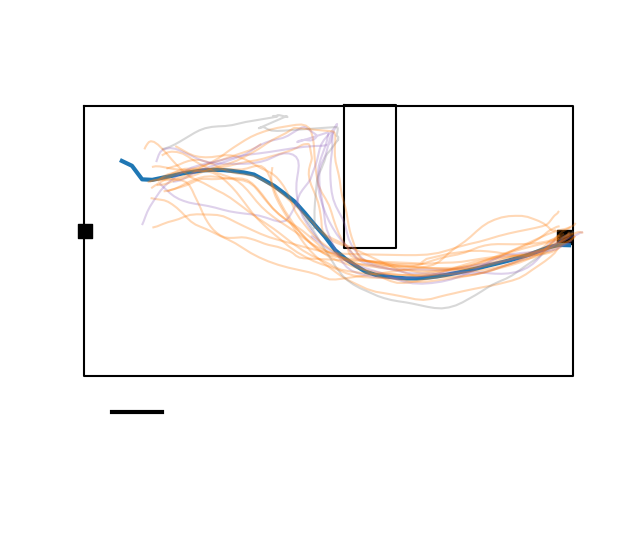

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_mean_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, light_nose_y, linewidth=3)

light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.3, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\light_tortuosity_trials.pdf",dpi = 300, transparent=True)

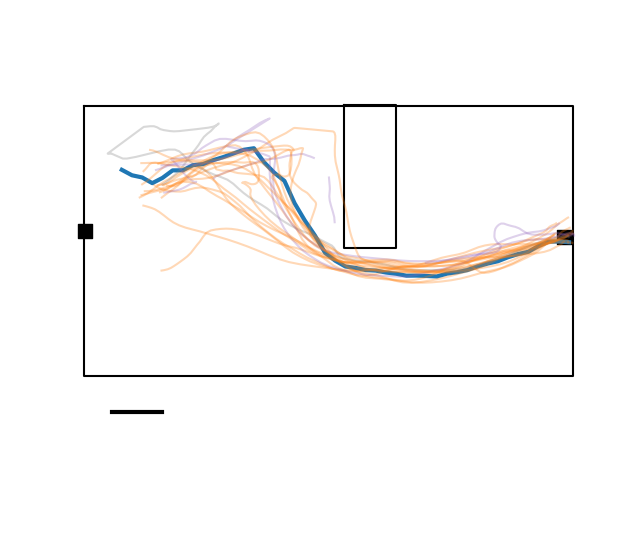

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, light_nose_y, linewidth=3)

light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.3, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

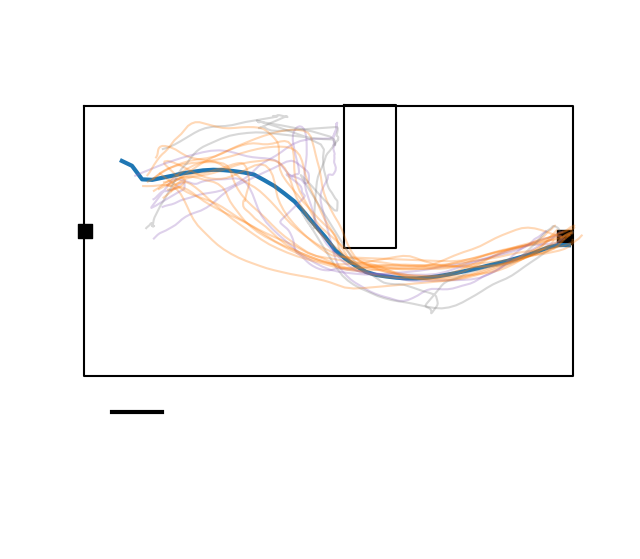

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_mean_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, light_nose_y, linewidth=3)

light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.3, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

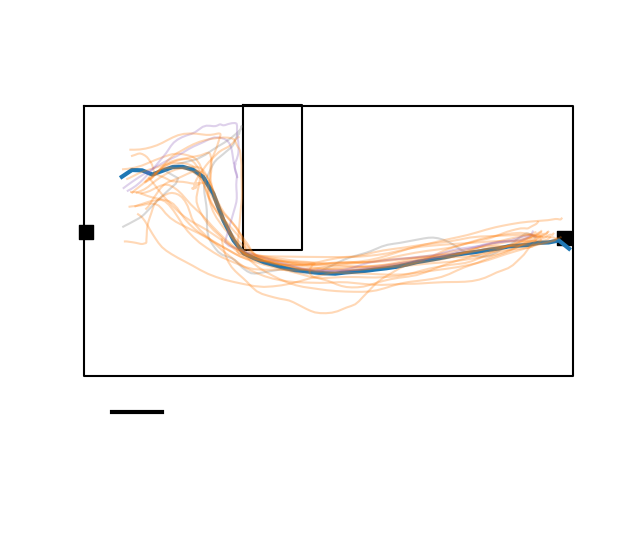

In [78]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 0) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.intial_distance <= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, light_nose_y, linewidth=3)

light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.3, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\short_light_tortuosity_trials.pdf",dpi = 300, transparent=True)


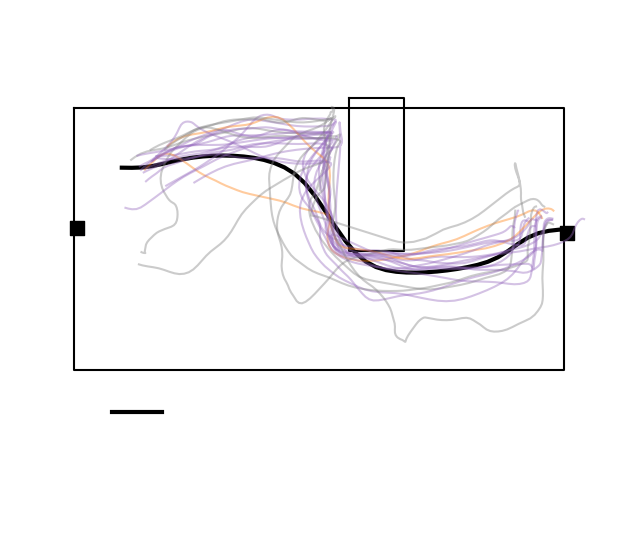

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oadark') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_mean_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'black')

light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.4, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\dark_tortuosity_trials.pdf",dpi = 300, transparent=True)

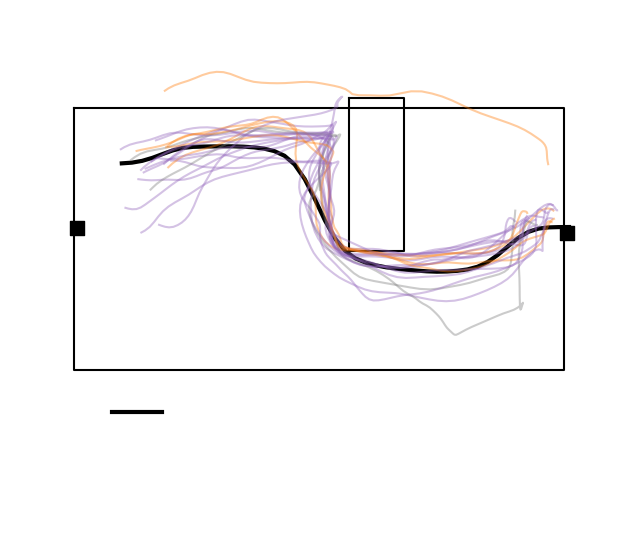

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oadark') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'black')

light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.4, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\dark_tortuosity_trials.pdf",dpi = 300, transparent=True)

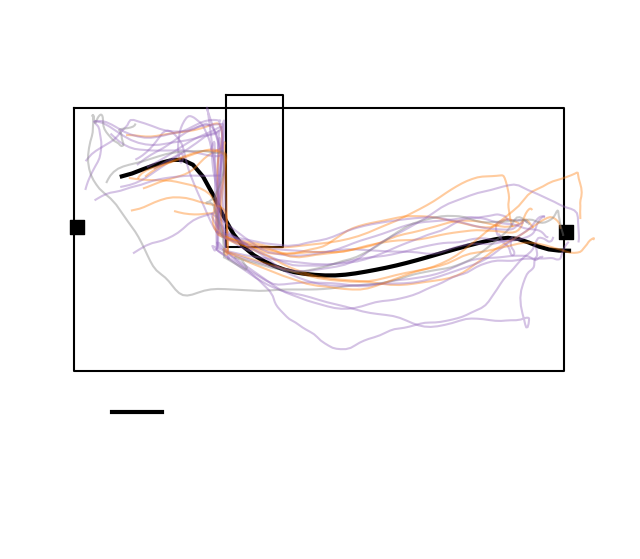

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 0) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oadark') & 
                   (light_dark.intial_distance <= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'black')

light_sample_towards = light
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.4, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\short_dark_tortuosity_trials.pdf",dpi = 300, transparent=True)

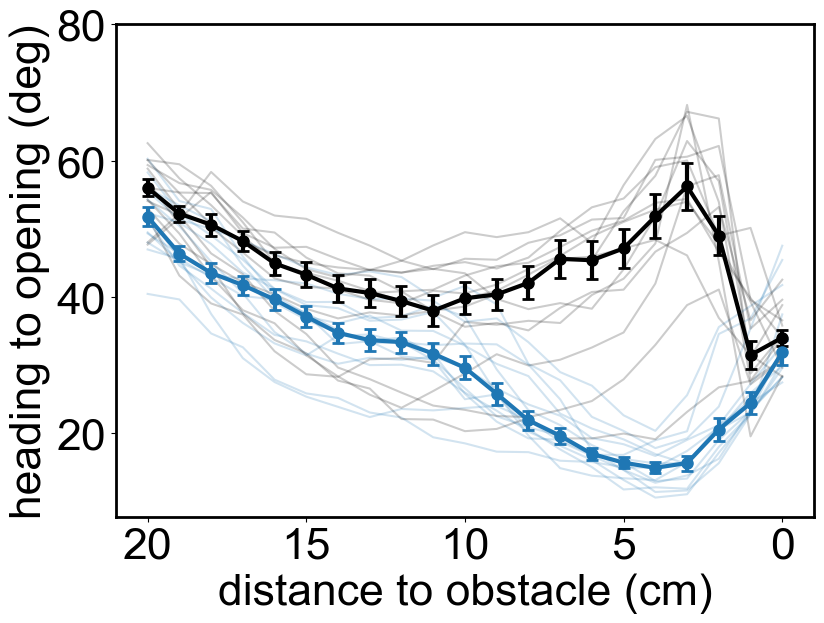

In [30]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32,
        'weight':'normal'}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 

# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1.5)
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1.5)

# Plot median lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([20,40,60,80])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)


# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
#ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_to_opening_lines_1.pdf", 
#            dpi=300, transparent=True)

COMPARISON OF LIGHT VS DARK CONDITIONS AT EACH DISTANCE
Light condition: n = 13 animals
Dark condition: n = 13 animals


Distance 20 cm:
  Light: n=13, Mean=56.27±4.64, Median=55.95
  Dark:  n=13, Mean=60.14±4.62, Median=58.07
  Normality (Shapiro-Wilk): Light p=0.2960, Dark p=0.1438
  Equal variance (Levene): p=0.9225
  Student's t-test: t=-2.048, p=0.051648
  Mann-Whitney U: U=52.0, p=0.100792

Distance 19 cm:
  Light: n=13, Mean=52.85±4.53, Median=51.48
  Dark:  n=13, Mean=58.28±4.80, Median=56.98
  Normality (Shapiro-Wilk): Light p=0.4065, Dark p=0.9203
  Equal variance (Levene): p=0.9994
  Student's t-test: t=-2.850, p=0.008830
  Mann-Whitney U: U=39.0, p=0.021016

Distance 18 cm:
  Light: n=13, Mean=50.38±4.48, Median=48.22
  Dark:  n=13, Mean=54.52±5.18, Median=53.52
  Normality (Shapiro-Wilk): Light p=0.2786, Dark p=0.9900
  Equal variance (Levene): p=0.8820
  Student's t-test: t=-2.093, p=0.047083
  Mann-Whitney U: U=51.0, p=0.090587

Distance 17 cm:
  Light: n=13, Mean=47.54±

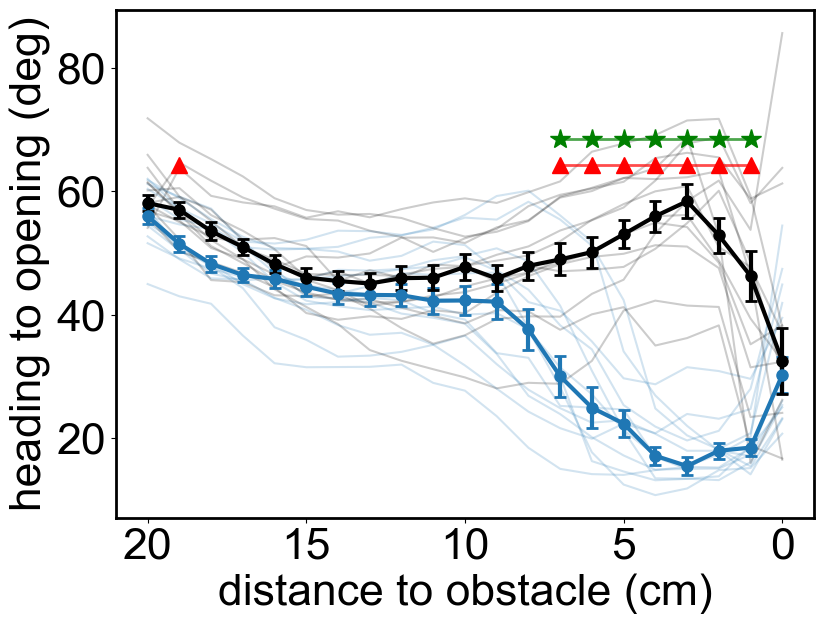


ANALYSIS COMPLETE
Results saved to:
  - statistical_comparison_results.csv (detailed data)
  - statistical_summary.txt (summary report)

Key findings:
  - Significant distances by t-test: [1, 2, 3, 4, 5, 6, 7, 19]
  - Significant distances by Mann-Whitney: [1, 2, 3, 4, 5, 6, 7]
  - Agreement between tests: {1, 2, 3, 4, 5, 6, 7}

Interpretation:
  - Red triangles (^): Significant by t-test (parametric)
  - Green stars (*): Significant by Mann-Whitney U (non-parametric)


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32,
        'weight':'normal'}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 

# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)

# Convert to numpy arrays
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# ============================================================================
# STATISTICAL ANALYSIS: T-TESTS AND MANN-WHITNEY U TESTS
# ============================================================================

print("=" * 70)
print("COMPARISON OF LIGHT VS DARK CONDITIONS AT EACH DISTANCE")
print("=" * 70)
print(f"Light condition: n = {len(light_medians)} animals")
print(f"Dark condition: n = {len(dark_medians)} animals")
print()

# Storage for results
results = []

for i, distance in enumerate(xnew):
    # Extract data for this distance
    light_vals = light_medians[:, i]
    dark_vals = dark_medians[:, i]
    
    # Remove NaN values
    light_clean = light_vals[~np.isnan(light_vals)]
    dark_clean = dark_vals[~np.isnan(dark_vals)]
    
    # Only proceed if we have enough data
    if len(light_clean) > 1 and len(dark_clean) > 1:
        # Calculate descriptive statistics
        light_mean = np.mean(light_clean)
        dark_mean = np.mean(dark_clean)
        light_median = np.median(light_clean)
        dark_median = np.median(dark_clean)
        light_std = np.std(light_clean)
        dark_std = np.std(dark_clean)
        
        # 1. NORMALITY TESTS (for parametric test assumptions)
        _, light_norm_p = stats.shapiro(light_clean)
        _, dark_norm_p = stats.shapiro(dark_clean)
        
        # 2. EQUAL VARIANCE TEST
        _, equal_var_p = stats.levene(light_clean, dark_clean)
        
        # 3. PARAMETRIC: INDEPENDENT T-TEST
        if equal_var_p > 0.05:
            # Use standard t-test (equal variance)
            t_stat, t_p = stats.ttest_ind(light_clean, dark_clean, equal_var=True)
            t_test_type = "Student's t-test"
        else:
            # Use Welch's t-test (unequal variance)
            t_stat, t_p = stats.ttest_ind(light_clean, dark_clean, equal_var=False)
            t_test_type = "Welch's t-test"
        
        # 4. NON-PARAMETRIC: MANN-WHITNEY U TEST
        u_stat, u_p = stats.mannwhitneyu(light_clean, dark_clean, alternative='two-sided')
        
        # Store results
        results.append({
            'distance': distance,
            'light_n': len(light_clean),
            'dark_n': len(dark_clean),
            'light_mean': light_mean,
            'dark_mean': dark_mean,
            'light_median': light_median,
            'dark_median': dark_median,
            'light_std': light_std,
            'dark_std': dark_std,
            'light_norm_p': light_norm_p,
            'dark_norm_p': dark_norm_p,
            'equal_var_p': equal_var_p,
            't_statistic': t_stat,
            't_p_value': t_p,
            't_test_type': t_test_type,
            'u_statistic': u_stat,
            'u_p_value': u_p,
            'normality_assumption': light_norm_p > 0.05 and dark_norm_p > 0.05
        })
        
        # Print results for this distance
        print(f"\nDistance {distance} cm:")
        print(f"  Light: n={len(light_clean)}, Mean={light_mean:.2f}±{light_std:.2f}, Median={light_median:.2f}")
        print(f"  Dark:  n={len(dark_clean)}, Mean={dark_mean:.2f}±{dark_std:.2f}, Median={dark_median:.2f}")
        print(f"  Normality (Shapiro-Wilk): Light p={light_norm_p:.4f}, Dark p={dark_norm_p:.4f}")
        print(f"  Equal variance (Levene): p={equal_var_p:.4f}")
        print(f"  {t_test_type}: t={t_stat:.3f}, p={t_p:.6f}")
        print(f"  Mann-Whitney U: U={u_stat:.1f}, p={u_p:.6f}")
    else:
        print(f"\nDistance {distance} cm: Insufficient data")
        results.append({
            'distance': distance,
            'light_n': len(light_clean),
            'dark_n': len(dark_clean),
            't_p_value': 1.0,
            'u_p_value': 1.0
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# ============================================================================
# APPLY MULTIPLE COMPARISON CORRECTION
# ============================================================================

print("\n" + "=" * 70)
print("MULTIPLE COMPARISON CORRECTION (FDR - Benjamini/Hochberg)")
print("=" * 70)

# Get p-values for correction
t_p_values = results_df['t_p_value'].values
u_p_values = results_df['u_p_value'].values

# Apply FDR correction
t_reject, t_pvals_corrected, _, _ = multipletests(t_p_values, alpha=0.05, method='fdr_bh')
u_reject, u_pvals_corrected, _, _ = multipletests(u_p_values, alpha=0.05, method='fdr_bh')

# Add corrected values to results
results_df['t_p_corrected'] = t_pvals_corrected
results_df['t_significant'] = t_reject
results_df['u_p_corrected'] = u_pvals_corrected
results_df['u_significant'] = u_reject

# Identify significant distances
t_sig_distances = results_df[results_df['t_significant']]['distance'].tolist()
u_sig_distances = results_df[results_df['u_significant']]['distance'].tolist()

print(f"\nSignificant distances (t-test, FDR-corrected): {sorted(t_sig_distances)}")
print(f"Significant distances (Mann-Whitney, FDR-corrected): {sorted(u_sig_distances)}")

# Print detailed significant results
print("\nDETAILED SIGNIFICANT RESULTS:")
print("-" * 50)

for idx, row in results_df.iterrows():
    if row['t_significant'] or row['u_significant']:
        print(f"\nDistance {row['distance']} cm:")
        if row['t_significant']:
            print(f"  t-test: p = {row['t_p_corrected']:.6f} (*)")
        else:
            print(f"  t-test: p = {row['t_p_corrected']:.6f}")
        
        if row['u_significant']:
            print(f"  Mann-Whitney: p = {row['u_p_corrected']:.6f} (*)")
        else:
            print(f"  Mann-Whitney: p = {row['u_p_corrected']:.6f}")

# ============================================================================
# PLOT WITH SIGNIFICANCE MARKERS FOR BOTH TESTS
# ============================================================================

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1.5)
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1.5)

# Plot median lines with SEM error bars
light_line = ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

dark_line = ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Add significance markers for both tests
if t_sig_distances or u_sig_distances:
    # Find appropriate y-positions for markers
    y_max = np.nanmax([np.nanmax(light_angle_median + light_sem), 
                      np.nanmax(dark_angle_median + dark_sem)])
    
    # Different y-positions for different test types
    y_t_test = y_max * 1.05  # For t-test markers
    y_mwu_test = y_max * 1.12  # For Mann-Whitney markers
    
    # Plot t-test significance markers (triangles)
    for distance in t_sig_distances:
        idx = np.where(xnew == distance)[0][0]
        # Plot triangle marker
        ax.plot(distance, y_t_test, '^', 
                markersize=12, color='red', markeredgecolor='red',
                label='t-test sig' if distance == t_sig_distances[0] else "")
    
    # Plot Mann-Whitney significance markers (stars)
    for distance in u_sig_distances:
        idx = np.where(xnew == distance)[0][0]
        # Plot star marker
        ax.plot(distance, y_mwu_test, '*', 
                markersize=15, color='green', markeredgecolor='green',
                label='Mann-Whitney sig' if distance == u_sig_distances[0] else "")
    
    # Add horizontal lines to show ranges of significance
    def plot_significance_bracket(sig_distances, y_level, color, linewidth=2):
        """Plot horizontal bracket for consecutive significant distances"""
        if not sig_distances:
            return
        
        # Sort distances
        sorted_dists = sorted(sig_distances)
        
        # Group consecutive distances
        groups = []
        current_group = [sorted_dists[0]]
        
        for i in range(1, len(sorted_dists)):
            if sorted_dists[i] == sorted_dists[i-1] + 1:
                current_group.append(sorted_dists[i])
            else:
                groups.append(current_group)
                current_group = [sorted_dists[i]]
        groups.append(current_group)
        
        # Plot brackets for groups with >1 consecutive distance
        for group in groups:
            if len(group) > 1:
                start_x = min(group)
                end_x = max(group)
                # Horizontal line
                ax.plot([start_x, end_x], [y_level, y_level], 
                        color=color, linewidth=linewidth, alpha=0.7)
                # End caps
                ax.plot([start_x, start_x], [y_level*0.995, y_level*1.005], 
                        color=color, linewidth=linewidth, alpha=0.7)
                ax.plot([end_x, end_x], [y_level*0.995, y_level*1.005], 
                        color=color, linewidth=linewidth, alpha=0.7)
    
    # Plot brackets
    plot_significance_bracket(t_sig_distances, y_t_test, 'red')
    plot_significance_bracket(u_sig_distances, y_mwu_test, 'green')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([20,40,60,80])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)

# Create custom legend handles
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Add significance markers to legend if any exist
if t_sig_distances:
    legend_handles.append(
        Line2D([0], [0], marker='^', color='w', label='t-test p<0.05',
              markerfacecolor='red', markersize=12)
    )

if u_sig_distances:
    legend_handles.append(
        Line2D([0], [0], marker='*', color='w', label='Mann-Whitney p<0.05',
              markerfacecolor='green', markersize=15)
    )

# Add information about sample sizes to legend
legend_handles.append(
    Patch(facecolor='white', edgecolor='white', 
          label=f'n(light)={len(light_medians)}, n(dark)={len(dark_medians)}')
)

# Add legend (uncomment if you want it)
# ax.legend(handles=legend_handles, loc='best', fontsize=20, framealpha=0.8)

plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"

# ============================================================================
# SAVE COMPREHENSIVE RESULTS
# ============================================================================

# Save results to CSV
results_df.to_csv('statistical_comparison_results.csv', index=False)

# Save summary to text file
with open('statistical_summary.txt', 'w') as f:
    f.write("COMPARISON OF LIGHT VS DARK CONDITIONS AT EACH DISTANCE\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Light condition: n = {len(light_medians)} animals\n")
    f.write(f"Dark condition: n = {len(dark_medians)} animals\n\n")
    
    f.write("SIGNIFICANT DISTANCES AFTER FDR CORRECTION:\n")
    f.write("-" * 50 + "\n")
    f.write(f"t-test: {sorted(t_sig_distances)}\n")
    f.write(f"Mann-Whitney U: {sorted(u_sig_distances)}\n\n")
    
    f.write("DETAILED RESULTS:\n")
    f.write("-" * 50 + "\n")
    
    for idx, row in results_df.iterrows():
        if not np.isnan(row.get('light_mean', np.nan)):
            f.write(f"\nDistance {row['distance']} cm:\n")
            f.write(f"  Light: n={row['light_n']}, Mean={row['light_mean']:.2f}, Median={row['light_median']:.2f}\n")
            f.write(f"  Dark:  n={row['dark_n']}, Mean={row['dark_mean']:.2f}, Median={row['dark_median']:.2f}\n")
            f.write(f"  t-test ({row.get('t_test_type', 'N/A')}): p={row.get('t_p_value', 1.0):.6f}, p_corr={row.get('t_p_corrected', 1.0):.6f}")
            if row.get('t_significant', False):
                f.write(" (*)")
            f.write("\n")
            f.write(f"  Mann-Whitney U: p={row.get('u_p_value', 1.0):.6f}, p_corr={row.get('u_p_corrected', 1.0):.6f}")
            if row.get('u_significant', False):
                f.write(" (*)")
            f.write("\n")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print("Results saved to:")
print("  - statistical_comparison_results.csv (detailed data)")
print("  - statistical_summary.txt (summary report)")
print("\nKey findings:")
print(f"  - Significant distances by t-test: {sorted(t_sig_distances)}")
print(f"  - Significant distances by Mann-Whitney: {sorted(u_sig_distances)}")
print(f"  - Agreement between tests: {set(t_sig_distances) & set(u_sig_distances)}")
print("\nInterpretation:")
print("  - Red triangles (^): Significant by t-test (parametric)")
print("  - Green stars (*): Significant by Mann-Whitney U (non-parametric)")

TWO-WAY REPEATED MEASURES ANOVA
Factors:
  - Condition: light vs dark (between-subjects)
  - Distance: multiple distances (within-subjects)
  - Interaction: Condition × Distance

Dataset Summary:
  Total observations: 546
  Unique animals: 26
    - Light condition: 13
    - Dark condition: 13
  Distance levels: 21

--------------------------------------------------------------------------------
METHOD 1: LINEAR MIXED EFFECTS MODEL APPROACH
(Accounts for repeated measures on Distance)
--------------------------------------------------------------------------------

Two-Way Repeated Measures ANOVA Table (Type II):
------------------------------------------------------------
                                sum_sq     df          F        PR(>F)
C(Condition)                233.410908    1.0   6.276680  1.256385e-02
C(Distance)               23181.836295   20.0  31.169273  9.263235e-74
C(Animal)                 19047.197396   25.0  20.488016  2.486810e-60
C(Condition):C(Distance)  22805.277

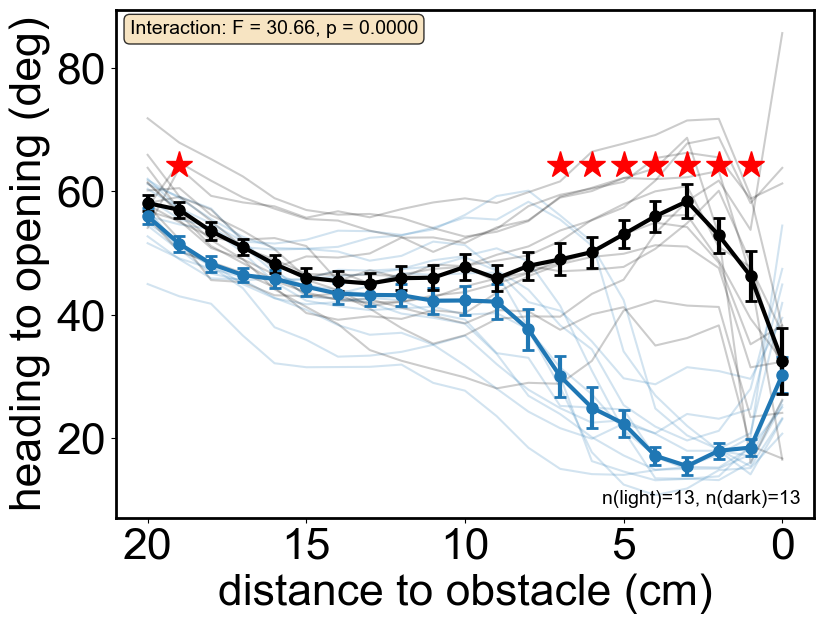


ANALYSIS COMPLETE

Results saved to 'rm_anova_results.txt'

For your paper, report:
1. Two-way repeated measures ANOVA results
2. Condition × Distance interaction: F = 30.66, p = 0.0000
3. If p < 0.05, report post-hoc tests at specific distances
4. Include degrees of freedom and exact p-values


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32,
        'weight':'normal'}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 

# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

# Track animal IDs for repeated measures
animal_id_map = {}
animal_counter = 0

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
            animal_id_map[animal_counter] = ('light', animal_counter)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)
            animal_id_map[animal_counter] = ('dark', animal_counter)
        
        animal_counter += 1

# Convert to numpy arrays
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# ============================================================================
# TWO-WAY REPEATED MEASURES ANOVA
# ============================================================================

print("=" * 80)
print("TWO-WAY REPEATED MEASURES ANOVA")
print("=" * 80)
print("Factors:")
print("  - Condition: light vs dark (between-subjects)")
print("  - Distance: multiple distances (within-subjects)")
print("  - Interaction: Condition × Distance")
print()

# Create long-format dataframe for repeated measures ANOVA
rm_anova_data = []

# Add light condition data
for animal_idx, animal_data in enumerate(light_medians):
    animal_id = f"L{animal_idx}"
    condition = "light"
    
    for dist_idx, distance in enumerate(xnew):
        value = animal_data[dist_idx]
        if not np.isnan(value):
            rm_anova_data.append({
                'Animal': animal_id,
                'Condition': condition,
                'Distance': distance,
                'Value': value,
                'ConditionGroup': 'light'  # For between-subjects grouping
            })

# Add dark condition data
for animal_idx, animal_data in enumerate(dark_medians):
    animal_id = f"D{animal_idx}"
    condition = "dark"
    
    for dist_idx, distance in enumerate(xnew):
        value = animal_data[dist_idx]
        if not np.isnan(value):
            rm_anova_data.append({
                'Animal': animal_id,
                'Condition': condition,
                'Distance': distance,
                'Value': value,
                'ConditionGroup': 'dark'  # For between-subjects grouping
            })

rm_df = pd.DataFrame(rm_anova_data)

print(f"Dataset Summary:")
print(f"  Total observations: {len(rm_df)}")
print(f"  Unique animals: {rm_df['Animal'].nunique()}")
print(f"    - Light condition: {len(rm_df[rm_df['Condition'] == 'light']['Animal'].unique())}")
print(f"    - Dark condition: {len(rm_df[rm_df['Condition'] == 'dark']['Animal'].unique())}")
print(f"  Distance levels: {len(xnew)}")
print()

# ============================================================================
# METHOD 1: Linear Mixed Effects Model (Recommended for RM-ANOVA)
# ============================================================================

print("-" * 80)
print("METHOD 1: LINEAR MIXED EFFECTS MODEL APPROACH")
print("(Accounts for repeated measures on Distance)")
print("-" * 80)

# Using ordinary least squares with Animal as a factor to account for repeated measures
# This approximates a mixed model with Animal as random effect

# Model: Value ~ Condition * Distance + Animal
model_formula = 'Value ~ C(Condition) * C(Distance) + C(Animal)'
model = ols(model_formula, data=rm_df).fit()

# Type II ANOVA (recommended for factorial designs with no interaction)
anova_table = anova_lm(model, typ=2)

print("\nTwo-Way Repeated Measures ANOVA Table (Type II):")
print("-" * 60)
print(anova_table)

# Extract key p-values
condition_effect = anova_table.loc['C(Condition)', 'PR(>F)']
distance_effect = anova_table.loc['C(Distance)', 'PR(>F)']
interaction_effect = anova_table.loc['C(Condition):C(Distance)', 'PR(>F)']

print("\nKey Results:")
print(f"  Main effect of Condition (light vs dark):")
print(f"    F({int(anova_table.loc['C(Condition)', 'df']):d}, {int(anova_table.loc['Residual', 'df']):d}) = {anova_table.loc['C(Condition)', 'F']:.3f}, p = {condition_effect:.6f}")

print(f"\n  Main effect of Distance:")
print(f"    F({int(anova_table.loc['C(Distance)', 'df']):d}, {int(anova_table.loc['Residual', 'df']):d}) = {anova_table.loc['C(Distance)', 'F']:.3f}, p = {distance_effect:.6f}")

print(f"\n  Condition × Distance Interaction:")
print(f"    F({int(anova_table.loc['C(Condition):C(Distance)', 'df']):d}, {int(anova_table.loc['Residual', 'df']):d}) = {anova_table.loc['C(Condition):C(Distance)', 'F']:.3f}, p = {interaction_effect:.6f}")




# ============================================================================
# POST-HOC ANALYSIS (Only if interaction is significant)
# ============================================================================

print("\n" + "=" * 80)
print("POST-HOC ANALYSIS DECISION")
print("=" * 80)

if interaction_effect < 0.05:
    print(f"✓ SIGNIFICANT INTERACTION DETECTED (p = {interaction_effect:.6f})")
    print("✓ Justified to perform post-hoc tests at individual distances")
    
    # Perform post-hoc comparisons
    print("\n" + "-" * 80)
    print("POST-HOC COMPARISONS AT EACH DISTANCE")
    print("-" * 80)
    
    posthoc_results = []
    
    for dist_idx, distance in enumerate(xnew):
        light_vals = light_medians[:, dist_idx]
        dark_vals = dark_medians[:, dist_idx]
        
        light_clean = light_vals[~np.isnan(light_vals)]
        dark_clean = dark_vals[~np.isnan(dark_vals)]
        
        if len(light_clean) > 1 and len(dark_clean) > 1:
            # T-test
            t_stat, t_p = stats.ttest_ind(light_clean, dark_clean, equal_var=False)  # Welch's
            
            # Mann-Whitney U
            u_stat, u_p = stats.mannwhitneyu(light_clean, dark_clean)
            
            posthoc_results.append({
                'Distance': distance,
                'Light_n': len(light_clean),
                'Dark_n': len(dark_clean),
                'Light_mean': np.mean(light_clean),
                'Dark_mean': np.mean(dark_clean),
                'Light_median': np.median(light_clean),
                'Dark_median': np.median(dark_clean),
                'T_statistic': t_stat,
                'T_p_value': t_p,
                'U_statistic': u_stat,
                'U_p_value': u_p
            })
    
    posthoc_df = pd.DataFrame(posthoc_results)
    
    # Apply FDR correction
    t_pvals = posthoc_df['T_p_value'].values
    u_pvals = posthoc_df['U_p_value'].values
    
    t_reject, t_pvals_corrected, _, _ = multipletests(t_pvals, alpha=0.05, method='fdr_bh')
    u_reject, u_pvals_corrected, _, _ = multipletests(u_pvals, alpha=0.05, method='fdr_bh')
    
    posthoc_df['T_p_corrected'] = t_pvals_corrected
    posthoc_df['T_significant'] = t_reject
    posthoc_df['U_p_corrected'] = u_pvals_corrected
    posthoc_df['U_significant'] = u_reject
    
    # Print significant results
    t_sig_dist = posthoc_df[posthoc_df['T_significant']]['Distance'].tolist()
    u_sig_dist = posthoc_df[posthoc_df['U_significant']]['Distance'].tolist()
    
    print(f"\nSignificant distances after FDR correction:")
    print(f"  T-test: {sorted(t_sig_dist)}")
    print(f"  Mann-Whitney U: {sorted(u_sig_dist)}")
    
    # Store for plotting
    significant_distances = sorted(set(t_sig_dist) | set(u_sig_dist))
    
else:
    print(f"✗ NO SIGNIFICANT INTERACTION (p = {interaction_effect:.6f})")
    print("✗ Post-hoc tests at individual distances not justified")
    print("\nReport main effects instead:")
    
    if condition_effect < 0.05:
        print(f"✓ Significant main effect of Condition: p = {condition_effect:.6f}")
    else:
        print(f"✗ No significant main effect of Condition: p = {condition_effect:.6f}")
    
    if distance_effect < 0.05:
        print(f"✓ Significant main effect of Distance: p = {distance_effect:.6f}")
    else:
        print(f"✗ No significant main effect of Distance: p = {distance_effect:.6f}")
    
    significant_distances = []

# ============================================================================
# PLOTTING
# ============================================================================

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1.5)
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1.5)

# Plot median lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Add significance markers if interaction was significant
if interaction_effect < 0.05 and significant_distances:
    # Find y-position for markers
    y_max = np.nanmax([np.nanmax(light_angle_median + light_sem), 
                      np.nanmax(dark_angle_median + dark_sem)])
    y_marker = y_max * 1.05
    
    # Add stars at significant distances
    for distance in significant_distances:
        ax.plot(distance, y_marker, '*', 
                markersize=20, color='red', markeredgecolor='red',
                zorder=10)
    
    # Add annotation about interaction
    ax.text(0.02, 0.98, f'Interaction: F = {anova_table.loc["C(Condition):C(Distance)", "F"]:.2f}, p = {interaction_effect:.4f}',
            transform=ax.transAxes, fontsize=14,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Formatting
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([20,40,60,80])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)

# Add sample size annotation
ax.text(0.98, 0.02, f'n(light)={len(light_medians)}, n(dark)={len(dark_medians)}',
        transform=ax.transAxes, fontsize=14,
        horizontalalignment='right', verticalalignment='bottom')

plt.tight_layout()
plt.show()

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save ANOVA results
with open('rm_anova_results.txt', 'w') as f:
    f.write("TWO-WAY REPEATED MEASURES ANOVA RESULTS\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("EXPERIMENTAL DESIGN:\n")
    f.write(f"  Between-subjects factor: Condition (light vs dark)\n")
    f.write(f"  Within-subjects factor: Distance ({len(xnew)} levels)\n")
    f.write(f"  Light condition animals: {len(light_medians)}\n")
    f.write(f"  Dark condition animals: {len(dark_medians)}\n\n")
    
    f.write("ANOVA TABLE (Type II):\n")
    f.write("-" * 60 + "\n")
    f.write(anova_table.to_string())
    f.write("\n\n")
    
    f.write("KEY FINDINGS:\n")
    f.write("-" * 60 + "\n")
    f.write(f"Main effect of Condition: F = {anova_table.loc['C(Condition)', 'F']:.3f}, p = {condition_effect:.6f}\n")
    f.write(f"Main effect of Distance: F = {anova_table.loc['C(Distance)', 'F']:.3f}, p = {distance_effect:.6f}\n")
    f.write(f"Condition × Distance Interaction: F = {anova_table.loc['C(Condition):C(Distance)', 'F']:.3f}, p = {interaction_effect:.6f}\n\n")
    
    if interaction_effect < 0.05 and 'posthoc_df' in locals():
        f.write("POST-HOC RESULTS (FDR-corrected):\n")
        f.write("-" * 60 + "\n")
        f.write(f"Significant distances from t-tests: {sorted(t_sig_dist)}\n")
        f.write(f"Significant distances from Mann-Whitney: {sorted(u_sig_dist)}\n\n")
        
        f.write("DETAILED POST-HOC RESULTS:\n")
        f.write("-" * 60 + "\n")
        for idx, row in posthoc_df.iterrows():
            f.write(f"\nDistance {row['Distance']} cm:\n")
            f.write(f"  Light: n={row['Light_n']}, mean={row['Light_mean']:.2f}, median={row['Light_median']:.2f}\n")
            f.write(f"  Dark:  n={row['Dark_n']}, mean={row['Dark_mean']:.2f}, median={row['Dark_median']:.2f}\n")
            f.write(f"  Welch's t-test: t={row['T_statistic']:.3f}, p={row['T_p_value']:.6f}, p_corr={row['T_p_corrected']:.6f}")
            if row['T_significant']:
                f.write(" *")
            f.write(f"\n  Mann-Whitney U: U={row['U_statistic']:.1f}, p={row['U_p_value']:.6f}, p_corr={row['U_p_corrected']:.6f}")
            if row['U_significant']:
                f.write(" *")
            f.write("\n")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print("\nResults saved to 'rm_anova_results.txt'")
print("\nFor your paper, report:")
print(f"1. Two-way repeated measures ANOVA results")
print(f"2. Condition × Distance interaction: F = {anova_table.loc['C(Condition):C(Distance)', 'F']:.2f}, p = {interaction_effect:.4f}")
print(f"3. If p < 0.05, report post-hoc tests at specific distances")
print(f"4. Include degrees of freedom and exact p-values")

NameError: name 'light_dark' is not defined

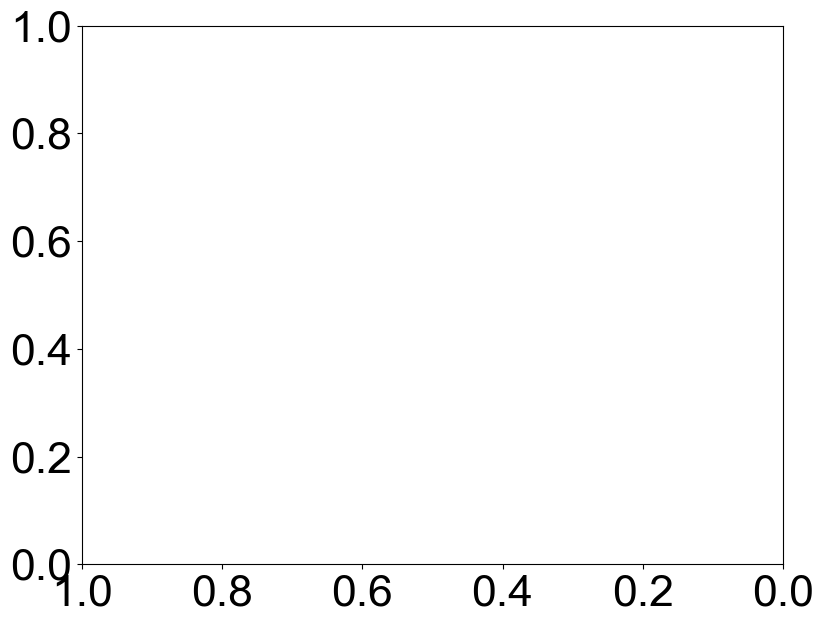

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pingouin as pg

# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32,
        'weight':'normal'}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 

# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

# Track animal IDs for repeated measures
animal_id_map = {}
animal_counter = 0

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
            animal_id_map[animal_counter] = ('light', animal_counter)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)
            animal_id_map[animal_counter] = ('dark', animal_counter)
        
        animal_counter += 1

# Convert to numpy arrays
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# ============================================================================
# TWO-WAY REPEATED MEASURES ANOVA USING PINGOUIN
# ============================================================================

print("=" * 80)
print("TWO-WAY REPEATED MEASURES ANOVA (Pingouin)")
print("=" * 80)
print("Experimental Design:")
print("  - Between-subjects factor: Condition (light vs dark)")
print("  - Within-subjects factor: Distance (multiple measurements per animal)")
print("  - Mixed design: Condition (between) × Distance (within)")
print()

# Create long-format dataframe for repeated measures ANOVA
rm_anova_data = []

# Add light condition data
for animal_idx, animal_data in enumerate(light_medians):
    animal_id = f"L{animal_idx}"
    condition = "light"
    
    for dist_idx, distance in enumerate(xnew):
        value = animal_data[dist_idx]
        if not np.isnan(value):
            rm_anova_data.append({
                'Animal': animal_id,
                'Condition': condition,
                'Distance': distance,
                'Value': value
            })

# Add dark condition data
for animal_idx, animal_data in enumerate(dark_medians):
    animal_id = f"D{animal_idx}"
    condition = "dark"
    
    for dist_idx, distance in enumerate(xnew):
        value = animal_data[dist_idx]
        if not np.isnan(value):
            rm_anova_data.append({
                'Animal': animal_id,
                'Condition': condition,
                'Distance': distance,
                'Value': value
            })

rm_df = pd.DataFrame(rm_anova_data)

# Convert Distance to categorical for ANOVA (optional but can help)
rm_df['Distance'] = rm_df['Distance'].astype('category')

print(f"Dataset Summary:")
print(f"  Total observations: {len(rm_df)}")
print(f"  Unique animals: {rm_df['Animal'].nunique()}")
print(f"    - Light condition: {len(rm_df[rm_df['Condition'] == 'light']['Animal'].unique())}")
print(f"    - Dark condition: {len(rm_df[rm_df['Condition'] == 'dark']['Animal'].unique())}")
print(f"  Distance levels: {len(xnew)}")
print(f"  Sample sizes per condition-distance combination:")
print(rm_df.groupby(['Condition', 'Distance']).size().unstack())
print()

# ============================================================================
# METHOD 1: Mixed ANOVA using Pingouin (Recommended)
# ============================================================================

print("-" * 80)
print("METHOD 1: MIXED ANOVA (Between-Within Design)")
print("-" * 80)

# Perform mixed ANOVA
mixed_anova = pg.mixed_anova(
    data=rm_df,
    dv='Value',           # Dependent variable
    between='Condition',  # Between-subjects factor
    within='Distance',    # Within-subjects factor (repeated measures)
    subject='Animal',     # Subject identifier
    correction='auto',    # Auto sphericity correction
    effsize='np2'         # Partial eta-squared effect size
)

print("\nMixed ANOVA Results:")
print("-" * 60)
print(mixed_anova.to_string())

# Extract key p-values
condition_effect = mixed_anova.loc[mixed_anova['Source'] == 'Condition', 'p-unc'].values[0]
distance_effect = mixed_anova.loc[mixed_anova['Source'] == 'Distance', 'p-unc'].values[0]
interaction_effect = mixed_anova.loc[mixed_anova['Source'] == 'Interaction', 'p-unc'].values[0]

# Extract F-values and degrees of freedom
condition_F = mixed_anova.loc[mixed_anova['Source'] == 'Condition', 'F'].values[0]
condition_df1 = mixed_anova.loc[mixed_anova['Source'] == 'Condition', 'DF1'].values[0]
condition_df2 = mixed_anova.loc[mixed_anova['Source'] == 'Condition', 'DF2'].values[0]

distance_F = mixed_anova.loc[mixed_anova['Source'] == 'Distance', 'F'].values[0]
distance_df1 = mixed_anova.loc[mixed_anova['Source'] == 'Distance', 'DF1'].values[0]
distance_df2 = mixed_anova.loc[mixed_anova['Source'] == 'Distance', 'DF2'].values[0]

interaction_F = mixed_anova.loc[mixed_anova['Source'] == 'Interaction', 'F'].values[0]
interaction_df1 = mixed_anova.loc[mixed_anova['Source'] == 'Interaction', 'DF1'].values[0]
interaction_df2 = mixed_anova.loc[mixed_anova['Source'] == 'Interaction', 'DF2'].values[0]

print("\nKey Results:")
print(f"  Main effect of Condition (light vs dark):")
print(f"    F({int(condition_df1):d}, {int(condition_df2):d}) = {condition_F:.3f}, p = {condition_effect:.6f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Condition', 'np2'].values[0]:.3f}")

print(f"\n  Main effect of Distance:")
print(f"    F({int(distance_df1):d}, {int(distance_df2):d}) = {distance_F:.3f}, p = {distance_effect:.6f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Distance', 'np2'].values[0]:.3f}")

print(f"\n  Condition × Distance Interaction:")
print(f"    F({int(interaction_df1):d}, {int(interaction_df2):d}) = {interaction_F:.3f}, p = {interaction_effect:.6f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Interaction', 'np2'].values[0]:.3f}")

# ============================================================================
# CHECK SPHERICITY (Mauchly's test)
# ============================================================================

print("\n" + "-" * 80)
print("SPHERICITY CHECK")
print("-" * 80)

# For repeated measures (Distance factor), check sphericity
sphericity = pg.sphericity(data=rm_df, dv='Value', within='Distance', subject='Animal')

print(f"Sphericity test: W = {sphericity[1]:.3f}, p = {sphericity[2]:.6f}")
if sphericity[2] < 0.05:
    print("✗ Sphericity violated - Greenhouse-Geisser correction applied")
    epsilon_gg = pg.epsilon(data=rm_df, dv='Value', within='Distance', subject='Animal', method='gg')
    print(f"  Greenhouse-Geisser epsilon: ε = {epsilon_gg:.3f}")
else:
    print("✓ Sphericity assumption satisfied")

# ============================================================================
# POST-HOC ANALYSIS (Only if interaction is significant)
# ============================================================================

print("\n" + "=" * 80)
print("POST-HOC ANALYSIS DECISION")
print("=" * 80)

if interaction_effect < 0.05:
    print(f"✓ SIGNIFICANT INTERACTION DETECTED (p = {interaction_effect:.6f})")
    print("✓ Justified to perform post-hoc tests at individual distances")
    
    # Perform post-hoc comparisons
    print("\n" + "-" * 80)
    print("POST-HOC COMPARISONS AT EACH DISTANCE")
    print("-" * 80)
    
    posthoc_results = []
    
    for dist_idx, distance in enumerate(xnew):
        light_vals = light_medians[:, dist_idx]
        dark_vals = dark_medians[:, dist_idx]
        
        light_clean = light_vals[~np.isnan(light_vals)]
        dark_clean = dark_vals[~np.isnan(dark_vals)]
        
        if len(light_clean) > 1 and len(dark_clean) > 1:
            # T-test
            t_stat, t_p = stats.ttest_ind(light_clean, dark_clean, equal_var=False)  # Welch's
            
            # Mann-Whitney U
            u_stat, u_p = stats.mannwhitneyu(light_clean, dark_clean)
            
            posthoc_results.append({
                'Distance': distance,
                'Light_n': len(light_clean),
                'Dark_n': len(dark_clean),
                'Light_mean': np.mean(light_clean),
                'Dark_mean': np.mean(dark_clean),
                'Light_median': np.median(light_clean),
                'Dark_median': np.median(dark_clean),
                'T_statistic': t_stat,
                'T_p_value': t_p,
                'U_statistic': u_stat,
                'U_p_value': u_p
            })
    
    posthoc_df = pd.DataFrame(posthoc_results)
    
    # Apply FDR correction
    t_pvals = posthoc_df['T_p_value'].values
    u_pvals = posthoc_df['U_p_value'].values
    
    t_reject, t_pvals_corrected, _, _ = multipletests(t_pvals, alpha=0.05, method='fdr_bh')
    u_reject, u_pvals_corrected, _, _ = multipletests(u_pvals, alpha=0.05, method='fdr_bh')
    
    posthoc_df['T_p_corrected'] = t_pvals_corrected
    posthoc_df['T_significant'] = t_reject
    posthoc_df['U_p_corrected'] = u_pvals_corrected
    posthoc_df['U_significant'] = u_reject
    
    # Print significant results
    t_sig_dist = posthoc_df[posthoc_df['T_significant']]['Distance'].tolist()
    u_sig_dist = posthoc_df[posthoc_df['U_significant']]['Distance'].tolist()
    
    print(f"\nSignificant distances after FDR correction:")
    print(f"  Welch's t-test: {sorted(t_sig_dist)}")
    print(f"  Mann-Whitney U: {sorted(u_sig_dist)}")
    
    # Store for plotting
    significant_distances = sorted(set(t_sig_dist) | set(u_sig_dist))
    
else:
    print(f"✗ NO SIGNIFICANT INTERACTION (p = {interaction_effect:.6f})")
    print("✗ Post-hoc tests at individual distances not justified")
    print("\nReport main effects instead:")
    
    if condition_effect < 0.05:
        print(f"✓ Significant main effect of Condition: p = {condition_effect:.6f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Condition', 'np2'].values[0]:.3f}")
    else:
        print(f"✗ No significant main effect of Condition: p = {condition_effect:.6f}")
    
    if distance_effect < 0.05:
        print(f"✓ Significant main effect of Distance: p = {distance_effect:.6f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Distance', 'np2'].values[0]:.3f}")
    else:
        print(f"✗ No significant main effect of Distance: p = {distance_effect:.6f}")
    
    significant_distances = []

# ============================================================================
# PLOTTING
# ============================================================================

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1.5)
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1.5)

# Plot median lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Add significance markers if interaction was significant
if interaction_effect < 0.05 and significant_distances:
    # Find y-position for markers
    y_max = np.nanmax([np.nanmax(light_angle_median + light_sem), 
                      np.nanmax(dark_angle_median + dark_sem)])
    y_marker = y_max * 1.05
    
    # Add stars at significant distances
    for distance in significant_distances:
        ax.plot(distance, y_marker, '*', 
                markersize=20, color='red', markeredgecolor='red',
                zorder=10)
    
    # Add annotation about interaction
    ax.text(0.02, 0.98, f'Interaction: F = {interaction_F:.2f}, p = {interaction_effect:.4f}',
            transform=ax.transAxes, fontsize=14,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Formatting
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([20,40,60,80])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)

# Add sample size annotation
ax.text(0.98, 0.02, f'n(light)={len(light_medians)}, n(dark)={len(dark_medians)}',
        transform=ax.transAxes, fontsize=14,
        horizontalalignment='right', verticalalignment='bottom')

plt.tight_layout()
plt.show()

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save ANOVA results
with open('mixed_anova_results.txt', 'w') as f:
    f.write("TWO-WAY MIXED ANOVA RESULTS (Pingouin)\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("EXPERIMENTAL DESIGN:\n")
    f.write(f"  Between-subjects factor: Condition (light vs dark)\n")
    f.write(f"  Within-subjects factor: Distance ({len(xnew)} levels)\n")
    f.write(f"  Light condition animals: {len(light_medians)}\n")
    f.write(f"  Dark condition animals: {len(dark_medians)}\n")
    f.write(f"  Total observations: {len(rm_df)}\n\n")
    
    f.write("MIXED ANOVA TABLE:\n")
    f.write("-" * 60 + "\n")
    f.write(mixed_anova.to_string())
    f.write("\n\n")
    
    f.write("SPHERICITY CHECK:\n")
    f.write("-" * 60 + "\n")
    f.write(f"Mauchly's test: W = {sphericity[1]:.3f}, p = {sphericity[2]:.6f}\n")
    if sphericity[2] < 0.05:
        f.write("Sphericity violated - Greenhouse-Geisser correction applied\n")
    else:
        f.write("Sphericity assumption satisfied\n")
    f.write("\n")
    
    f.write("KEY FINDINGS:\n")
    f.write("-" * 60 + "\n")
    f.write(f"Main effect of Condition: F({int(condition_df1)},{int(condition_df2)}) = {condition_F:.3f}, p = {condition_effect:.6f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Condition', 'np2'].values[0]:.3f}\n")
    f.write(f"Main effect of Distance: F({int(distance_df1)},{int(distance_df2)}) = {distance_F:.3f}, p = {distance_effect:.6f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Distance', 'np2'].values[0]:.3f}\n")
    f.write(f"Condition × Distance Interaction: F({int(interaction_df1)},{int(interaction_df2)}) = {interaction_F:.3f}, p = {interaction_effect:.6f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Interaction', 'np2'].values[0]:.3f}\n\n")
    
    if interaction_effect < 0.05 and 'posthoc_df' in locals():
        f.write("POST-HOC RESULTS (FDR-corrected):\n")
        f.write("-" * 60 + "\n")
        f.write(f"Significant distances from Welch's t-tests: {sorted(t_sig_dist)}\n")
        f.write(f"Significant distances from Mann-Whitney U: {sorted(u_sig_dist)}\n\n")
        
        f.write("DETAILED POST-HOC RESULTS:\n")
        f.write("-" * 60 + "\n")
        for idx, row in posthoc_df.iterrows():
            f.write(f"\nDistance {row['Distance']} cm:\n")
            f.write(f"  Light: n={row['Light_n']}, mean={row['Light_mean']:.2f}, median={row['Light_median']:.2f}\n")
            f.write(f"  Dark:  n={row['Dark_n']}, mean={row['Dark_mean']:.2f}, median={row['Dark_median']:.2f}\n")
            f.write(f"  Welch's t-test: t={row['T_statistic']:.3f}, p={row['T_p_value']:.6f}, p_corr={row['T_p_corrected']:.6f}")
            if row['T_significant']:
                f.write(" *")
            f.write(f"\n  Mann-Whitney U: U={row['U_statistic']:.1f}, p={row['U_p_value']:.6f}, p_corr={row['U_p_corrected']:.6f}")
            if row['U_significant']:
                f.write(" *")
            f.write("\n")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print("\nResults saved to 'mixed_anova_results.txt'")
print("\nFor your paper, report:")
print(f"1. Two-way mixed ANOVA results")
print(f"2. Condition × Distance interaction: F({int(interaction_df1)},{int(interaction_df2)}) = {interaction_F:.2f}, p = {interaction_effect:.4f}, ηp² = {mixed_anova.loc[mixed_anova['Source'] == 'Interaction', 'np2'].values[0]:.3f}")
print(f"3. Include sphericity test results and corrections if applicable")
print(f"4. If p < 0.05 for interaction, report post-hoc tests at specific distances")
print(f"5. Include effect sizes (ηp²) for all significant effects")

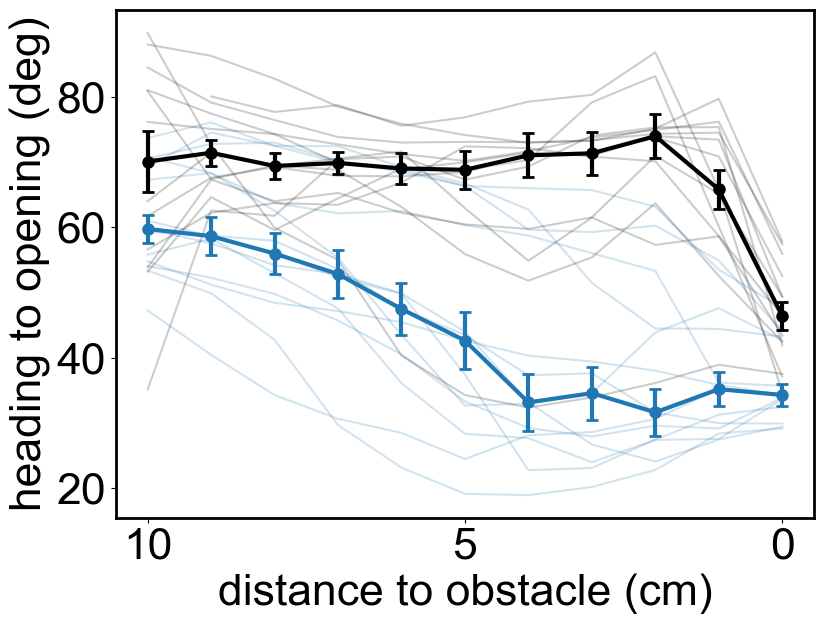

In [31]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32,
        'weight':'normal'}
plt.rc('font', **font)

xnew = np.arange(0, 11, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance<=15] 

# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1.5)
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1.5)

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([10,5,0])
ax.set_yticks([20,40,60,80])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)


# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
#ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\short_heading_to_opening_lines_1.pdf", 
#            dpi=300, transparent=True)

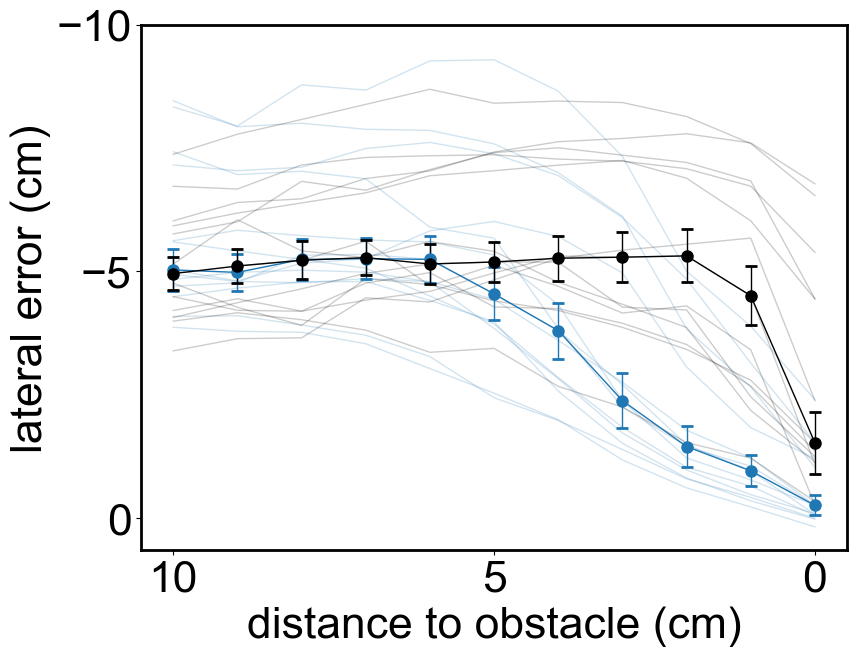

In [32]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'normal',
        'size': 21}
plt.rc('font', **font)

xnew = np.arange(0, 11, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')

#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance<=15]  

def fill_nans_ffill(arr):
    """Fill NaN values using forward-fill only"""
    # Create a pandas Series for easy NaN handling
    series = pd.Series(arr)
    # Forward fill only
    filled = series.ffill()
    return filled.values

light_medians = []
dark_medians = []
light_lines = []  # Store individual animal lines
dark_lines = []   # Store individual animal lines

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            interpolated = interpolater(xnew)
            
            # Check for NaNs and fill them with forward-fill only
            if np.any(np.isnan(interpolated)):
                interpolated = fill_nans_ffill(interpolated)
            
            angle_array[i] = interpolated
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                interpolated = interpolater(xnew)
                
                # Check for NaNs and fill them with forward-fill only
                if np.any(np.isnan(interpolated)):
                    interpolated = fill_nans_ffill(interpolated)
                
                animal_angle_array[i] = interpolated
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)

# Calculate SEM instead of SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

# Calculate number of non-nan observations for each distance point
light_n = np.sum(~np.isnan(light_medians), axis=0)
dark_n = np.sum(~np.isnan(dark_medians), axis=0)

# Calculate standard error of the mean
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(light_n)
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(dark_n)

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1, linestyle='-')
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1, linestyle='-')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, np.nanmedian(light_medians,axis = 0), yerr=light_sem,
           color='tab:blue', linewidth=1, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, np.nanmedian(dark_medians,axis = 0), yerr=dark_sem,
           color='black', linewidth=1, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
ax.set_xticks([10,5,0])
ax.set_yticks([-10,-5,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')

ax.invert_yaxis()

plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\short_lateral_error_lines_1.pdf", dpi=300, transparent=True)
plt.show()

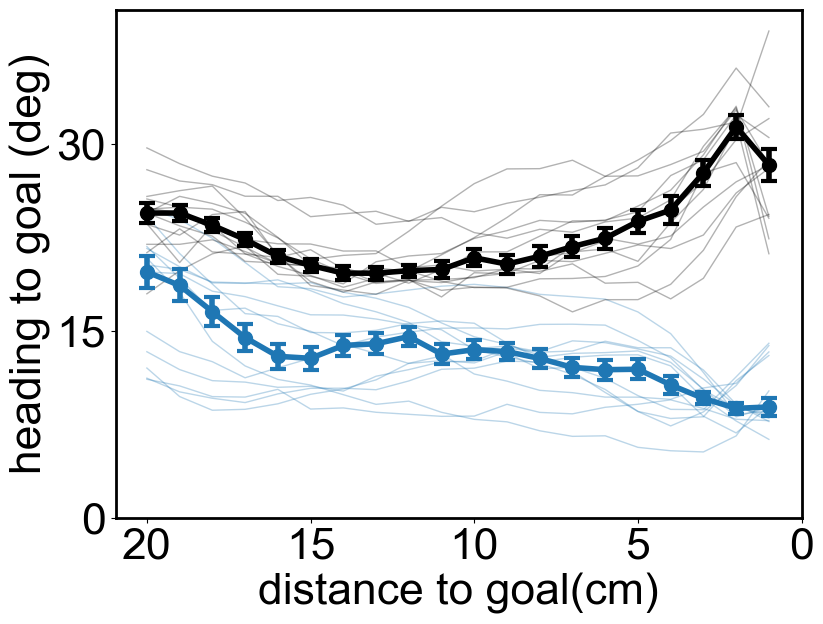

In [34]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 


# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append((xnew, animal_median, animal))
        else:
            dark_medians.append(animal_median)
            dark_lines.append((xnew, animal_median, animal))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual animal lines first (so they're behind)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=4, 
           marker='o', markersize=10, capsize=6, capthick=3,
           label='light', zorder=5)

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=4, 
           marker='o', markersize=10, capsize=6, capthick=3,
           label='dark', zorder=5)

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,15,30])
ax.set_ylabel('heading to goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)



plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_to_goal_lines.pdf", 
#            dpi=300, transparent=True)
plt.show()

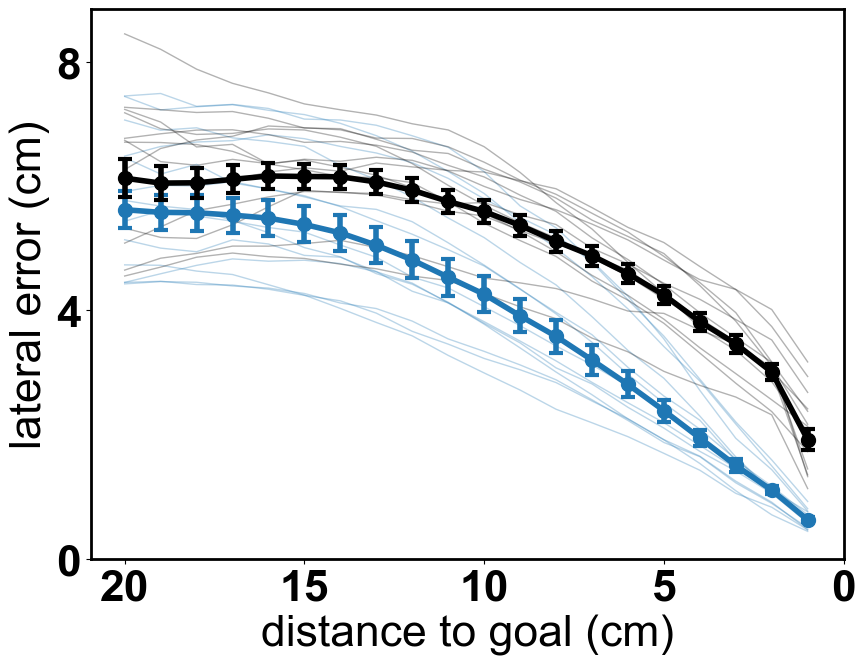

In [35]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
#data = data[~data['obstacle_cluster'].isin([2,3])] 


light_medians = []
dark_medians = []
light_lines = []  # Store individual animal lines
dark_lines = []   # Store individual animal lines

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_lateral_error_to_target_port'].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_lateral_error_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append((xnew, animal_median, animal))
        else:
            dark_medians.append(animal_median)
            dark_lines.append((xnew, animal_median, animal))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual animal lines first (so they're behind)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=4, marker='o', markersize=10,
           capsize=5, capthick=3, label='light', zorder=5)

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=4, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark', zorder=5)

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([8,4,0])
ax.set_ylabel('lateral error (cm)')

ax.set_xlabel('distance to goal (cm)')

plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_goal_lines.pdf", 
#            dpi=300, transparent=True)
plt.show()

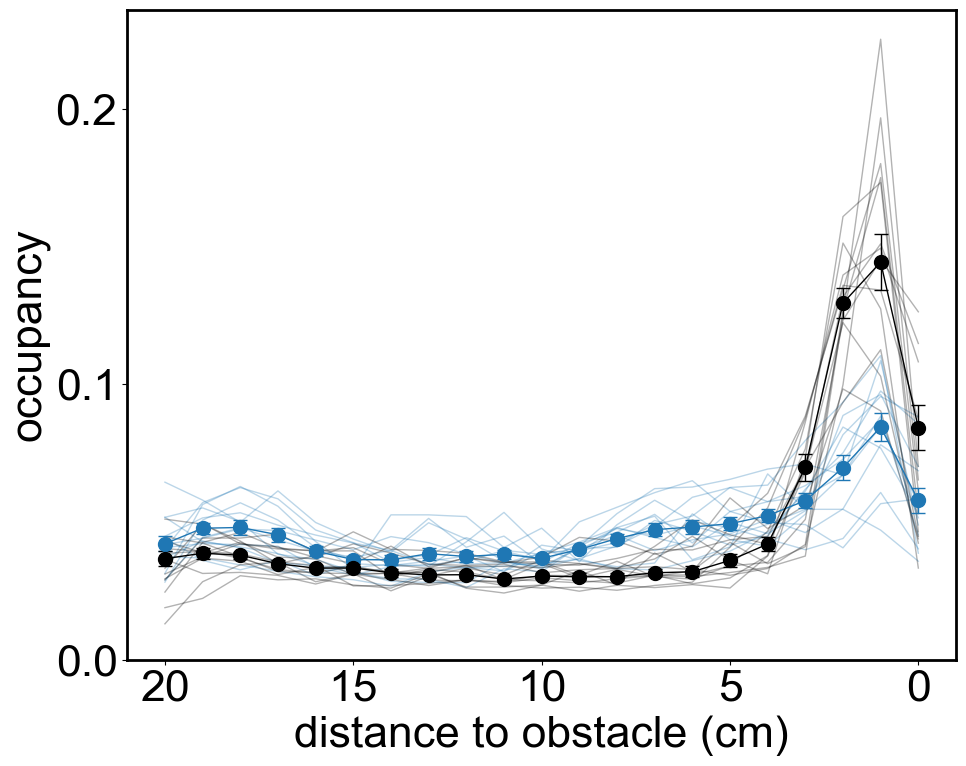

In [15]:
xnew = np.arange(0, 21, 1)
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
#data = data[data.avg_lateral_error<0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'normal', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']

light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_lines = []  # To store individual animal lines

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Store data for line plots (no jitter needed for lines)
    light_lines.append((xnew, prob, ani))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_lines = []  # To store individual animal lines

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Store data for line plots (no jitter needed for lines)
    dark_lines.append((xnew, prob, ani))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot mean lines with SEM error bars (thicker for visibility)
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=1,
           markersize=10, capsize=5, capthick=1,
           label='light', zorder=5)

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=1,
           markersize=10, capsize=5, capthick=1,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('occupancy', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.invert_xaxis()

plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\distance_to_obstacle_lines.pdf",dpi = 300, transparent=True)
plt.show()

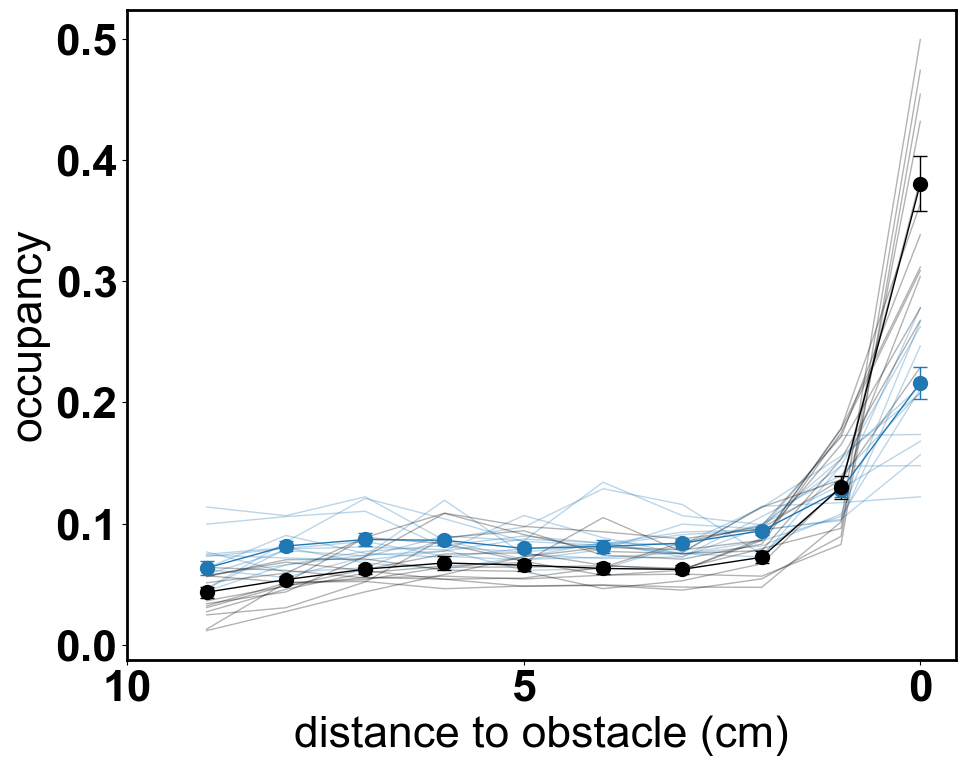

In [36]:
xnew = np.arange(0, 10, 1)
data = pd.concat([light_dark]) 
#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance<=10]  
#data = data[data.avg_lateral_error<0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'normal', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']

light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 10))]
light_counts, light_bins = np.histogram(light_dist, bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_lines = []  # To store individual animal lines

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 10))]
    counts, bins = np.histogram(ani_light_dists, bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Store data for line plots (no jitter needed for lines)
    light_lines.append((xnew, prob, ani))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 10))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_lines = []  # To store individual animal lines

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 10))]
    counts, bins = np.histogram(ani_dark_dists, bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Store data for line plots (no jitter needed for lines)
    dark_lines.append((xnew, prob, ani))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot mean lines with SEM error bars (thicker for visibility)
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=1,
           markersize=10, capsize=5, capthick=1,
           label='light', zorder=5)

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=1,
           markersize=10, capsize=5, capthick=1,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([ 10, 5, 0])
#ax.set_yticks([0, 0.1, 0.2,.3,.4])
ax.set_ylabel('occupancy', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.invert_xaxis()

plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\short_distance_to_obstacle_lines.pdf",dpi = 300, transparent=True)
plt.show()

In [23]:
light_sem

array([0.01294152, 0.00716649, 0.00418514, 0.00331307, 0.00570527,
       0.00391975, 0.00431218, 0.00495346, 0.00461995, 0.00601865])

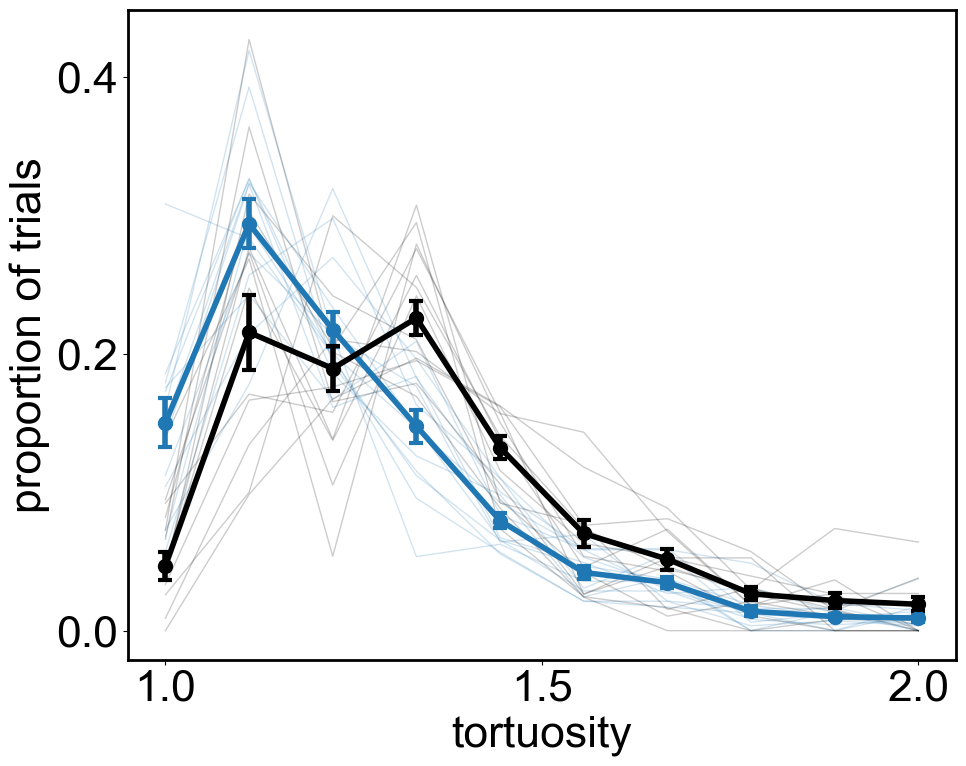

In [37]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=15]
#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance<=15] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'normal', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10,range=(1,2))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_lines = []  # Changed to store lines
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    counts, bins = np.histogram(ani_light_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Store data for line plots (no jitter needed for lines)
    light_lines.append((xnew, prob, ani))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10,range=(1,2))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_lines = []  # Changed to store lines
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Store data for line plots (no jitter needed for lines)
    dark_lines.append((xnew, prob, ani))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.2, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.2, linewidth=1, zorder=1)

# Plot mean lines with SEM error bars (thicker for visibility)
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='light', zorder=5)

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('tortuosity', fontweight='normal')     # Not bold





plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\tortuosity_lines.pdf",dpi = 300, transparent=True)
plt.show()

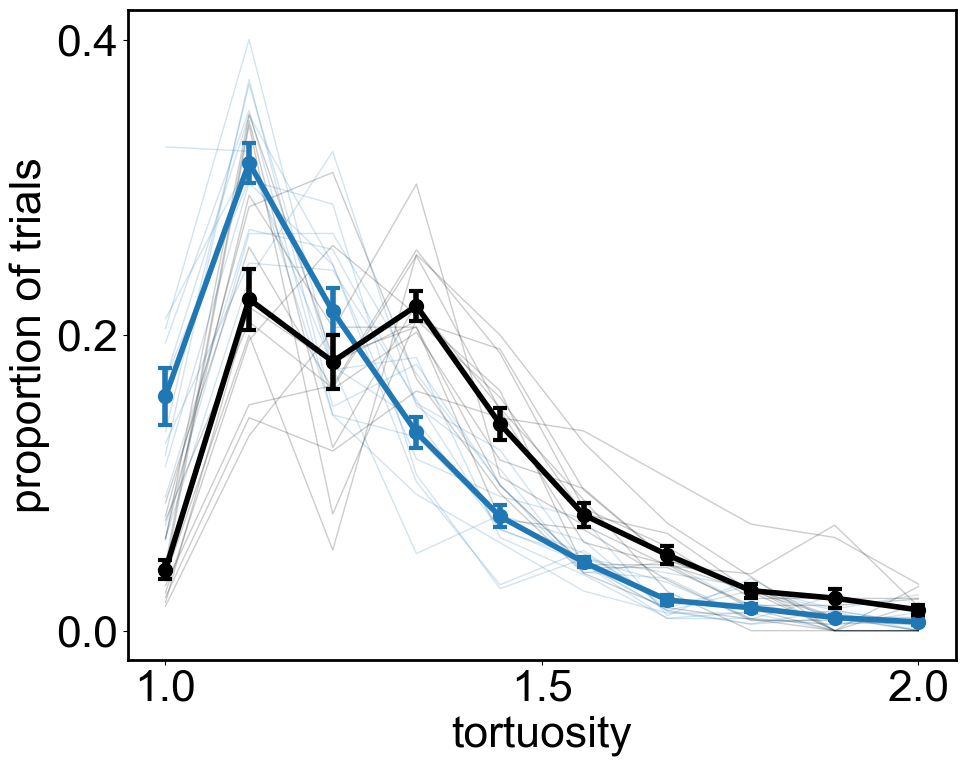

In [38]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=15]
#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)


# Process light condition
light = data[data.task == 'oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10,range=(1,2))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_lines = []  # Changed to store lines
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    counts, bins = np.histogram(ani_light_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Store data for line plots (no jitter needed for lines)
    light_lines.append((xnew, prob, ani))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10,range=(1,2))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_lines = []  # Changed to store lines
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Store data for line plots (no jitter needed for lines)
    dark_lines.append((xnew, prob, ani))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.2, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.2, linewidth=1, zorder=1)

# Plot mean lines with SEM error bars (thicker for visibility)
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='light', zorder=5)

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('tortuosity', fontweight='normal')     # Not bold



plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\short_tortuosity_lines.pdf",dpi = 300, transparent=True)
plt.show()

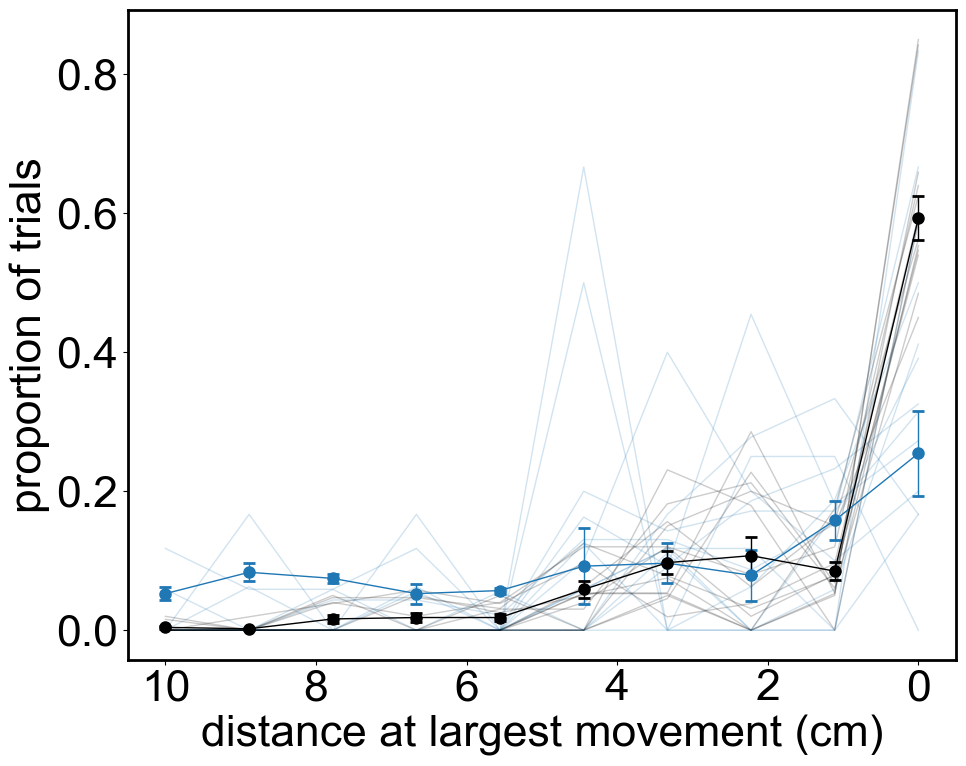

In [17]:
xnew = np.linspace(0, 10, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=20]
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance<=10] 
data = data[data.intial_lateral_error<0] 
#data = data[data.distance_at_head_turn>=0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, normal for numbers)
font = {'family': 'arial', 'weight': 'normal', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]

light_counts, light_bins = np.histogram(light_dist, bins=len(xnew),range=(0,10))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Plot individual animal as line instead of scatter
    ax.plot(xnew, prob, color='tab:blue', alpha=0.2, linewidth=1, linestyle='-')

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew),range=(0,20))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Plot individual animal as line instead of scatter
    ax.plot(xnew, prob, color='black', alpha=0.2, linewidth=1, linestyle='-')

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=1,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=1,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not normal
ax.set_xlabel('distance at largest movement (cm)', fontweight='normal')     # Not normal
ax.invert_xaxis()

# Make only the numbers normal
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')

plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\hist_distance_at_headturn_trace_lines.pdf",dpi = 300, transparent=True)
plt.show()

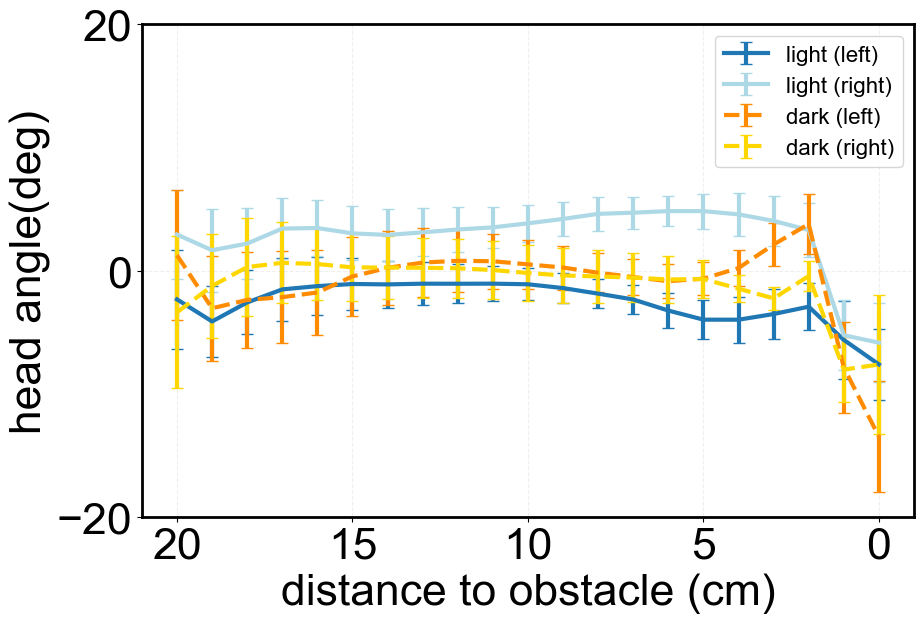

In [42]:
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32,
        'weight':'normal'}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10, 7))

data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 

# Define tasks with different color schemes
tasks = ['oa', 'oadark']
# Define directions from odd parameter
directions = ['left', 'right']

# Different color schemes for each task
task_colors = {
    'oa': {'left': 'tab:blue', 'right': 'lightblue'},
    'oadark': {'left': 'darkorange', 'right': 'gold'}
}
line_styles = {'oa': '-', 'oadark': '--'}
task_labels = {'oa': 'light', 'oadark': 'dark'}
direction_labels = {'left': 'left', 'right': 'right'}

ax.invert_xaxis()

for task in tasks:
    for direction in directions:
        # Filter data for this task and direction
        task_dir_data = data[(data.task == task) & (data.odd == direction)]
        
        # Storage for head angle data for this task and direction
        head_angle_means = []
        
        # Process each animal for this task and direction
        for animal, animal_df in task_dir_data.groupby(['animal']):
            # Array for head angle
            head_angle_array = np.empty([animal_df.shape[0], len(xnew)])
            head_angle_array[:] = np.nan
            
            for i, row in enumerate(animal_df.iterrows()):
                row_data = row[1]
                x = row_data['ts_distance_from_edge'][:int(row_data['obstacle_ind'])].astype(float)
                x1 = x[first_occurrence_indices(np.round(x))]
                
                # Process head angle
                if 'head_angle' in row_data:
                    y_head = row_data['head_angle'][:int(row_data['obstacle_ind'])].astype(float)
                    y1_head = y_head[first_occurrence_indices(np.round(x))]
                    if len(y_head) > 0 and sum(~np.isnan(y_head)) > 0:
                        interpolater = interp1d(x1, y1_head, bounds_error=False)
                        head_angle_array[i] = interpolater(xnew)
            
            # Calculate animal mean
            animal_head_mean = np.nanmean(head_angle_array, axis=0)
            head_angle_means.append(animal_head_mean)
        
        # Skip if no data for this task-direction combination
        if len(head_angle_means) == 0:
            continue
            
        # Convert to numpy array
        head_angle_means = np.array(head_angle_means)
        
        # Calculate population statistics
        head_angle_pop_mean = np.nanmean(head_angle_means, axis=0)
        
        # Calculate standard error
        head_angle_sem = np.nanstd(head_angle_means, axis=0) / np.sqrt(np.sum(~np.isnan(head_angle_means), axis=0))
        
        # Plot mean line with SEM error bars
        ls = line_styles[task]
        color = task_colors[task][direction]
        
        label = f'{task_labels[task]} ({direction_labels[direction]})'
        
        ax.errorbar(xnew, head_angle_pop_mean, yerr=head_angle_sem, 
                   fmt=ls, color=color, linewidth=3, 
                   markersize=8, capsize=4, capthick=2,
                   label=label, markeredgecolor='white', markeredgewidth=1)

# Formatting
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-20,0,20])
ax.set_ylabel('head angle(deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.grid(True, alpha=0.2, linestyle='--')

# Add legend with reduced font size to fit all entries
ax.legend(loc='best', fontsize=16)

plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"

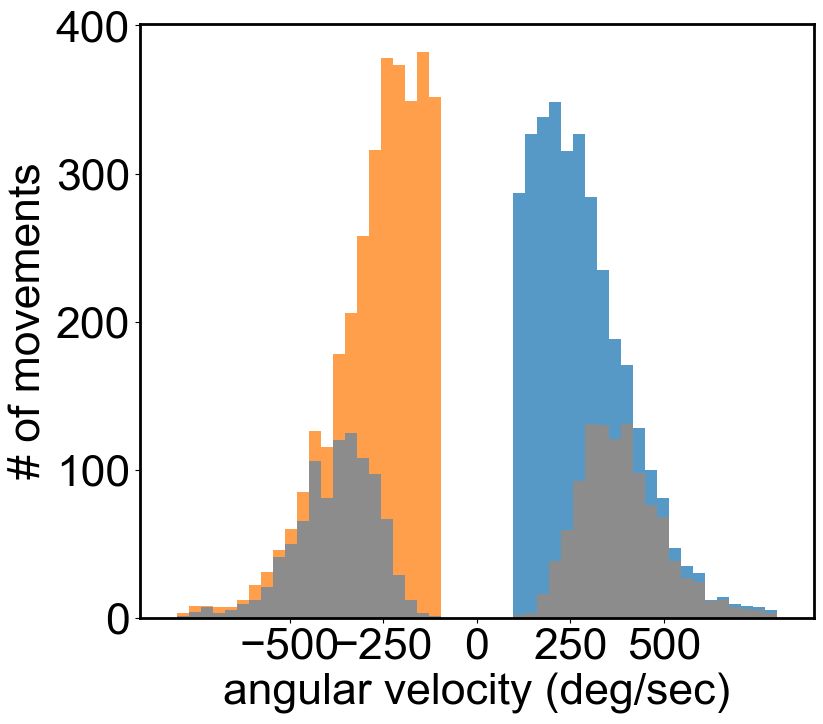

In [31]:
import numpy as np
import matplotlib.pyplot as plt
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
#data = data[data.animal =='G8CKRT']



light = data[data.task == 'oa']

# Create figure
fig, ax = plt.subplots(figsize=(9, 8))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
full_neg = flatten_list_of_arrays(light.negative_heights.to_list()) * 60

# Get largest movements subset
all_largest = light.head_turn_velocity.to_numpy() * 60
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos,range=(0,800))
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos,range=(0,800))
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg,range=(-800,0))
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg,range=(-800,0))
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500,-250, 0, 250,500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
#ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [9]:
light_dark.animal.unique()

array(['J701LT', 'J701RT', 'J701NN', 'J701RN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'], dtype=object)

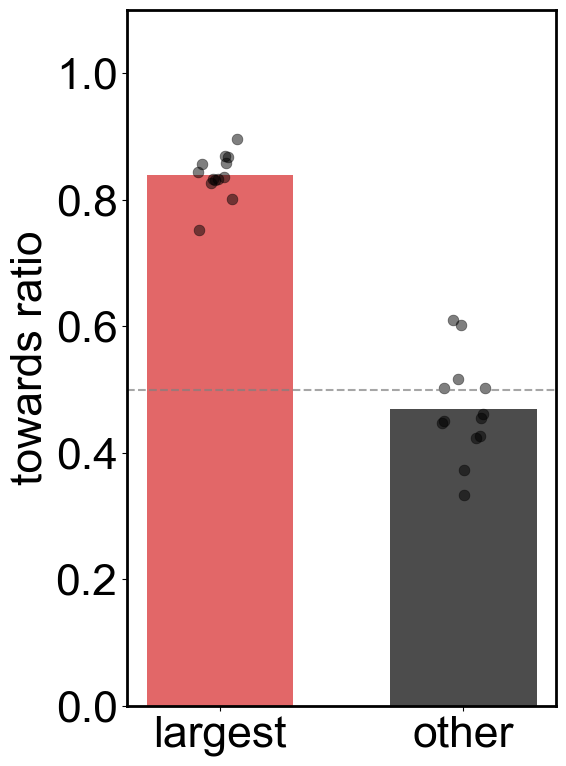

Population average (based on animal means):
  Largest turns towards ratio: 0.839
  Other turns towards ratio: 0.469

Number of animals: 13
Total trials: 3121


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter and process data as before
data = pd.concat([light_dark]) 
#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store results
results = []

# Process each row to calculate towards ratios
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data
    if task != 'oa':
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60  # Convert as in your code
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Calculate towards ratio for largest turn (negative values)
    largest_towards = 1 if largest_turn < 0 else 0
    
    # Calculate towards ratio for other turns
    if len(other_turns) > 0:
        other_towards = np.sum(np.array(other_turns) < 0) / len(other_turns)
    else:
        other_towards = 0
    
    results.append({
        'animal': animal,
        'task': task,
        'largest_towards': largest_towards,
        'other_towards': other_towards
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Check if we have OA data
if len(results_df) > 0:
    # Calculate individual animal averages for OA
    animal_ratios = results_df.groupby(['animal', 'task']).agg({
        'largest_towards': 'mean',
        'other_towards': 'mean'
    }).reset_index()
    
    # Calculate population averages based on animal averages
    # This gives each animal equal weight in the population statistics
    population_largest_mean = animal_ratios['largest_towards'].mean()
    population_other_mean = animal_ratios['other_towards'].mean()
    
    # Create arrays for population statistics
    population_ratios = {
        'largest_towards': population_largest_mean,
        'other_towards': population_other_mean
    }
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # Bar width and positions
    bar_width = 0.6
    x_positions = [0, 1]
    
    # Plot bars using population averages
    bars1 = ax.bar(0, population_largest_mean, 
                   bar_width, color='tab:red', alpha=0.7)
    bars2 = ax.bar(1, population_other_mean, 
                   bar_width, color='black', alpha=0.7)
    
    # Add horizontal dotted line at 0.5
    ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Add individual animal scatter points
    task_data = animal_ratios[animal_ratios['task'] == 'oa']
    
    if len(task_data) > 0:
        # Reduced jitter for less spread
        jitter1 = np.random.uniform(-0.09, 0.09, size=len(task_data))
        jitter2 = np.random.uniform(-0.09, 0.09, size=len(task_data))
        
        # Plot individual animal points for largest turns
        ax.scatter([0] * len(task_data) + jitter1, 
                   task_data['largest_towards'], 
                   color='black', alpha=0.5, 
                   linewidth=0.5, s=60)
        
        # Plot individual animal points for other turns
        ax.scatter([1] * len(task_data) + jitter2, 
                   task_data['other_towards'], 
                   color='black', alpha=0.5,  
                   linewidth=0.5, s=60)
    
    # Customize the plot
    ax.set_ylabel('towards ratio')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['largest', 'other'])
    ax.set_ylim(0, 1.1)
    

    
    plt.tight_layout()
    plt.show()
    
    # Print population statistics
    print(f"Population average (based on animal means):")
    print(f"  Largest turns towards ratio: {population_largest_mean:.3f}")
    print(f"  Other turns towards ratio: {population_other_mean:.3f}")
    print(f"\nNumber of animals: {len(task_data)}")
    print(f"Total trials: {len(results_df)}")
    
else:
    print("No OA data found after filtering")

Wilcoxon signed-rank test results:
  Test statistic: 91.0
  p-value: 0.000122
  Significance: *** (p < 0.001)
  Number of animals: 13


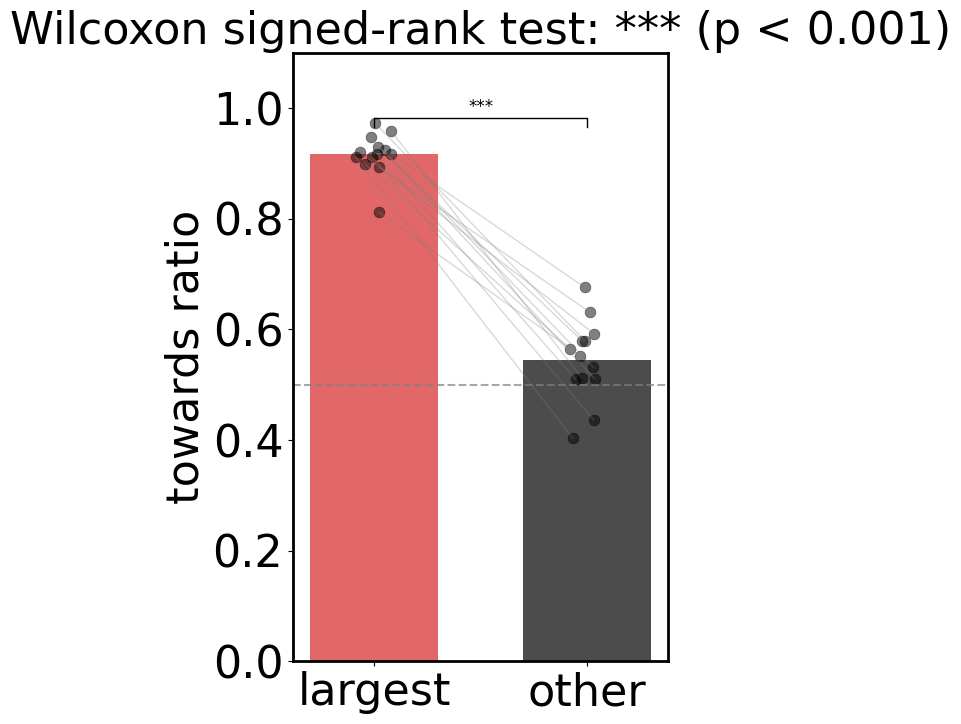


Population statistics (based on animal means):
  Largest turns towards ratio: 0.917 ± 0.039
  Other turns towards ratio: 0.545 ± 0.074

Number of animals: 13
Total trials: 2205

Individual animal data:
  Animal G8CK1LN: largest=0.920, other=0.592
  Animal G8CK1LT: largest=0.959, other=0.512
  Animal G8CK1RT: largest=0.974, other=0.580
  Animal G8CK1TT: largest=0.948, other=0.511
  Animal G8CKLN: largest=0.900, other=0.565
  Animal G8CKLT: largest=0.924, other=0.531
  Animal G8CKRN: largest=0.912, other=0.436
  Animal G8CKRT: largest=0.918, other=0.510
  Animal G8CKTT: largest=0.912, other=0.403
  Animal J701LT: largest=0.812, other=0.553
  Animal J701NN: largest=0.930, other=0.580
  Animal J701RN: largest=0.895, other=0.632
  Animal J701RT: largest=0.918, other=0.676


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Filter and process data as before
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store results
results = []

# Process each row to calculate towards ratios
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data
    if task != 'oa':
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60  # Convert as in your code
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Calculate towards ratio for largest turn (negative values)
    largest_towards = 1 if largest_turn < 0 else 0
    
    # Calculate towards ratio for other turns
    if len(other_turns) > 0:
        other_towards = np.sum(np.array(other_turns) < 0) / len(other_turns)
    else:
        other_towards = 0
    
    results.append({
        'animal': animal,
        'task': task,
        'largest_towards': largest_towards,
        'other_towards': other_towards
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Check if we have OA data
if len(results_df) > 0:
    # Calculate individual animal averages for OA
    animal_ratios = results_df.groupby(['animal', 'task']).agg({
        'largest_towards': 'mean',
        'other_towards': 'mean'
    }).reset_index()
    
    # Perform Wilcoxon signed-rank test
    # Extract paired data for each animal
    largest_ratios = animal_ratios['largest_towards'].values
    other_ratios = animal_ratios['other_towards'].values
    
    # Check if we have enough data points for the test
    if len(largest_ratios) > 0 and len(other_ratios) > 0:
        try:
            # Perform Wilcoxon signed-rank test
            stat, p_value = wilcoxon(largest_ratios, other_ratios, 
                                     alternative='greater')
            
            print(f"Wilcoxon signed-rank test results:")
            print(f"  Test statistic: {stat}")
            print(f"  p-value: {p_value:.6f}")
            
            if p_value < 0.001:
                significance = "*** (p < 0.001)"
            elif p_value < 0.01:
                significance = "** (p < 0.01)"
            elif p_value < 0.05:
                significance = "* (p < 0.05)"
            else:
                significance = "ns (not significant)"
            
            print(f"  Significance: {significance}")
            print(f"  Number of animals: {len(largest_ratios)}")
            
        except Exception as e:
            print(f"Error performing Wilcoxon test: {e}")
            p_value = np.nan
            significance = "Test failed"
    else:
        print("Not enough data for Wilcoxon test")
        p_value = np.nan
        significance = ""
    
    # Calculate population averages based on animal averages
    population_largest_mean = animal_ratios['largest_towards'].mean()
    population_other_mean = animal_ratios['other_towards'].mean()
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # Bar width and positions
    bar_width = 0.6
    x_positions = [0, 1]
    
    # Plot bars using population averages
    bars1 = ax.bar(0, population_largest_mean, 
                   bar_width, color='tab:red', alpha=0.7)
    bars2 = ax.bar(1, population_other_mean, 
                   bar_width, color='black', alpha=0.7)
    
    # Add horizontal dotted line at 0.5
    ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Add individual animal scatter points and connect them with lines
    task_data = animal_ratios[animal_ratios['task'] == 'oa']
    
    if len(task_data) > 0:
        # Reduced jitter for less spread
        jitter1 = np.random.uniform(-0.09, 0.09, size=len(task_data))
        jitter2 = np.random.uniform(-0.09, 0.09, size=len(task_data))
        
        # Plot individual animal points for largest turns
        ax.scatter([0] * len(task_data) + jitter1, 
                   task_data['largest_towards'], 
                   color='black', alpha=0.5, 
                   linewidth=0.5, s=60)
        
        # Plot individual animal points for other turns
        ax.scatter([1] * len(task_data) + jitter2, 
                   task_data['other_towards'], 
                   color='black', alpha=0.5,  
                   linewidth=0.5, s=60)
        
        # Connect paired points with lines
        for i in range(len(task_data)):
            ax.plot([0 + jitter1[i], 1 + jitter2[i]], 
                    [task_data['largest_towards'].iloc[i], 
                     task_data['other_towards'].iloc[i]], 
                    color='gray', alpha=0.3, linewidth=1)
    
    # Add significance bracket if test was successful
    if not np.isnan(p_value) and p_value < 0.05:
        # Calculate y position for the bracket
        y_max = max(population_largest_mean, population_other_mean)
        bracket_height = 0.05
        bracket_y = y_max + bracket_height
        
        # Draw the bracket
        ax.plot([0, 0, 1, 1], 
                [bracket_y, bracket_y + bracket_height*0.3, 
                 bracket_y + bracket_height*0.3, bracket_y], 
                color='black', linewidth=1)
        
        # Add p-value text
        if p_value < 0.001:
            p_text = "***"
        elif p_value < 0.01:
            p_text = "**"
        elif p_value < 0.05:
            p_text = "*"
        
        ax.text(0.5, bracket_y + bracket_height*0.4, p_text, 
                ha='center', va='bottom', fontsize=12)
    
    # Customize the plot
    ax.set_ylabel('towards ratio')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['largest', 'other'])
    ax.set_ylim(0, 1.1)
    
    # Add title with test results
    if significance:
        ax.set_title(f"Wilcoxon signed-rank test: {significance}")
    
    plt.tight_layout()
    plt.show()
    
    # Print population statistics
    print(f"\nPopulation statistics (based on animal means):")
    print(f"  Largest turns towards ratio: {population_largest_mean:.3f} ± {animal_ratios['largest_towards'].std():.3f}")
    print(f"  Other turns towards ratio: {population_other_mean:.3f} ± {animal_ratios['other_towards'].std():.3f}")
    print(f"\nNumber of animals: {len(task_data)}")
    print(f"Total trials: {len(results_df)}")
    
    # Also print individual animal data for reference
    print("\nIndividual animal data:")
    for i, row in animal_ratios.iterrows():
        print(f"  Animal {row['animal']}: largest={row['largest_towards']:.3f}, other={row['other_towards']:.3f}")
    
else:
    print("No OA data found after filtering")

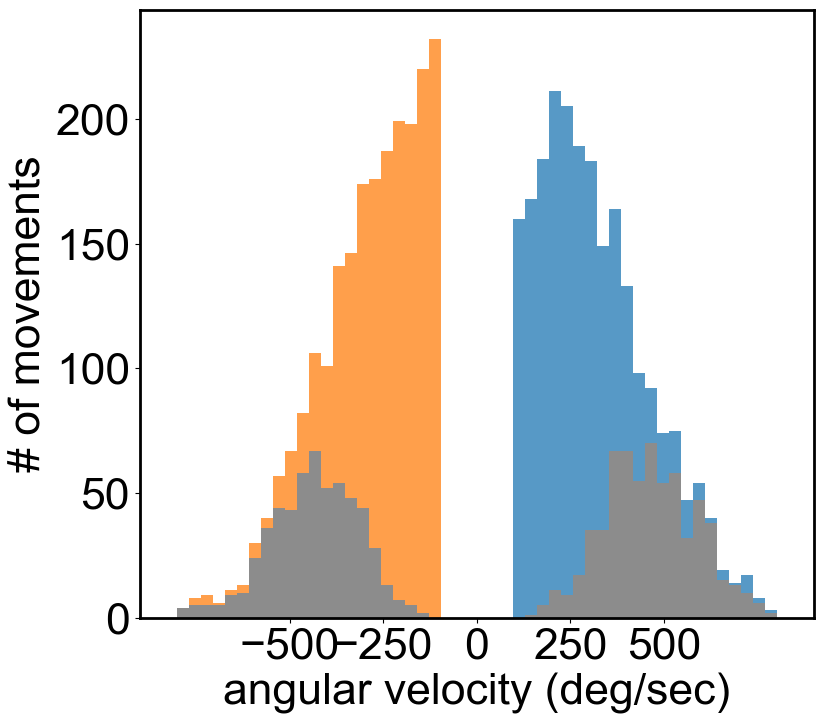

In [32]:
import numpy as np
import matplotlib.pyplot as plt
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
#data = data[data.animal =='G8CKRT']



light = data[data.task == 'oadark']

# Create figure
fig, ax = plt.subplots(figsize=(9, 8))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
full_neg = flatten_list_of_arrays(light.negative_heights.to_list()) * 60

# Get largest movements subset
all_largest = light.head_turn_velocity.to_numpy() * 60
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos,range=(0,800))
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos,range=(0,800))
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg,range=(-800,0))
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg,range=(-800,0))
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500,-250, 0, 250,500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
#ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

Processing 13 animals


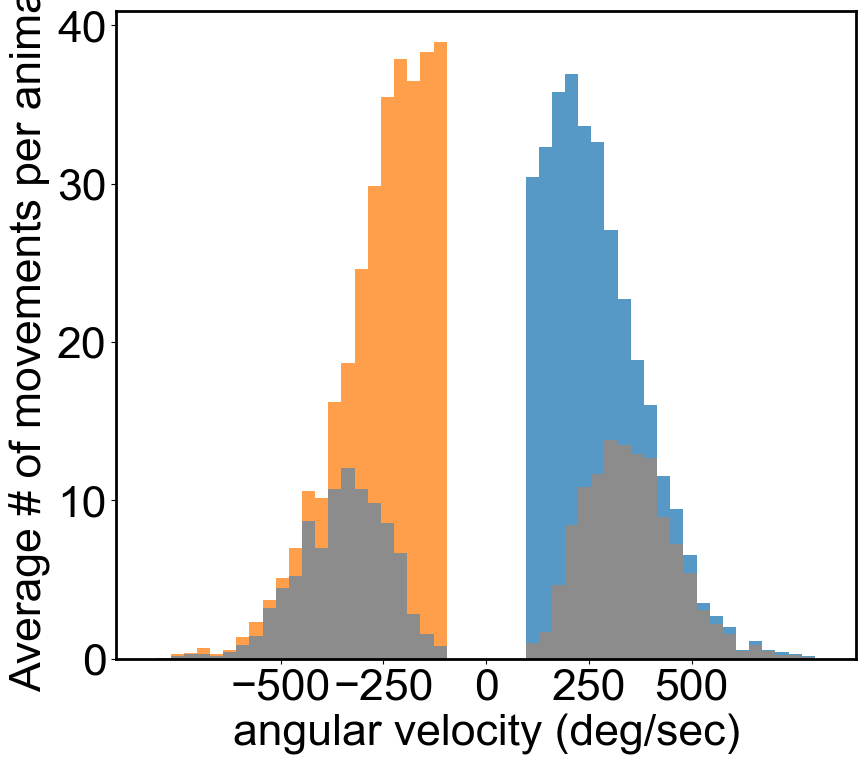


=== Summary Statistics ===
Number of animals: 13
Total trials: 3121
Average trials per animal: 240.08

Average proportion of largest turns: 0.797
Average proportion of other positive turns: 0.321
Average proportion of other negative turns: 0.365


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.concat([light_dark]) 
#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

light = data[data.task == 'oa']

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Get unique animals
animals = light['animal'].unique()
print(f"Processing {len(animals)} animals")

# Lists to store individual animal histograms
animal_pos_histograms = []
animal_neg_histograms = []

# Process each animal separately
for animal in animals:
    animal_data = light[light['animal'] == animal]
    
    # Get full dataset for this animal
    full_pos = flatten_list_of_arrays(animal_data.positive_heights.to_list()) * 60
    full_neg = flatten_list_of_arrays(animal_data.negative_heights.to_list()) * 60
    
    # Get largest movements subset for this animal
    all_largest = animal_data.head_turn_velocity.to_numpy() * 60
    largest_pos = all_largest[all_largest > 0]
    largest_neg = all_largest[all_largest < 0]
    
    # Compute histograms for this animal
    counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos, range=(0, 800))
    counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos, range=(0, 800))
    counts_rest_pos = counts_full_pos - counts_largest_pos
    
    counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg, range=(-800, 0))
    counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg, range=(-800, 0))
    counts_rest_neg = counts_full_neg - counts_largest_neg
    
    # Calculate total movements per bin for this animal
    total_movements_pos = counts_full_pos
    total_movements_neg = counts_full_neg
    
    # Calculate proportions (handle division by zero)
    prop_largest_pos = np.zeros_like(counts_largest_pos, dtype=float)
    prop_rest_pos = np.zeros_like(counts_rest_pos, dtype=float)
    
    for i in range(len(counts_largest_pos)):
        if total_movements_pos[i] > 0:
            prop_largest_pos[i] = counts_largest_pos[i] / total_movements_pos[i]
            prop_rest_pos[i] = counts_rest_pos[i] / total_movements_pos[i]
    
    prop_largest_neg = np.zeros_like(counts_largest_neg, dtype=float)
    prop_rest_neg = np.zeros_like(counts_rest_neg, dtype=float)
    
    for i in range(len(counts_largest_neg)):
        if total_movements_neg[i] > 0:
            prop_largest_neg[i] = counts_largest_neg[i] / total_movements_neg[i]
            prop_rest_neg[i] = counts_rest_neg[i] / total_movements_neg[i]
    
    # Store proportions for this animal
    animal_pos_histograms.append({
        'prop_largest': prop_largest_pos,
        'prop_rest': prop_rest_pos,
        'counts_total': total_movements_pos,
        'n_trials': len(animal_data)
    })
    
    animal_neg_histograms.append({
        'prop_largest': prop_largest_neg,
        'prop_rest': prop_rest_neg,
        'counts_total': total_movements_neg,
        'n_trials': len(animal_data)
    })

# Calculate average proportions across animals
avg_prop_largest_pos = np.mean([h['prop_largest'] for h in animal_pos_histograms], axis=0)
avg_prop_rest_pos = np.mean([h['prop_rest'] for h in animal_pos_histograms], axis=0)

avg_prop_largest_neg = np.mean([h['prop_largest'] for h in animal_neg_histograms], axis=0)
avg_prop_rest_neg = np.mean([h['prop_rest'] for h in animal_neg_histograms], axis=0)

# Calculate average total movements per animal for scaling
avg_counts_total_pos = np.mean([h['counts_total'] for h in animal_pos_histograms], axis=0)
avg_counts_total_neg = np.mean([h['counts_total'] for h in animal_neg_histograms], axis=0)

# Scale proportions by average total movements
avg_counts_largest_pos = avg_prop_largest_pos * avg_counts_total_pos
avg_counts_rest_pos = avg_prop_rest_pos * avg_counts_total_pos

avg_counts_largest_neg = avg_prop_largest_neg * avg_counts_total_neg
avg_counts_rest_neg = avg_prop_rest_neg * avg_counts_total_neg

# Create figure
fig, ax = plt.subplots(figsize=(9, 8))

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, avg_counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, avg_counts_rest_pos, width_pos, 
       bottom=avg_counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, avg_counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, avg_counts_rest_neg, width_neg, 
       bottom=avg_counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500, -250, 0, 250, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('Average # of movements per animal')
ax.set_xlim(-900, 900)

# Add text with statistics
total_animals = len(animals)
total_trials = light.shape[0]
avg_trials_per_animal = np.mean([h['n_trials'] for h in animal_pos_histograms])


# Create custom legend handles
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='grey', alpha=0.9, label='largest turns'),
    Patch(facecolor='tab:blue', alpha=0.75, label='other positive turns'),
    Patch(facecolor='tab:orange', alpha=0.75, label='other negative turns')
]
#ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== Summary Statistics ===")
print(f"Number of animals: {total_animals}")
print(f"Total trials: {total_trials}")
print(f"Average trials per animal: {avg_trials_per_animal:.2f}")

# Calculate and print some key proportions
avg_total_largest_prop = np.mean(avg_prop_largest_pos) + np.mean(avg_prop_largest_neg)
print(f"\nAverage proportion of largest turns: {avg_total_largest_prop:.3f}")
print(f"Average proportion of other positive turns: {np.mean(avg_prop_rest_pos):.3f}")
print(f"Average proportion of other negative turns: {np.mean(avg_prop_rest_neg):.3f}")

Processing 13 animals


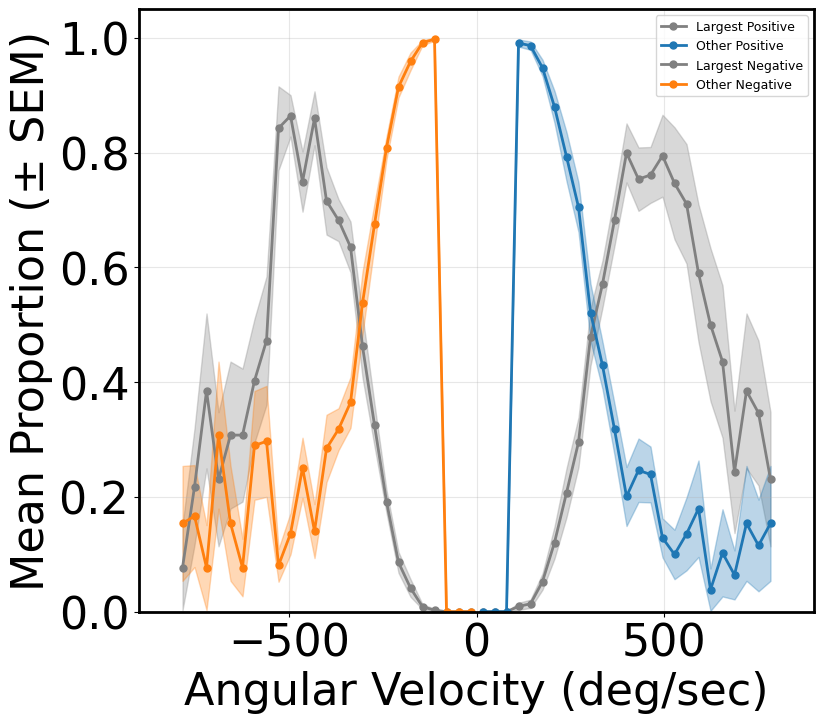


=== Summary Statistics ===
Number of animals: 13
Total trials: 2205
Average trials per animal: 169.62
Total positive movements: 3296
Total negative movements: 3322
Total movements: 6618

Overall mean proportions:
  Largest positive turns: 0.389
  Other positive turns: 0.337
  Largest negative turns: 0.355
  Other negative turns: 0.359

Total proportion:
  Largest turns: 0.372
  Other turns: 0.348


In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]  

# Get data for oadark condition
light = data[data.task == 'oa']

# Get unique animals
animals = light['animal'].unique()
print(f"Processing {len(animals)} animals")

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Lists to store proportions for each animal
animal_proportions_pos = []
animal_proportions_neg = []

# Process each animal separately
for animal in animals:
    animal_data = light[light['animal'] == animal]
    
    # Get full dataset for this animal
    full_pos = flatten_list_of_arrays(animal_data.positive_heights.to_list()) * 60
    full_neg = flatten_list_of_arrays(animal_data.negative_heights.to_list()) * 60
    
    # Get largest movements subset for this animal
    all_largest = animal_data.head_turn_velocity.to_numpy() * 60
    largest_pos = all_largest[all_largest > 0]
    largest_neg = all_largest[all_largest < 0]
    
    # Compute histograms for this animal
    counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos, range=(0,800))
    counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos, range=(0,800))
    counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements
    
    counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg, range=(-800,0))
    counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg, range=(-800,0))
    counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements
    
    # Calculate proportions for this animal
    # For positive bins
    prop_largest_pos = np.zeros_like(counts_largest_pos, dtype=float)
    prop_rest_pos = np.zeros_like(counts_rest_pos, dtype=float)
    
    for i in range(len(counts_full_pos)):
        if counts_full_pos[i] > 0:
            prop_largest_pos[i] = counts_largest_pos[i] / counts_full_pos[i]
            prop_rest_pos[i] = counts_rest_pos[i] / counts_full_pos[i]
    
    # For negative bins
    prop_largest_neg = np.zeros_like(counts_largest_neg, dtype=float)
    prop_rest_neg = np.zeros_like(counts_rest_neg, dtype=float)
    
    for i in range(len(counts_full_neg)):
        if counts_full_neg[i] > 0:
            prop_largest_neg[i] = counts_largest_neg[i] / counts_full_neg[i]
            prop_rest_neg[i] = counts_rest_neg[i] / counts_full_neg[i]
    
    # Store proportions for this animal
    animal_proportions_pos.append({
        'prop_largest': prop_largest_pos,
        'prop_rest': prop_rest_pos,
        'total_movements': counts_full_pos,
        'n_trials': len(animal_data)
    })
    
    animal_proportions_neg.append({
        'prop_largest': prop_largest_neg,
        'prop_rest': prop_rest_neg,
        'total_movements': counts_full_neg,
        'n_trials': len(animal_data)
    })

# Calculate mean proportions across animals
mean_prop_largest_pos = np.mean([a['prop_largest'] for a in animal_proportions_pos], axis=0)
mean_prop_rest_pos = np.mean([a['prop_rest'] for a in animal_proportions_pos], axis=0)

mean_prop_largest_neg = np.mean([a['prop_largest'] for a in animal_proportions_neg], axis=0)
mean_prop_rest_neg = np.mean([a['prop_rest'] for a in animal_proportions_neg], axis=0)

# Also calculate SEM for error bars
sem_prop_largest_pos = np.std([a['prop_largest'] for a in animal_proportions_pos], axis=0) / np.sqrt(len(animals))
sem_prop_rest_pos = np.std([a['prop_rest'] for a in animal_proportions_pos], axis=0) / np.sqrt(len(animals))
sem_prop_largest_neg = np.std([a['prop_largest'] for a in animal_proportions_neg], axis=0) / np.sqrt(len(animals))
sem_prop_rest_neg = np.std([a['prop_rest'] for a in animal_proportions_neg], axis=0) / np.sqrt(len(animals))

# Create figure with specified size
fig, ax = plt.subplots(figsize=(9, 8))

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot line plot of mean proportions with SEM
ax.plot(bin_centers_pos, mean_prop_largest_pos, 'o-', color='grey', linewidth=2, 
        markersize=5, label='Largest Positive')
ax.fill_between(bin_centers_pos, 
                mean_prop_largest_pos - sem_prop_largest_pos, 
                mean_prop_largest_pos + sem_prop_largest_pos, 
                color='grey', alpha=0.3)

ax.plot(bin_centers_pos, mean_prop_rest_pos, 'o-', color='tab:blue', linewidth=2, 
        markersize=5, label='Other Positive')
ax.fill_between(bin_centers_pos, 
                mean_prop_rest_pos - sem_prop_rest_pos, 
                mean_prop_rest_pos + sem_prop_rest_pos, 
                color='tab:blue', alpha=0.3)

ax.plot(bin_centers_neg, mean_prop_largest_neg, 'o-', color='grey', linewidth=2, 
        markersize=5,  label='Largest Negative')
ax.fill_between(bin_centers_neg, 
                mean_prop_largest_neg - sem_prop_largest_neg, 
                mean_prop_largest_neg + sem_prop_largest_neg, 
                color='grey', alpha=0.3)

ax.plot(bin_centers_neg, mean_prop_rest_neg, 'o-', color='tab:orange', linewidth=2, 
        markersize=5,  label='Other Negative')
ax.fill_between(bin_centers_neg, 
                mean_prop_rest_neg - sem_prop_rest_neg, 
                mean_prop_rest_neg + sem_prop_rest_neg, 
                color='tab:orange', alpha=0.3)

ax.set_xticks([-500, 0,  500])
ax.set_xlabel('Angular Velocity (deg/sec)')
ax.set_ylabel('Mean Proportion (± SEM)')
ax.set_xlim(-900, 900)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
total_trials = light.shape[0]
avg_trials_per_animal = np.mean([a['n_trials'] for a in animal_proportions_pos])
total_movements_pos = np.sum([np.sum(a['total_movements']) for a in animal_proportions_pos])
total_movements_neg = np.sum([np.sum(a['total_movements']) for a in animal_proportions_neg])

print(f"\n=== Summary Statistics ===")
print(f"Number of animals: {len(animals)}")
print(f"Total trials: {total_trials}")
print(f"Average trials per animal: {avg_trials_per_animal:.2f}")
print(f"Total positive movements: {total_movements_pos}")
print(f"Total negative movements: {total_movements_neg}")
print(f"Total movements: {total_movements_pos + total_movements_neg}")

# Calculate overall proportions
overall_prop_largest_pos = np.mean(mean_prop_largest_pos)
overall_prop_rest_pos = np.mean(mean_prop_rest_pos)
overall_prop_largest_neg = np.mean(mean_prop_largest_neg)
overall_prop_rest_neg = np.mean(mean_prop_rest_neg)

print(f"\nOverall mean proportions:")
print(f"  Largest positive turns: {overall_prop_largest_pos:.3f}")
print(f"  Other positive turns: {overall_prop_rest_pos:.3f}")
print(f"  Largest negative turns: {overall_prop_largest_neg:.3f}")
print(f"  Other negative turns: {overall_prop_rest_neg:.3f}")

# Calculate proportion of largest vs other movements
total_prop_largest = (overall_prop_largest_pos + overall_prop_largest_neg) / 2
total_prop_other = (overall_prop_rest_pos + overall_prop_rest_neg) / 2
print(f"\nTotal proportion:")
print(f"  Largest turns: {total_prop_largest:.3f}")
print(f"  Other turns: {total_prop_other:.3f}")

Processing 13 animals


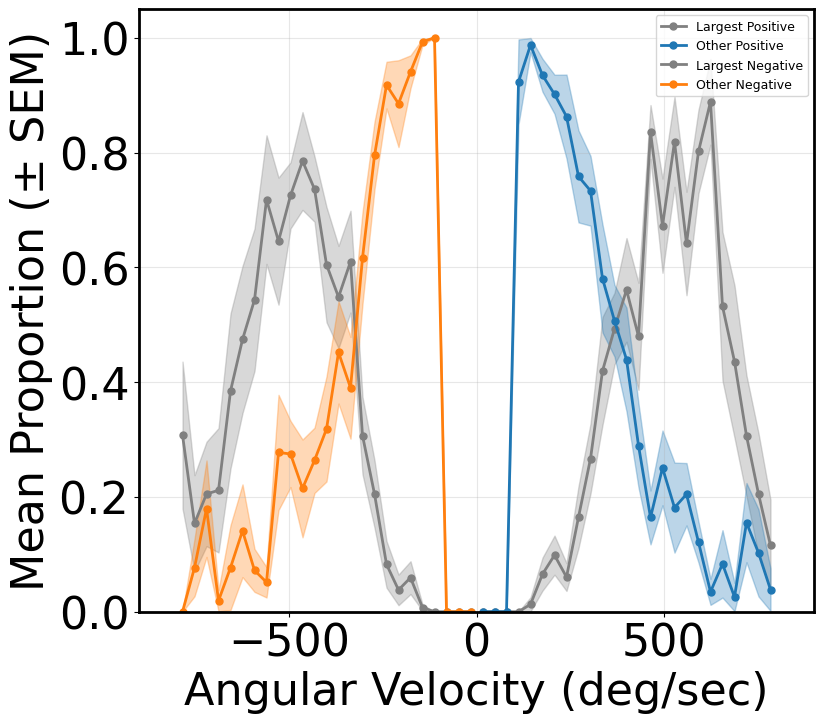


=== Summary Statistics ===
Number of animals: 13
Total trials: 1379
Average trials per animal: 106.08
Total positive movements: 2287
Total negative movements: 2207
Total movements: 4494

Overall mean proportions:
  Largest positive turns: 0.355
  Other positive turns: 0.371
  Largest negative turns: 0.334
  Other negative turns: 0.358

Total proportion:
  Largest turns: 0.345
  Other turns: 0.365


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]  

# Get data for oadark condition
light = data[data.task == 'oadark']

# Get unique animals
animals = light['animal'].unique()
print(f"Processing {len(animals)} animals")

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Lists to store proportions for each animal
animal_proportions_pos = []
animal_proportions_neg = []

# Process each animal separately
for animal in animals:
    animal_data = light[light['animal'] == animal]
    
    # Get full dataset for this animal
    full_pos = flatten_list_of_arrays(animal_data.positive_heights.to_list()) * 60
    full_neg = flatten_list_of_arrays(animal_data.negative_heights.to_list()) * 60
    
    # Get largest movements subset for this animal
    all_largest = animal_data.head_turn_velocity.to_numpy() * 60
    largest_pos = all_largest[all_largest > 0]
    largest_neg = all_largest[all_largest < 0]
    
    # Compute histograms for this animal
    counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos, range=(0,800))
    counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos, range=(0,800))
    counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements
    
    counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg, range=(-800,0))
    counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg, range=(-800,0))
    counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements
    
    # Calculate proportions for this animal
    # For positive bins
    prop_largest_pos = np.zeros_like(counts_largest_pos, dtype=float)
    prop_rest_pos = np.zeros_like(counts_rest_pos, dtype=float)
    
    for i in range(len(counts_full_pos)):
        if counts_full_pos[i] > 0:
            prop_largest_pos[i] = counts_largest_pos[i] / counts_full_pos[i]
            prop_rest_pos[i] = counts_rest_pos[i] / counts_full_pos[i]
    
    # For negative bins
    prop_largest_neg = np.zeros_like(counts_largest_neg, dtype=float)
    prop_rest_neg = np.zeros_like(counts_rest_neg, dtype=float)
    
    for i in range(len(counts_full_neg)):
        if counts_full_neg[i] > 0:
            prop_largest_neg[i] = counts_largest_neg[i] / counts_full_neg[i]
            prop_rest_neg[i] = counts_rest_neg[i] / counts_full_neg[i]
    
    # Store proportions for this animal
    animal_proportions_pos.append({
        'prop_largest': prop_largest_pos,
        'prop_rest': prop_rest_pos,
        'total_movements': counts_full_pos,
        'n_trials': len(animal_data)
    })
    
    animal_proportions_neg.append({
        'prop_largest': prop_largest_neg,
        'prop_rest': prop_rest_neg,
        'total_movements': counts_full_neg,
        'n_trials': len(animal_data)
    })

# Calculate mean proportions across animals
mean_prop_largest_pos = np.mean([a['prop_largest'] for a in animal_proportions_pos], axis=0)
mean_prop_rest_pos = np.mean([a['prop_rest'] for a in animal_proportions_pos], axis=0)

mean_prop_largest_neg = np.mean([a['prop_largest'] for a in animal_proportions_neg], axis=0)
mean_prop_rest_neg = np.mean([a['prop_rest'] for a in animal_proportions_neg], axis=0)

# Also calculate SEM for error bars
sem_prop_largest_pos = np.std([a['prop_largest'] for a in animal_proportions_pos], axis=0) / np.sqrt(len(animals))
sem_prop_rest_pos = np.std([a['prop_rest'] for a in animal_proportions_pos], axis=0) / np.sqrt(len(animals))
sem_prop_largest_neg = np.std([a['prop_largest'] for a in animal_proportions_neg], axis=0) / np.sqrt(len(animals))
sem_prop_rest_neg = np.std([a['prop_rest'] for a in animal_proportions_neg], axis=0) / np.sqrt(len(animals))

# Create figure with specified size
fig, ax = plt.subplots(figsize=(9, 8))

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot line plot of mean proportions with SEM
ax.plot(bin_centers_pos, mean_prop_largest_pos, 'o-', color='grey', linewidth=2, 
        markersize=5, label='Largest Positive')
ax.fill_between(bin_centers_pos, 
                mean_prop_largest_pos - sem_prop_largest_pos, 
                mean_prop_largest_pos + sem_prop_largest_pos, 
                color='grey', alpha=0.3)

ax.plot(bin_centers_pos, mean_prop_rest_pos, 'o-', color='tab:blue', linewidth=2, 
        markersize=5, label='Other Positive')
ax.fill_between(bin_centers_pos, 
                mean_prop_rest_pos - sem_prop_rest_pos, 
                mean_prop_rest_pos + sem_prop_rest_pos, 
                color='tab:blue', alpha=0.3)

ax.plot(bin_centers_neg, mean_prop_largest_neg, 'o-', color='grey', linewidth=2, 
        markersize=5,  label='Largest Negative')
ax.fill_between(bin_centers_neg, 
                mean_prop_largest_neg - sem_prop_largest_neg, 
                mean_prop_largest_neg + sem_prop_largest_neg, 
                color='grey', alpha=0.3)

ax.plot(bin_centers_neg, mean_prop_rest_neg, 'o-', color='tab:orange', linewidth=2, 
        markersize=5,  label='Other Negative')
ax.fill_between(bin_centers_neg, 
                mean_prop_rest_neg - sem_prop_rest_neg, 
                mean_prop_rest_neg + sem_prop_rest_neg, 
                color='tab:orange', alpha=0.3)

ax.set_xticks([-500, 0,  500])
ax.set_xlabel('Angular Velocity (deg/sec)')
ax.set_ylabel('Mean Proportion (± SEM)')
ax.set_xlim(-900, 900)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
total_trials = light.shape[0]
avg_trials_per_animal = np.mean([a['n_trials'] for a in animal_proportions_pos])
total_movements_pos = np.sum([np.sum(a['total_movements']) for a in animal_proportions_pos])
total_movements_neg = np.sum([np.sum(a['total_movements']) for a in animal_proportions_neg])

print(f"\n=== Summary Statistics ===")
print(f"Number of animals: {len(animals)}")
print(f"Total trials: {total_trials}")
print(f"Average trials per animal: {avg_trials_per_animal:.2f}")
print(f"Total positive movements: {total_movements_pos}")
print(f"Total negative movements: {total_movements_neg}")
print(f"Total movements: {total_movements_pos + total_movements_neg}")

# Calculate overall proportions
overall_prop_largest_pos = np.mean(mean_prop_largest_pos)
overall_prop_rest_pos = np.mean(mean_prop_rest_pos)
overall_prop_largest_neg = np.mean(mean_prop_largest_neg)
overall_prop_rest_neg = np.mean(mean_prop_rest_neg)

print(f"\nOverall mean proportions:")
print(f"  Largest positive turns: {overall_prop_largest_pos:.3f}")
print(f"  Other positive turns: {overall_prop_rest_pos:.3f}")
print(f"  Largest negative turns: {overall_prop_largest_neg:.3f}")
print(f"  Other negative turns: {overall_prop_rest_neg:.3f}")

# Calculate proportion of largest vs other movements
total_prop_largest = (overall_prop_largest_pos + overall_prop_largest_neg) / 2
total_prop_other = (overall_prop_rest_pos + overall_prop_rest_neg) / 2
print(f"\nTotal proportion:")
print(f"  Largest turns: {total_prop_largest:.3f}")
print(f"  Other turns: {total_prop_other:.3f}")

Processing 13 animals


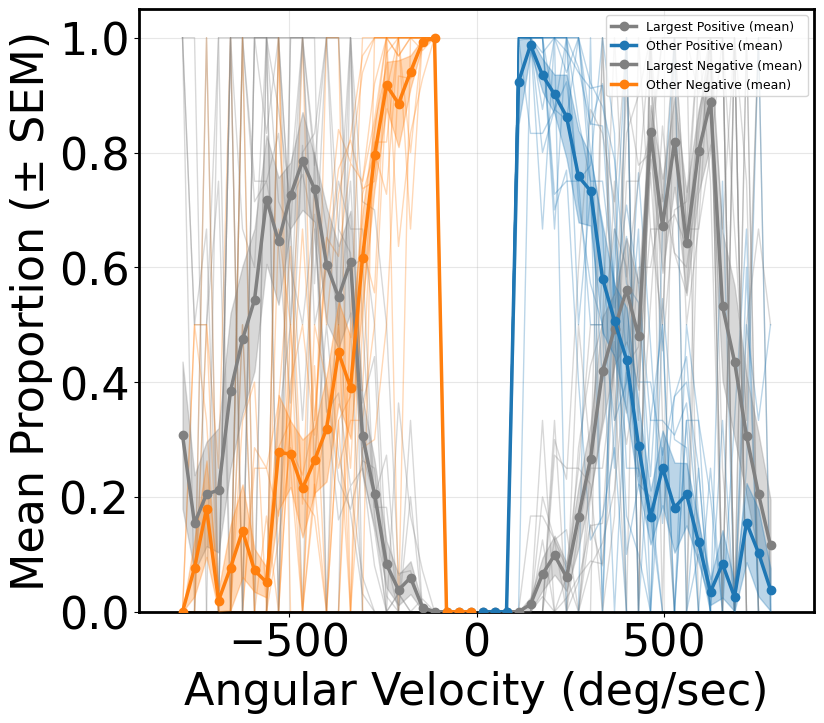


=== Summary Statistics ===
Number of animals: 13
Total trials: 1379
Average trials per animal: 106.08
Total positive movements: 2287
Total negative movements: 2207
Total movements: 4494

Overall mean proportions:
  Largest positive turns: 0.355
  Other positive turns: 0.371
  Largest negative turns: 0.334
  Other negative turns: 0.358

Total proportion:
  Largest turns: 0.345
  Other turns: 0.365


In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]  

# Get data for oadark condition
light = data[data.task == 'oadark']

# Get unique animals
animals = light['animal'].unique()
print(f"Processing {len(animals)} animals")

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Lists to store proportions for each animal
animal_proportions_pos = []
animal_proportions_neg = []

# Process each animal separately
for animal in animals:
    animal_data = light[light['animal'] == animal]
    
    # Get full dataset for this animal
    full_pos = flatten_list_of_arrays(animal_data.positive_heights.to_list()) * 60
    full_neg = flatten_list_of_arrays(animal_data.negative_heights.to_list()) * 60
    
    # Get largest movements subset for this animal
    all_largest = animal_data.head_turn_velocity.to_numpy() * 60
    largest_pos = all_largest[all_largest > 0]
    largest_neg = all_largest[all_largest < 0]
    
    # Compute histograms for this animal
    counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos, range=(0,800))
    counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos, range=(0,800))
    counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements
    
    counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg, range=(-800,0))
    counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg, range=(-800,0))
    counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements
    
    # Calculate proportions for this animal
    # For positive bins
    prop_largest_pos = np.zeros_like(counts_largest_pos, dtype=float)
    prop_rest_pos = np.zeros_like(counts_rest_pos, dtype=float)
    
    for i in range(len(counts_full_pos)):
        if counts_full_pos[i] > 0:
            prop_largest_pos[i] = counts_largest_pos[i] / counts_full_pos[i]
            prop_rest_pos[i] = counts_rest_pos[i] / counts_full_pos[i]
    
    # For negative bins
    prop_largest_neg = np.zeros_like(counts_largest_neg, dtype=float)
    prop_rest_neg = np.zeros_like(counts_rest_neg, dtype=float)
    
    for i in range(len(counts_full_neg)):
        if counts_full_neg[i] > 0:
            prop_largest_neg[i] = counts_largest_neg[i] / counts_full_neg[i]
            prop_rest_neg[i] = counts_rest_neg[i] / counts_full_neg[i]
    
    # Store proportions for this animal
    animal_proportions_pos.append({
        'animal': animal,
        'prop_largest': prop_largest_pos,
        'prop_rest': prop_rest_pos,
        'total_movements': counts_full_pos,
        'n_trials': len(animal_data)
    })
    
    animal_proportions_neg.append({
        'animal': animal,
        'prop_largest': prop_largest_neg,
        'prop_rest': prop_rest_neg,
        'total_movements': counts_full_neg,
        'n_trials': len(animal_data)
    })

# Calculate mean proportions across animals
mean_prop_largest_pos = np.mean([a['prop_largest'] for a in animal_proportions_pos], axis=0)
mean_prop_rest_pos = np.mean([a['prop_rest'] for a in animal_proportions_pos], axis=0)

mean_prop_largest_neg = np.mean([a['prop_largest'] for a in animal_proportions_neg], axis=0)
mean_prop_rest_neg = np.mean([a['prop_rest'] for a in animal_proportions_neg], axis=0)

# Also calculate SEM for error bars
sem_prop_largest_pos = np.std([a['prop_largest'] for a in animal_proportions_pos], axis=0) / np.sqrt(len(animals))
sem_prop_rest_pos = np.std([a['prop_rest'] for a in animal_proportions_pos], axis=0) / np.sqrt(len(animals))
sem_prop_largest_neg = np.std([a['prop_largest'] for a in animal_proportions_neg], axis=0) / np.sqrt(len(animals))
sem_prop_rest_neg = np.std([a['prop_rest'] for a in animal_proportions_neg], axis=0) / np.sqrt(len(animals))

# Create figure with specified size
fig, ax = plt.subplots(figsize=(9, 8))

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot individual animal lines with alpha 0.3
for a_pos, a_neg in zip(animal_proportions_pos, animal_proportions_neg):
    # Plot largest positive turns
    ax.plot(bin_centers_pos, a_pos['prop_largest'], '-', color='grey', 
            alpha=0.3, linewidth=1)
    
    # Plot other positive turns
    ax.plot(bin_centers_pos, a_pos['prop_rest'], '-', color='tab:blue', 
            alpha=0.3, linewidth=1)
    
    # Plot largest negative turns
    ax.plot(bin_centers_neg, a_neg['prop_largest'], '-', color='grey', 
            alpha=0.3, linewidth=1)
    
    # Plot other negative turns
    ax.plot(bin_centers_neg, a_neg['prop_rest'], '-', color='tab:orange', 
            alpha=0.3, linewidth=1)

# Plot mean lines with SEM on top of individual lines
# Largest positive turns
ax.plot(bin_centers_pos, mean_prop_largest_pos, 'o-', color='grey', linewidth=2.5, 
        markersize=6, label='Largest Positive (mean)', zorder=10)
ax.fill_between(bin_centers_pos, 
                mean_prop_largest_pos - sem_prop_largest_pos, 
                mean_prop_largest_pos + sem_prop_largest_pos, 
                color='grey', alpha=0.3, zorder=5)

# Other positive turns
ax.plot(bin_centers_pos, mean_prop_rest_pos, 'o-', color='tab:blue', linewidth=2.5, 
        markersize=6, label='Other Positive (mean)', zorder=10)
ax.fill_between(bin_centers_pos, 
                mean_prop_rest_pos - sem_prop_rest_pos, 
                mean_prop_rest_pos + sem_prop_rest_pos, 
                color='tab:blue', alpha=0.3, zorder=5)

# Largest negative turns
ax.plot(bin_centers_neg, mean_prop_largest_neg, 'o-', color='grey', linewidth=2.5, 
        markersize=6, label='Largest Negative (mean)', zorder=10)
ax.fill_between(bin_centers_neg, 
                mean_prop_largest_neg - sem_prop_largest_neg, 
                mean_prop_largest_neg + sem_prop_largest_neg, 
                color='grey', alpha=0.3, zorder=5)

# Other negative turns
ax.plot(bin_centers_neg, mean_prop_rest_neg, 'o-', color='tab:orange', linewidth=2.5, 
        markersize=6, label='Other Negative (mean)', zorder=10)
ax.fill_between(bin_centers_neg, 
                mean_prop_rest_neg - sem_prop_rest_neg, 
                mean_prop_rest_neg + sem_prop_rest_neg, 
                color='tab:orange', alpha=0.3, zorder=5)

ax.set_xticks([-500, 0, 500])
ax.set_xlabel('Angular Velocity (deg/sec)')
ax.set_ylabel('Mean Proportion (± SEM)')
ax.set_xlim(-900, 900)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
total_trials = light.shape[0]
avg_trials_per_animal = np.mean([a['n_trials'] for a in animal_proportions_pos])
total_movements_pos = np.sum([np.sum(a['total_movements']) for a in animal_proportions_pos])
total_movements_neg = np.sum([np.sum(a['total_movements']) for a in animal_proportions_neg])

print(f"\n=== Summary Statistics ===")
print(f"Number of animals: {len(animals)}")
print(f"Total trials: {total_trials}")
print(f"Average trials per animal: {avg_trials_per_animal:.2f}")
print(f"Total positive movements: {total_movements_pos}")
print(f"Total negative movements: {total_movements_neg}")
print(f"Total movements: {total_movements_pos + total_movements_neg}")

# Calculate overall proportions
overall_prop_largest_pos = np.mean(mean_prop_largest_pos)
overall_prop_rest_pos = np.mean(mean_prop_rest_pos)
overall_prop_largest_neg = np.mean(mean_prop_largest_neg)
overall_prop_rest_neg = np.mean(mean_prop_rest_neg)

print(f"\nOverall mean proportions:")
print(f"  Largest positive turns: {overall_prop_largest_pos:.3f}")
print(f"  Other positive turns: {overall_prop_rest_pos:.3f}")
print(f"  Largest negative turns: {overall_prop_largest_neg:.3f}")
print(f"  Other negative turns: {overall_prop_rest_neg:.3f}")

# Calculate proportion of largest vs other movements
total_prop_largest = (overall_prop_largest_pos + overall_prop_largest_neg) / 2
total_prop_other = (overall_prop_rest_pos + overall_prop_rest_neg) / 2
print(f"\nTotal proportion:")
print(f"  Largest turns: {total_prop_largest:.3f}")
print(f"  Other turns: {total_prop_other:.3f}")

In [58]:
mean_prop_largest_pos

array([0.        , 0.        , 0.        , 0.        , 0.01282051,
       0.06548583, 0.09854312, 0.06038193, 0.16475454, 0.26670913,
       0.41952663, 0.49311609, 0.56066263, 0.47973193, 0.83574661,
       0.67248136, 0.81863905, 0.64150294, 0.8018315 , 0.88846154,
       0.53205128, 0.43589744, 0.30641026, 0.20512821, 0.11538462])

Processing 13 animals


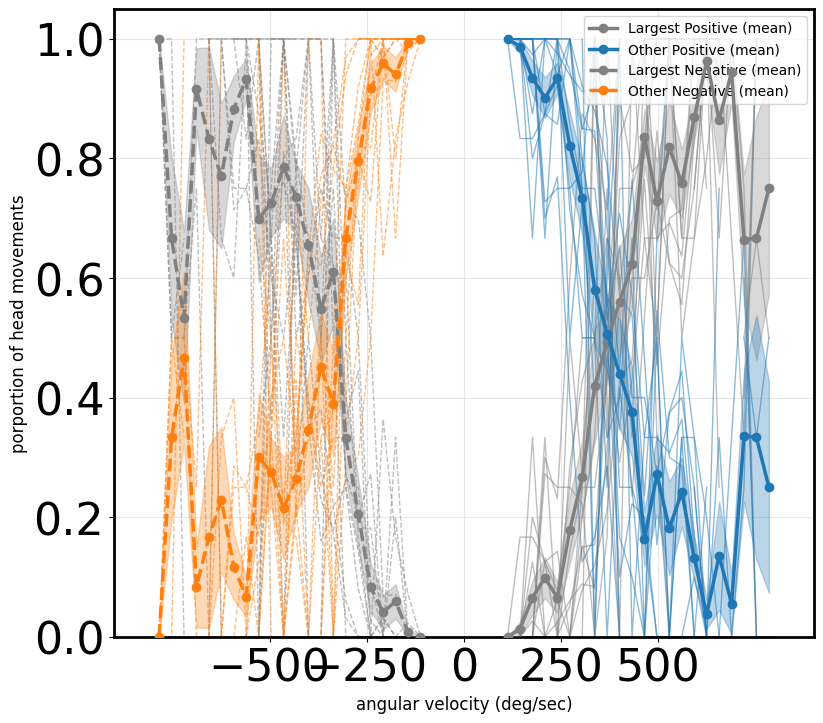


=== Summary Statistics ===
Number of animals: 13
Total trials: 1379
Average trials per animal: 106.08
Total positive movements: 2,287
Total negative movements: 2,207
Total movements: 4,494


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]  

# Get data for oadark condition
light = data[data.task == 'oadark']

# Get unique animals
animals = light['animal'].unique()
print(f"Processing {len(animals)} animals")

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Lists to store proportions for each animal
animal_proportions_pos = []
animal_proportions_neg = []

# Process each animal separately
for animal in animals:
    animal_data = light[light['animal'] == animal]
    
    # Get full dataset for this animal
    full_pos = flatten_list_of_arrays(animal_data.positive_heights.to_list()) * 60
    full_neg = flatten_list_of_arrays(animal_data.negative_heights.to_list()) * 60
    
    # Get largest movements subset for this animal
    all_largest = animal_data.head_turn_velocity.to_numpy() * 60
    largest_pos = all_largest[all_largest > 0]
    largest_neg = all_largest[all_largest < 0]
    
    # Compute histograms for this animal
    counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos, range=(0,800))
    counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos, range=(0,800))
    counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements
    
    counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg, range=(-800,0))
    counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg, range=(-800,0))
    counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements
    
    # Calculate proportions for this animal
    # For positive bins
    prop_largest_pos = np.zeros_like(counts_largest_pos, dtype=float)
    prop_rest_pos = np.zeros_like(counts_rest_pos, dtype=float)
    
    for i in range(len(counts_full_pos)):
        if counts_full_pos[i] > 0:
            prop_largest_pos[i] = counts_largest_pos[i] / counts_full_pos[i]
            prop_rest_pos[i] = counts_rest_pos[i] / counts_full_pos[i]
        else:
            prop_largest_pos[i] = np.nan
            prop_rest_pos[i] = np.nan
    
    # For negative bins
    prop_largest_neg = np.zeros_like(counts_largest_neg, dtype=float)
    prop_rest_neg = np.zeros_like(counts_rest_neg, dtype=float)
    
    for i in range(len(counts_full_neg)):
        if counts_full_neg[i] > 0:
            prop_largest_neg[i] = counts_largest_neg[i] / counts_full_neg[i]
            prop_rest_neg[i] = counts_rest_neg[i] / counts_full_neg[i]
        else:
            prop_largest_neg[i] = np.nan
            prop_rest_neg[i] = np.nan
    
    # Store proportions for this animal
    animal_proportions_pos.append({
        'animal': animal,
        'prop_largest': prop_largest_pos,
        'prop_rest': prop_rest_pos,
        'total_movements': counts_full_pos,
        'n_trials': len(animal_data)
    })
    
    animal_proportions_neg.append({
        'animal': animal,
        'prop_largest': prop_largest_neg,
        'prop_rest': prop_rest_neg,
        'total_movements': counts_full_neg,
        'n_trials': len(animal_data)
    })

# Calculate mean proportions across animals (ignoring NaN values)
valid_props_largest_pos = []
valid_props_rest_pos = []
valid_props_largest_neg = []
valid_props_rest_neg = []

for i in range(len(bins_pos) - 1):
    # Collect valid values for this bin across all animals
    bin_largest_pos = []
    bin_rest_pos = []
    bin_largest_neg = []
    bin_rest_neg = []
    
    for a_pos, a_neg in zip(animal_proportions_pos, animal_proportions_neg):
        if not np.isnan(a_pos['prop_largest'][i]):
            bin_largest_pos.append(a_pos['prop_largest'][i])
            bin_rest_pos.append(a_pos['prop_rest'][i])
        if not np.isnan(a_neg['prop_largest'][i]):
            bin_largest_neg.append(a_neg['prop_largest'][i])
            bin_rest_neg.append(a_neg['prop_rest'][i])
    
    valid_props_largest_pos.append(bin_largest_pos)
    valid_props_rest_pos.append(bin_rest_pos)
    valid_props_largest_neg.append(bin_largest_neg)
    valid_props_rest_neg.append(bin_rest_neg)

# Calculate mean and SEM
mean_prop_largest_pos = np.array([np.mean(bin_vals) if len(bin_vals) > 0 else np.nan for bin_vals in valid_props_largest_pos])
mean_prop_rest_pos = np.array([np.mean(bin_vals) if len(bin_vals) > 0 else np.nan for bin_vals in valid_props_rest_pos])
mean_prop_largest_neg = np.array([np.mean(bin_vals) if len(bin_vals) > 0 else np.nan for bin_vals in valid_props_largest_neg])
mean_prop_rest_neg = np.array([np.mean(bin_vals) if len(bin_vals) > 0 else np.nan for bin_vals in valid_props_rest_neg])

sem_prop_largest_pos = np.array([np.std(bin_vals)/np.sqrt(len(bin_vals)) if len(bin_vals) > 0 else np.nan for bin_vals in valid_props_largest_pos])
sem_prop_rest_pos = np.array([np.std(bin_vals)/np.sqrt(len(bin_vals)) if len(bin_vals) > 0 else np.nan for bin_vals in valid_props_rest_pos])
sem_prop_largest_neg = np.array([np.std(bin_vals)/np.sqrt(len(bin_vals)) if len(bin_vals) > 0 else np.nan for bin_vals in valid_props_largest_neg])
sem_prop_rest_neg = np.array([np.std(bin_vals)/np.sqrt(len(bin_vals)) if len(bin_vals) > 0 else np.nan for bin_vals in valid_props_rest_neg])

# Create figure with specified size
fig, ax = plt.subplots(figsize=(9, 8))

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot individual animal lines with alpha 0.5
for a_pos, a_neg in zip(animal_proportions_pos, animal_proportions_neg):
    # Plot largest positive turns
    ax.plot(bin_centers_pos, a_pos['prop_largest'], '-', color='grey', 
            alpha=0.5, linewidth=1)
    
    # Plot other positive turns
    ax.plot(bin_centers_pos, a_pos['prop_rest'], '-', color='tab:blue', 
            alpha=0.5, linewidth=1)
    
    # Plot largest negative turns
    ax.plot(bin_centers_neg, a_neg['prop_largest'], '-', color='grey', 
            alpha=0.5, linewidth=1, linestyle='--')
    
    # Plot other negative turns
    ax.plot(bin_centers_neg, a_neg['prop_rest'], '-', color='tab:orange', 
            alpha=0.5, linewidth=1, linestyle='--')

# Plot mean lines with SEM
# Largest positive turns
ax.plot(bin_centers_pos, mean_prop_largest_pos, 'o-', color='grey', linewidth=2.5, 
        markersize=6, label='Largest Positive (mean)', zorder=10)
ax.fill_between(bin_centers_pos, 
                mean_prop_largest_pos - sem_prop_largest_pos, 
                mean_prop_largest_pos + sem_prop_largest_pos, 
                color='grey', alpha=0.3, zorder=5)

# Other positive turns
ax.plot(bin_centers_pos, mean_prop_rest_pos, 'o-', color='tab:blue', linewidth=2.5, 
        markersize=6, label='Other Positive (mean)', zorder=10)
ax.fill_between(bin_centers_pos, 
                mean_prop_rest_pos - sem_prop_rest_pos, 
                mean_prop_rest_pos + sem_prop_rest_pos, 
                color='tab:blue', alpha=0.3, zorder=5)

# Largest negative turns
ax.plot(bin_centers_neg, mean_prop_largest_neg, 'o--', color='grey', linewidth=2.5, 
        markersize=6, label='Largest Negative (mean)', zorder=10)
ax.fill_between(bin_centers_neg, 
                mean_prop_largest_neg - sem_prop_largest_neg, 
                mean_prop_largest_neg + sem_prop_largest_neg, 
                color='grey', alpha=0.3, zorder=5)

# Other negative turns
ax.plot(bin_centers_neg, mean_prop_rest_neg, 'o--', color='tab:orange', linewidth=2.5, 
        markersize=6, label='Other Negative (mean)', zorder=10)
ax.fill_between(bin_centers_neg, 
                mean_prop_rest_neg - sem_prop_rest_neg, 
                mean_prop_rest_neg + sem_prop_rest_neg, 
                color='tab:orange', alpha=0.3, zorder=5)

# Configure axis
ax.set_xticks([-500, -250, 0, 250, 500])
ax.set_xlabel('angular velocity (deg/sec)', fontsize=12)
ax.set_ylabel('porportion of head movements', fontsize=12)
ax.set_xlim(-900, 900)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
total_trials = light.shape[0]
avg_trials_per_animal = np.mean([a['n_trials'] for a in animal_proportions_pos])
total_movements_pos = np.sum([np.sum(a['total_movements']) for a in animal_proportions_pos])
total_movements_neg = np.sum([np.sum(a['total_movements']) for a in animal_proportions_neg])

print(f"\n=== Summary Statistics ===")
print(f"Number of animals: {len(animals)}")
print(f"Total trials: {total_trials}")
print(f"Average trials per animal: {avg_trials_per_animal:.2f}")
print(f"Total positive movements: {total_movements_pos:,}")
print(f"Total negative movements: {total_movements_neg:,}")
print(f"Total movements: {total_movements_pos + total_movements_neg:,}")

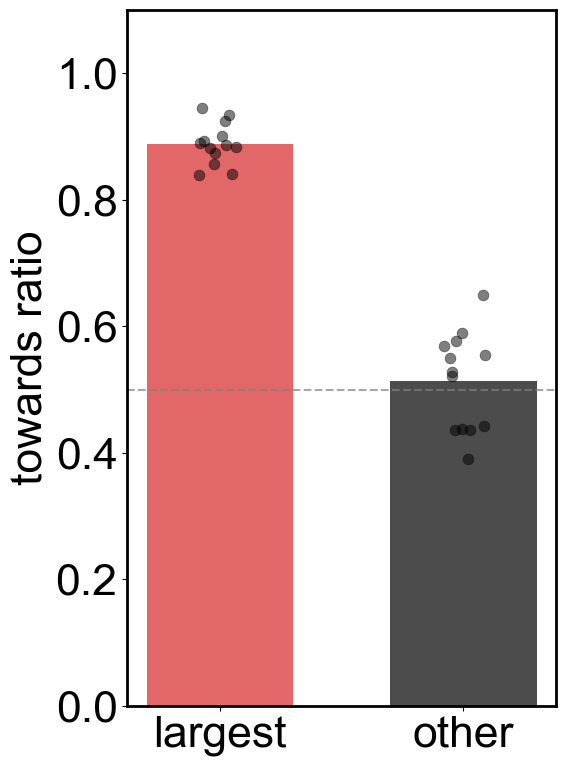

Population average (based on animal means):
  Largest turns towards ratio: 0.889
  Other turns towards ratio: 0.514

Number of animals: 13
Total trials: 1830


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter and process data as before
data = pd.concat([light_dark]) 
#data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store results
results = []

# Process each row to calculate towards ratios
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data
    if task != 'oadark':
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60  # Convert as in your code
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Calculate towards ratio for largest turn (negative values)
    largest_towards = 1 if largest_turn < 0 else 0
    
    # Calculate towards ratio for other turns
    if len(other_turns) > 0:
        other_towards = np.sum(np.array(other_turns) < 0) / len(other_turns)
    else:
        other_towards = 0
    
    results.append({
        'animal': animal,
        'task': task,
        'largest_towards': largest_towards,
        'other_towards': other_towards
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Check if we have OA data
if len(results_df) > 0:
    # Calculate individual animal averages for OA
    animal_ratios = results_df.groupby(['animal', 'task']).agg({
        'largest_towards': 'mean',
        'other_towards': 'mean'
    }).reset_index()
    
    # Calculate population averages based on animal averages
    # This gives each animal equal weight in the population statistics
    population_largest_mean = animal_ratios['largest_towards'].mean()
    population_other_mean = animal_ratios['other_towards'].mean()
    
    # Create arrays for population statistics
    population_ratios = {
        'largest_towards': population_largest_mean,
        'other_towards': population_other_mean
    }
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # Bar width and positions
    bar_width = 0.6
    x_positions = [0, 1]
    
    # Plot bars using population averages
    bars1 = ax.bar(0, population_largest_mean, 
                   bar_width, color='tab:red', alpha=0.7)
    bars2 = ax.bar(1, population_other_mean, 
                   bar_width, color='black', alpha=0.7)
    
    # Add horizontal dotted line at 0.5
    ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Add individual animal scatter points
    task_data = animal_ratios[animal_ratios['task'] == 'oadark']
    
    if len(task_data) > 0:
        # Reduced jitter for less spread
        jitter1 = np.random.uniform(-0.09, 0.09, size=len(task_data))
        jitter2 = np.random.uniform(-0.09, 0.09, size=len(task_data))
        
        # Plot individual animal points for largest turns
        ax.scatter([0] * len(task_data) + jitter1, 
                   task_data['largest_towards'], 
                   color='black', alpha=0.5, 
                   linewidth=0.5, s=60)
        
        # Plot individual animal points for other turns
        ax.scatter([1] * len(task_data) + jitter2, 
                   task_data['other_towards'], 
                   color='black', alpha=0.5,  
                   linewidth=0.5, s=60)
    
    # Customize the plot
    ax.set_ylabel('towards ratio')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['largest', 'other'])
    ax.set_ylim(0, 1.1)
    
   
    plt.tight_layout()
    plt.show()
    
    # Print population statistics
    print(f"Population average (based on animal means):")
    print(f"  Largest turns towards ratio: {population_largest_mean:.3f}")
    print(f"  Other turns towards ratio: {population_other_mean:.3f}")
    print(f"\nNumber of animals: {len(task_data)}")
    print(f"Total trials: {len(results_df)}")
    
else:
    print("No OA data found after filtering")

In [7]:
import pandas as pd
import numpy as np

# Filter and process data as before
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store movement counts
movement_counts = []

# Process each row to count movements
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data (oadark or oa)
    if task not in ['oadark', 'oa']:
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Count movements
    # Largest turn is always one movement
    num_largest = 1
    
    # Count other turns (only include if they exist)
    num_other = len(other_turns) if len(other_turns) > 0 else 0
    
    movement_counts.append({
        'animal': animal,
        'task': task,
        'num_largest': num_largest,
        'num_other': num_other
    })

# Convert to DataFrame
movement_counts_df = pd.DataFrame(movement_counts)

# Check if we have OA data
if len(movement_counts_df) > 0:
    # Calculate mean number of movements per animal per condition
    mean_movements_per_animal = movement_counts_df.groupby(['animal', 'task']).agg({
        'num_largest': 'mean',
        'num_other': 'mean'
    }).reset_index()
    
    print("Mean number of movements per animal per condition:")
    print("=" * 60)
    
    # Calculate and display for each condition separately
    for condition in ['oadark', 'oa']:
        condition_data = mean_movements_per_animal[mean_movements_per_animal['task'] == condition]
        
        if len(condition_data) > 0:
            print(f"\nCondition: {condition}")
            print("-" * 40)
            
            # Display individual animal means
            print("Individual animal means:")
            for _, row in condition_data.iterrows():
                print(f"  {row['animal']}: Largest={row['num_largest']:.2f}, Other={row['num_other']:.2f}")
            
            # Calculate population averages
            pop_largest_mean = condition_data['num_largest'].mean()
            pop_other_mean = condition_data['num_other'].mean()
            
            print(f"\nPopulation average (based on animal means):")
            print(f"  Largest movements: {pop_largest_mean:.3f}")
            print(f"  Other movements: {pop_other_mean:.3f}")
            print(f"  Total movements per trial: {pop_largest_mean + pop_other_mean:.3f}")
            print(f"  Number of animals: {len(condition_data)}")
    
    # Calculate overall statistics (combining both conditions)
    print("\n" + "=" * 60)
    print("Overall statistics (all OA conditions combined):")
    print("-" * 40)
    
    # Group by animal only for overall stats
    overall_animal_stats = movement_counts_df.groupby(['animal']).agg({
        'num_largest': 'mean',
        'num_other': 'mean',
        'task': 'count'  # Count of trials
    }).rename(columns={'task': 'num_trials'}).reset_index()
    
    # Calculate population averages
    overall_largest_mean = overall_animal_stats['num_largest'].mean()
    overall_other_mean = overall_animal_stats['num_other'].mean()
    total_trials = movement_counts_df.shape[0]
    
    print(f"Population average (based on animal means):")
    print(f"  Largest movements per trial: {overall_largest_mean:.3f}")
    print(f"  Other movements per trial: {overall_other_mean:.3f}")
    print(f"  Total movements per trial: {overall_largest_mean + overall_other_mean:.3f}")
    print(f"  Number of animals: {len(overall_animal_stats)}")
    print(f"  Total trials: {total_trials}")
    
    # Additional statistics
    print("\nAdditional statistics:")
    print(f"  Average largest movements per animal: {overall_animal_stats['num_largest'].mean():.2f} ± {overall_animal_stats['num_largest'].std():.2f}")
    print(f"  Average other movements per animal: {overall_animal_stats['num_other'].mean():.2f} ± {overall_animal_stats['num_other'].std():.2f}")
    
    # Return the data for further analysis
    print("\nData available in variables:")
    print("  'movement_counts_df' - Raw movement counts per trial")
    print("  'mean_movements_per_animal' - Mean movements per animal per condition")
    print("  'overall_animal_stats' - Overall means per animal")
    
else:
    print("No OA data found after filtering")

Mean number of movements per animal per condition:

Condition: oadark
----------------------------------------
Individual animal means:
  G8CK1LN: Largest=1.00, Other=1.40
  G8CK1LT: Largest=1.00, Other=2.10
  G8CK1RT: Largest=1.00, Other=1.41
  G8CK1TT: Largest=1.00, Other=1.89
  G8CKLN: Largest=1.00, Other=2.05
  G8CKLT: Largest=1.00, Other=1.71
  G8CKRN: Largest=1.00, Other=1.93
  G8CKRT: Largest=1.00, Other=1.33
  G8CKTT: Largest=1.00, Other=1.89
  J701LT: Largest=1.00, Other=3.21
  J701NN: Largest=1.00, Other=2.41
  J701RN: Largest=1.00, Other=3.58
  J701RT: Largest=1.00, Other=3.66

Population average (based on animal means):
  Largest movements: 1.000
  Other movements: 2.198
  Total movements per trial: 3.198
  Number of animals: 13

Condition: oa
----------------------------------------
Individual animal means:
  G8CK1LN: Largest=1.00, Other=1.78
  G8CK1LT: Largest=1.00, Other=2.50
  G8CK1RT: Largest=1.00, Other=1.68
  G8CK1TT: Largest=1.00, Other=1.72
  G8CKLN: Largest=1.00, 

In [9]:
import pandas as pd
import numpy as np

# Filter and process data as before
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store movement counts
movement_counts = []

# Process each row to count movements
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data (oadark or oa)
    if task not in ['oadark', 'oa']:
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Count movements
    # Largest turn is always one movement
    num_largest = 1
    
    # Count other turns (only include if they exist)
    num_other = len(other_turns) if len(other_turns) > 0 else 0
    
    movement_counts.append({
        'animal': animal,
        'task': task,
        'num_largest': num_largest,
        'num_other': num_other,
        'total_movements': num_largest + num_other
    })

# Convert to DataFrame
movement_counts_df = pd.DataFrame(movement_counts)

# Check if we have OA data
if len(movement_counts_df) > 0:
    print("TOTAL MOVEMENT COUNTS ANALYSIS")
    print("=" * 70)
    
    # 1. Calculate total counts across all trials
    total_largest_all = movement_counts_df['num_largest'].sum()
    total_other_all = movement_counts_df['num_other'].sum()
    total_all = total_largest_all + total_other_all
    
    print("1. TOTAL MOVEMENTS ACROSS ALL TRIALS:")
    print("-" * 40)
    print(f"   Largest movements: {total_largest_all:,}")
    print(f"   Other movements: {total_other_all:,}")
    print(f"   Total movements: {total_all:,}")
    print(f"   Proportion largest: {total_largest_all/total_all:.3f}")
    print(f"   Proportion other: {total_other_all/total_all:.3f}")
    
    # 2. Calculate total counts by condition
    print(f"\n2. TOTAL MOVEMENTS BY CONDITION:")
    print("-" * 40)
    
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        if len(condition_data) > 0:
            total_largest_cond = condition_data['num_largest'].sum()
            total_other_cond = condition_data['num_other'].sum()
            total_cond = total_largest_cond + total_other_cond
            
            print(f"\n   Condition: {condition}")
            print(f"   Largest movements: {total_largest_cond:,}")
            print(f"   Other movements: {total_other_cond:,}")
            print(f"   Total movements: {total_cond:,}")
            print(f"   Proportion largest: {total_largest_cond/total_cond:.3f}")
            print(f"   Proportion other: {total_other_cond/total_cond:.3f}")
            print(f"   Number of trials: {len(condition_data):,}")
    
    # 3. Calculate BETWEEN-ANIMAL AVERAGES (mean per animal)
    print(f"\n3. BETWEEN-ANIMAL AVERAGES (mean per animal):")
    print("-" * 40)
    
    # Calculate total counts per animal
    animal_totals = movement_counts_df.groupby('animal').agg({
        'num_largest': 'sum',
        'num_other': 'sum',
        'total_movements': 'sum',
        'task': 'count'  # Number of trials
    }).rename(columns={'task': 'num_trials'}).reset_index()
    
    # Calculate averages per animal
    animal_totals['largest_per_trial'] = animal_totals['num_largest'] / animal_totals['num_trials']
    animal_totals['other_per_trial'] = animal_totals['num_other'] / animal_totals['num_trials']
    animal_totals['total_per_trial'] = animal_totals['total_movements'] / animal_totals['num_trials']
    
    print(f"\n   Individual animal totals:")
    for _, row in animal_totals.iterrows():
        print(f"   {row['animal']}: Largest={row['num_largest']:,}, "
              f"Other={row['num_other']:,}, Total={row['total_movements']:,}, "
              f"Trials={row['num_trials']}")
    
    # Calculate between-animal means (averaging across animals)
    between_animal_stats = {
        'mean_largest_per_animal': animal_totals['num_largest'].mean(),
        'std_largest_per_animal': animal_totals['num_largest'].std(),
        'mean_other_per_animal': animal_totals['num_other'].mean(),
        'std_other_per_animal': animal_totals['num_other'].std(),
        'mean_total_per_animal': animal_totals['total_movements'].mean(),
        'std_total_per_animal': animal_totals['total_movements'].std(),
        'mean_largest_per_trial': animal_totals['largest_per_trial'].mean(),
        'std_largest_per_trial': animal_totals['largest_per_trial'].std(),
        'mean_other_per_trial': animal_totals['other_per_trial'].mean(),
        'std_other_per_trial': animal_totals['other_per_trial'].std(),
        'mean_total_per_trial': animal_totals['total_per_trial'].mean(),
        'std_total_per_trial': animal_totals['total_per_trial'].std()
    }
    
    print(f"\n   Between-animal statistics (averaging across {len(animal_totals)} animals):")
    print(f"   Largest movements per animal: {between_animal_stats['mean_largest_per_animal']:.1f} ± {between_animal_stats['std_largest_per_animal']:.1f}")
    print(f"   Other movements per animal: {between_animal_stats['mean_other_per_animal']:.1f} ± {between_animal_stats['std_other_per_animal']:.1f}")
    print(f"   Total movements per animal: {between_animal_stats['mean_total_per_animal']:.1f} ± {between_animal_stats['std_total_per_animal']:.1f}")
    
    print(f"\n   Per trial averages (between-animal means):")
    print(f"   Largest movements per trial: {between_animal_stats['mean_largest_per_trial']:.3f} ± {between_animal_stats['std_largest_per_trial']:.3f}")
    print(f"   Other movements per trial: {between_animal_stats['mean_other_per_trial']:.3f} ± {between_animal_stats['std_other_per_trial']:.3f}")
    print(f"   Total movements per trial: {between_animal_stats['mean_total_per_trial']:.3f} ± {between_animal_stats['std_total_per_trial']:.3f}")
    
    # 4. Calculate between-animal averages by condition
    print(f"\n4. BETWEEN-ANIMAL AVERAGES BY CONDITION:")
    print("-" * 40)
    
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        if len(condition_data) > 0:
            # Calculate totals per animal for this condition
            animal_condition_totals = condition_data.groupby('animal').agg({
                'num_largest': 'sum',
                'num_other': 'sum',
                'total_movements': 'sum',
                'task': 'count'
            }).rename(columns={'task': 'num_trials'}).reset_index()
            
            # Calculate per trial averages per animal
            animal_condition_totals['largest_per_trial'] = animal_condition_totals['num_largest'] / animal_condition_totals['num_trials']
            animal_condition_totals['other_per_trial'] = animal_condition_totals['num_other'] / animal_condition_totals['num_trials']
            animal_condition_totals['total_per_trial'] = animal_condition_totals['total_movements'] / animal_condition_totals['num_trials']
            
            # Calculate between-animal means for this condition
            mean_largest = animal_condition_totals['largest_per_trial'].mean()
            std_largest = animal_condition_totals['largest_per_trial'].std()
            mean_other = animal_condition_totals['other_per_trial'].mean()
            std_other = animal_condition_totals['other_per_trial'].std()
            mean_total = animal_condition_totals['total_per_trial'].mean()
            std_total = animal_condition_totals['total_per_trial'].std()
            
            print(f"\n   Condition: {condition}")
            print(f"   Number of animals: {len(animal_condition_totals)}")
            print(f"   Total trials: {len(condition_data)}")
            print(f"   Largest movements per trial (mean ± SD): {mean_largest:.3f} ± {std_largest:.3f}")
            print(f"   Other movements per trial (mean ± SD): {mean_other:.3f} ± {std_other:.3f}")
            print(f"   Total movements per trial (mean ± SD): {mean_total:.3f} ± {std_total:.3f}")
            print(f"   Proportion largest: {mean_largest/mean_total:.3f}")
            print(f"   Proportion other: {mean_other/mean_total:.3f}")
    
    # 5. Summary statistics
    print(f"\n5. SUMMARY STATISTICS:")
    print("-" * 40)
    print(f"   Total animals: {len(animal_totals)}")
    print(f"   Total trials: {len(movement_counts_df):,}")
    print(f"   Average trials per animal: {len(movement_counts_df)/len(animal_totals):.1f}")
    print(f"   Range of trials per animal: {animal_totals['num_trials'].min()} - {animal_totals['num_trials'].max()}")
    
    # Save the data for further analysis
    print(f"\nData variables available:")
    print(f"   'movement_counts_df' - Raw movement counts per trial")
    print(f"   'animal_totals' - Total counts and per trial averages per animal")
    print(f"   'between_animal_stats' - Dictionary with between-animal statistics")
    
else:
    print("No OA data found after filtering")
    

TOTAL MOVEMENT COUNTS ANALYSIS
1. TOTAL MOVEMENTS ACROSS ALL TRIALS:
----------------------------------------
   Largest movements: 3,584
   Other movements: 8,641
   Total movements: 12,225
   Proportion largest: 0.293
   Proportion other: 0.707

2. TOTAL MOVEMENTS BY CONDITION:
----------------------------------------

   Condition: oadark
   Largest movements: 1,379
   Other movements: 3,506
   Total movements: 4,885
   Proportion largest: 0.282
   Proportion other: 0.718
   Number of trials: 1,379

   Condition: oa
   Largest movements: 2,205
   Other movements: 5,135
   Total movements: 7,340
   Proportion largest: 0.300
   Proportion other: 0.700
   Number of trials: 2,205

3. BETWEEN-ANIMAL AVERAGES (mean per animal):
----------------------------------------

   Individual animal totals:
   G8CK1LN: Largest=221, Other=361, Total=582, Trials=221
   G8CK1LT: Largest=225, Other=531, Total=756, Trials=225
   G8CK1RT: Largest=255, Other=400, Total=655, Trials=255
   G8CK1TT: Largest=

In [9]:
import pandas as pd
import numpy as np

# Filter and process data as before
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store movement counts
movement_counts = []

# Process each row to count movements
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data (oadark or oa)
    if task not in ['oadark', 'oa']:
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Count movements
    # Largest turn is always one movement
    num_largest = 1
    
    # Count other turns (only include if they exist)
    num_other = len(other_turns) if len(other_turns) > 0 else 0
    
    movement_counts.append({
        'animal': animal,
        'task': task,
        'num_largest': num_largest,
        'num_other': num_other,
        'total_movements': num_largest + num_other
    })

# Convert to DataFrame
movement_counts_df = pd.DataFrame(movement_counts)

# Check if we have OA data
if len(movement_counts_df) > 0:
    print("BETWEEN-ANIMAL MEAN PROPORTION ANALYSIS")
    print("=" * 70)
    
    # Calculate proportions for each condition
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        
        if len(condition_data) > 0:
            print(f"\nCONDITION: {condition.upper()}")
            print("-" * 40)
            
            # Method 1: Calculate proportion for each animal, then average across animals
            print("METHOD 1: Between-animal mean proportion (preferred)")
            print("-" * 30)
            
            # Group by animal to get totals per animal
            animal_totals = condition_data.groupby('animal').agg({
                'num_largest': 'sum',
                'num_other': 'sum',
                'total_movements': 'sum',
                'task': 'count'
            }).rename(columns={'task': 'num_trials'}).reset_index()
            
            # Calculate proportion of largest movements for each animal
            animal_totals['prop_largest'] = animal_totals['num_largest'] / animal_totals['total_movements']
            animal_totals['prop_other'] = animal_totals['num_other'] / animal_totals['total_movements']
            
            # Calculate between-animal mean proportions
            mean_prop_largest = animal_totals['prop_largest'].mean()
            std_prop_largest = animal_totals['prop_largest'].std()
            mean_prop_other = animal_totals['prop_other'].mean()
            std_prop_other = animal_totals['prop_other'].std()
            
            print(f"Number of animals: {len(animal_totals)}")
            print(f"Number of trials: {len(condition_data)}")
            print(f"\nIndividual animal proportions:")
            for _, row in animal_totals.iterrows():
                print(f"  {row['animal']}: Largest = {row['prop_largest']:.3f}, "
                      f"Other = {row['prop_other']:.3f}, "
                      f"Trials = {row['num_trials']}")
            
            print(f"\nBetween-animal mean proportion ± SD:")
            print(f"  Largest movements: {mean_prop_largest:.3f} ± {std_prop_largest:.3f}")
            print(f"  Other movements: {mean_prop_other:.3f} ± {std_prop_other:.3f}")
            
            # Calculate 95% confidence intervals
            n_animals = len(animal_totals)
            se_largest = std_prop_largest / np.sqrt(n_animals)
            se_other = std_prop_other / np.sqrt(n_animals)
            ci_largest = 1.96 * se_largest  # 95% CI
            ci_other = 1.96 * se_other      # 95% CI
            
            print(f"\nBetween-animal proportion with 95% CI:")
            print(f"  Largest movements: {mean_prop_largest:.3f} ({mean_prop_largest - ci_largest:.3f} - {mean_prop_largest + ci_largest:.3f})")
            print(f"  Other movements: {mean_prop_other:.3f} ({mean_prop_other - ci_other:.3f} - {mean_prop_other + ci_other:.3f})")
            
            # Method 2: Pooled proportion (for comparison - NOT between-animal)
            print(f"\nMETHOD 2: Pooled proportion (for comparison only)")
            print("-" * 30)
            total_largest = condition_data['num_largest'].sum()
            total_other = condition_data['num_other'].sum()
            total_all = total_largest + total_other
            
            pooled_prop_largest = total_largest / total_all
            pooled_prop_other = total_other / total_all
            
            print(f"Total largest movements: {total_largest}")
            print(f"Total other movements: {total_other}")
            print(f"Total movements: {total_all}")
            print(f"Pooled proportion largest: {pooled_prop_largest:.3f}")
            print(f"Pooled proportion other: {pooled_prop_other:.3f}")
            
            # Store the between-animal results
            condition_data_summary = {
                'condition': condition,
                'n_animals': n_animals,
                'n_trials': len(condition_data),
                'between_animal_mean_largest': mean_prop_largest,
                'between_animal_std_largest': std_prop_largest,
                'between_animal_mean_other': mean_prop_other,
                'between_animal_std_other': std_prop_other,
                'pooled_prop_largest': pooled_prop_largest,
                'pooled_prop_other': pooled_prop_other
            }
            
            # Display comparison
            print(f"\nCOMPARISON:")
            print(f"  Between-animal vs pooled proportion largest: {mean_prop_largest:.3f} vs {pooled_prop_largest:.3f}")
            print(f"  Difference: {(mean_prop_largest - pooled_prop_largest):.3f}")
            print(f"  Between-animal vs pooled proportion other: {mean_prop_other:.3f} vs {pooled_prop_other:.3f}")
            print(f"  Difference: {(mean_prop_other - pooled_prop_other):.3f}")
            
            # Create visualization of animal proportions
            print(f"\nVISUALIZATION OF ANIMAL PROPORTIONS:")
            print("-" * 30)
            
            # Sort animals by proportion of largest movements
            sorted_animals = animal_totals.sort_values('prop_largest', ascending=False)
            
            for _, row in sorted_animals.iterrows():
                prop_largest = row['prop_largest']
                # Create a simple bar visualization
                bar_length = 40
                largest_bar = int(prop_largest * bar_length)
                other_bar = bar_length - largest_bar
                
                print(f"{row['animal']:10s} | {'█' * largest_bar}{'░' * other_bar} | {prop_largest:.3f}")
    
    # Summary table comparing conditions
    print(f"\n" + "=" * 70)
    print("SUMMARY COMPARISON BETWEEN CONDITIONS")
    print("=" * 70)
    
    summary_rows = []
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        
        if len(condition_data) > 0:
            # Calculate between-animal proportions
            animal_totals = condition_data.groupby('animal').agg({
                'num_largest': 'sum',
                'num_other': 'sum',
                'total_movements': 'sum'
            }).reset_index()
            
            animal_totals['prop_largest'] = animal_totals['num_largest'] / animal_totals['total_movements']
            animal_totals['prop_other'] = animal_totals['num_other'] / animal_totals['total_movements']
            
            mean_prop_largest = animal_totals['prop_largest'].mean()
            std_prop_largest = animal_totals['prop_largest'].std()
            
            summary_rows.append({
                'Condition': condition,
                'N Animals': len(animal_totals),
                'N Trials': len(condition_data),
                'Between-Animal Prop Largest (mean ± SD)': f"{mean_prop_largest:.3f} ± {std_prop_largest:.3f}",
                'Mean Trials per Animal': f"{len(condition_data)/len(animal_totals):.1f}"
            })
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary_rows)
    print("\n" + summary_df.to_string(index=False))
    
    # Statistical comparison between conditions (if both conditions exist)
    if len(movement_counts_df['task'].unique()) > 1:
        print(f"\n" + "-" * 70)
        print("STATISTICAL COMPARISON BETWEEN CONDITIONS")
        print("-" * 70)
        
        # Collect proportions for each condition
        condition_props = {}
        for condition in ['oadark', 'oa']:
            condition_data = movement_counts_df[movement_counts_df['task'] == condition]
            
            if len(condition_data) > 0:
                animal_totals = condition_data.groupby('animal').agg({
                    'num_largest': 'sum',
                    'num_other': 'sum',
                    'total_movements': 'sum'
                }).reset_index()
                
                animal_totals['prop_largest'] = animal_totals['num_largest'] / animal_totals['total_movements']
                condition_props[condition] = animal_totals['prop_largest']
        
        # Perform t-test if we have both conditions
        if len(condition_props) == 2:
            from scipy import stats
            
            oadark_props = condition_props.get('oadark', [])
            oa_props = condition_props.get('oa', [])
            
            if len(oadark_props) > 1 and len(oa_props) > 1:
                t_stat, p_value = stats.ttest_ind(oadark_props, oa_props, equal_var=False)
                print(f"\nIndependent t-test (Welch's) for proportion of largest movements:")
                print(f"  t-statistic: {t_stat:.3f}")
                print(f"  p-value: {p_value:.3f}")
                print(f"  Degrees of freedom (approx): {len(oadark_props) + len(oa_props) - 2}")
                
                if p_value < 0.05:
                    print(f"  Result: SIGNIFICANT difference between conditions (p < 0.05)")
                else:
                    print(f"  Result: No significant difference between conditions (p ≥ 0.05)")
    
    print(f"\n" + "=" * 70)
    print("CONCLUSION")
    print("=" * 70)
    print("Between-animal mean proportion is the preferred method as it gives")
    print("equal weight to each animal, avoiding bias from animals with more trials.")
    print("\nKey variables available for further analysis:")
    print("  - 'movement_counts_df': Raw trial-level data")
    print("  - 'summary_df': Summary table comparing conditions")
    
else:
    print("No OA data found after filtering")

BETWEEN-ANIMAL MEAN PROPORTION ANALYSIS

CONDITION: OADARK
----------------------------------------
METHOD 1: Between-animal mean proportion (preferred)
------------------------------
Number of animals: 13
Number of trials: 1379

Individual animal proportions:
  G8CK1LN: Largest = 0.417, Other = 0.583, Trials = 83
  G8CK1LT: Largest = 0.322, Other = 0.678, Trials = 78
  G8CK1RT: Largest = 0.415, Other = 0.585, Trials = 103
  G8CK1TT: Largest = 0.346, Other = 0.654, Trials = 80
  G8CKLN: Largest = 0.328, Other = 0.672, Trials = 44
  G8CKLT: Largest = 0.369, Other = 0.631, Trials = 38
  G8CKRN: Largest = 0.341, Other = 0.659, Trials = 45
  G8CKRT: Largest = 0.429, Other = 0.571, Trials = 57
  G8CKTT: Largest = 0.346, Other = 0.654, Trials = 81
  J701LT: Largest = 0.237, Other = 0.763, Trials = 201
  J701NN: Largest = 0.293, Other = 0.707, Trials = 204
  J701RN: Largest = 0.219, Other = 0.781, Trials = 184
  J701RT: Largest = 0.214, Other = 0.786, Trials = 181

Between-animal mean proport

In [10]:
import pandas as pd
import numpy as np

# Filter and process data as before
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store movement counts
movement_counts = []

# Process each row to count movements
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data (oadark or oa)
    if task not in ['oadark', 'oa']:
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Count movements
    # Largest turn is always one movement
    num_largest = 1
    
    # Count other turns (only include if they exist)
    num_other = len(other_turns) if len(other_turns) > 0 else 0
    
    movement_counts.append({
        'animal': animal,
        'task': task,
        'num_largest': num_largest,
        'num_other': num_other,
        'total_movements': num_largest + num_other
    })

# Convert to DataFrame
movement_counts_df = pd.DataFrame(movement_counts)

# Check if we have OA data
if len(movement_counts_df) > 0:
    print("BETWEEN-ANIMAL MEAN PROPORTION ANALYSIS (WITH SEM)")
    print("=" * 70)
    
    # Calculate proportions for each condition
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        
        if len(condition_data) > 0:
            print(f"\nCONDITION: {condition.upper()}")
            print("-" * 40)
            
            # Method 1: Calculate proportion for each animal, then average across animals
            print("METHOD 1: Between-animal mean proportion (preferred)")
            print("-" * 30)
            
            # Group by animal to get totals per animal
            animal_totals = condition_data.groupby('animal').agg({
                'num_largest': 'sum',
                'num_other': 'sum',
                'total_movements': 'sum',
                'task': 'count'
            }).rename(columns={'task': 'num_trials'}).reset_index()
            
            # Calculate proportion of largest movements for each animal
            animal_totals['prop_largest'] = animal_totals['num_largest'] / animal_totals['total_movements']
            animal_totals['prop_other'] = animal_totals['num_other'] / animal_totals['total_movements']
            
            # Calculate between-animal mean proportions
            mean_prop_largest = animal_totals['prop_largest'].mean()
            std_prop_largest = animal_totals['prop_largest'].std()
            sem_prop_largest = std_prop_largest / np.sqrt(len(animal_totals))
            
            mean_prop_other = animal_totals['prop_other'].mean()
            std_prop_other = animal_totals['prop_other'].std()
            sem_prop_other = std_prop_other / np.sqrt(len(animal_totals))
            
            print(f"Number of animals: {len(animal_totals)}")
            print(f"Number of trials: {len(condition_data)}")
            print(f"\nIndividual animal proportions:")
            for _, row in animal_totals.iterrows():
                print(f"  {row['animal']}: Largest = {row['prop_largest']:.3f}, "
                      f"Other = {row['prop_other']:.3f}, "
                      f"Trials = {row['num_trials']}")
            
            print(f"\nBetween-animal mean proportion ± SEM:")
            print(f"  Largest movements: {mean_prop_largest:.3f} ± {sem_prop_largest:.3f}")
            print(f"  Other movements: {mean_prop_other:.3f} ± {sem_prop_other:.3f}")
            
            # Calculate 95% confidence intervals using SEM
            n_animals = len(animal_totals)
            ci_largest = 1.96 * sem_prop_largest  # 95% CI using SEM
            ci_other = 1.96 * sem_prop_other      # 95% CI using SEM
            
            print(f"\nBetween-animal proportion with 95% CI:")
            print(f"  Largest movements: {mean_prop_largest:.3f} ({mean_prop_largest - ci_largest:.3f} - {mean_prop_largest + ci_largest:.3f})")
            print(f"  Other movements: {mean_prop_other:.3f} ({mean_prop_other - ci_other:.3f} - {mean_prop_other + ci_other:.3f})")
            
            # Method 2: Pooled proportion (for comparison - NOT between-animal)
            print(f"\nMETHOD 2: Pooled proportion (for comparison only)")
            print("-" * 30)
            total_largest = condition_data['num_largest'].sum()
            total_other = condition_data['num_other'].sum()
            total_all = total_largest + total_other
            
            pooled_prop_largest = total_largest / total_all
            pooled_prop_other = total_other / total_all
            
            # For pooled proportion, calculate approximate SEM
            # Assuming binomial distribution: sqrt(p*(1-p)/N)
            pooled_sem_largest = np.sqrt(pooled_prop_largest * (1 - pooled_prop_largest) / total_all)
            pooled_sem_other = np.sqrt(pooled_prop_other * (1 - pooled_prop_other) / total_all)
            
            print(f"Total largest movements: {total_largest}")
            print(f"Total other movements: {total_other}")
            print(f"Total movements: {total_all}")
            print(f"Pooled proportion largest: {pooled_prop_largest:.3f} ± {pooled_sem_largest:.3f}")
            print(f"Pooled proportion other: {pooled_prop_other:.3f} ± {pooled_sem_other:.3f}")
            
            # Display comparison
            print(f"\nCOMPARISON:")
            print(f"  Between-animal vs pooled proportion largest: {mean_prop_largest:.3f} vs {pooled_prop_largest:.3f}")
            print(f"  Difference: {(mean_prop_largest - pooled_prop_largest):.3f}")
            print(f"  Between-animal vs pooled proportion other: {mean_prop_other:.3f} vs {pooled_prop_other:.3f}")
            print(f"  Difference: {(mean_prop_other - pooled_prop_other):.3f}")
            
            # Create visualization of animal proportions with SEM
            print(f"\nVISUALIZATION OF ANIMAL PROPORTIONS:")
            print("-" * 30)
            
            # Sort animals by proportion of largest movements
            sorted_animals = animal_totals.sort_values('prop_largest', ascending=False)
            
            for _, row in sorted_animals.iterrows():
                prop_largest = row['prop_largest']
                # Create a simple bar visualization
                bar_length = 40
                largest_bar = int(prop_largest * bar_length)
                other_bar = bar_length - largest_bar
                
                print(f"{row['animal']:10s} | {'█' * largest_bar}{'░' * other_bar} | {prop_largest:.3f}")
            
            # Store the between-animal results with SEM
            condition_data_summary = {
                'condition': condition,
                'n_animals': n_animals,
                'n_trials': len(condition_data),
                'between_animal_mean_largest': mean_prop_largest,
                'between_animal_sem_largest': sem_prop_largest,
                'between_animal_mean_other': mean_prop_other,
                'between_animal_sem_other': sem_prop_other,
                'pooled_prop_largest': pooled_prop_largest,
                'pooled_prop_other': pooled_prop_other
            }
    
    # Summary table comparing conditions with SEM
    print(f"\n" + "=" * 70)
    print("SUMMARY COMPARISON BETWEEN CONDITIONS (WITH SEM)")
    print("=" * 70)
    
    summary_rows = []
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        
        if len(condition_data) > 0:
            # Calculate between-animal proportions
            animal_totals = condition_data.groupby('animal').agg({
                'num_largest': 'sum',
                'num_other': 'sum',
                'total_movements': 'sum'
            }).reset_index()
            
            animal_totals['prop_largest'] = animal_totals['num_largest'] / animal_totals['total_movements']
            animal_totals['prop_other'] = animal_totals['num_other'] / animal_totals['total_movements']
            
            mean_prop_largest = animal_totals['prop_largest'].mean()
            sem_prop_largest = animal_totals['prop_largest'].std() / np.sqrt(len(animal_totals))
            
            mean_prop_other = animal_totals['prop_other'].mean()
            sem_prop_other = animal_totals['prop_other'].std() / np.sqrt(len(animal_totals))
            
            summary_rows.append({
                'Condition': condition,
                'N Animals': len(animal_totals),
                'N Trials': len(condition_data),
                'Between-Animal Prop Largest (mean ± SEM)': f"{mean_prop_largest:.3f} ± {sem_prop_largest:.3f}",
                'Between-Animal Prop Other (mean ± SEM)': f"{mean_prop_other:.3f} ± {sem_prop_other:.3f}",
                'Mean Trials per Animal': f"{len(condition_data)/len(animal_totals):.1f}"
            })
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary_rows)
    print("\n" + summary_df.to_string(index=False))
    
    # Statistical comparison between conditions with SEM-based t-test
    if len(movement_counts_df['task'].unique()) > 1:
        print(f"\n" + "-" * 70)
        print("STATISTICAL COMPARISON BETWEEN CONDITIONS")
        print("-" * 70)
        
        # Collect proportions for each condition
        condition_props = {}
        condition_sems = {}
        
        for condition in ['oadark', 'oa']:
            condition_data = movement_counts_df[movement_counts_df['task'] == condition]
            
            if len(condition_data) > 0:
                animal_totals = condition_data.groupby('animal').agg({
                    'num_largest': 'sum',
                    'num_other': 'sum',
                    'total_movements': 'sum'
                }).reset_index()
                
                animal_totals['prop_largest'] = animal_totals['num_largest'] / animal_totals['total_movements']
                condition_props[condition] = animal_totals['prop_largest'].values
                
                # Calculate mean and SEM for this condition
                mean_prop = animal_totals['prop_largest'].mean()
                sem_prop = animal_totals['prop_largest'].std() / np.sqrt(len(animal_totals))
                condition_sems[condition] = {
                    'mean': mean_prop,
                    'sem': sem_prop,
                    'n': len(animal_totals)
                }
        
        # Display comparison with SEM error bars
        print(f"\nComparison of between-animal proportions:")
        for condition in ['oadark', 'oa']:
            if condition in condition_sems:
                stats = condition_sems[condition]
                print(f"  {condition}: {stats['mean']:.3f} ± {stats['sem']:.3f} (n={stats['n']})")
        
        # Perform t-test if we have both conditions
        if len(condition_props) == 2:
            from scipy import stats
            
            oadark_props = condition_props.get('oadark', [])
            oa_props = condition_props.get('oa', [])
            
            if len(oadark_props) > 1 and len(oa_props) > 1:
                t_stat, p_value = stats.ttest_ind(oadark_props, oa_props, equal_var=False)
                print(f"\nIndependent t-test (Welch's) for proportion of largest movements:")
                print(f"  t-statistic: {t_stat:.3f}")
                print(f"  p-value: {p_value:.3f}")
                
                # Calculate Cohen's d effect size
                mean_diff = np.mean(oadark_props) - np.mean(oa_props)
                pooled_std = np.sqrt((np.var(oadark_props, ddof=1) + np.var(oa_props, ddof=1)) / 2)
                cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
                
                print(f"  Cohen's d effect size: {cohens_d:.3f}")
                print(f"  Mean difference: {mean_diff:.3f}")
                
                if p_value < 0.05:
                    print(f"  Result: SIGNIFICANT difference between conditions (p < 0.05)")
                else:
                    print(f"  Result: No significant difference between conditions (p ≥ 0.05)")
    
    # Additional analysis: Calculate mean movements per trial with SEM
    print(f"\n" + "=" * 70)
    print("ADDITIONAL ANALYSIS: MEAN MOVEMENTS PER TRIAL (WITH SEM)")
    print("=" * 70)
    
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        
        if len(condition_data) > 0:
            # Calculate per animal averages
            animal_stats = condition_data.groupby('animal').agg({
                'num_largest': 'mean',
                'num_other': 'mean',
                'total_movements': 'mean',
                'task': 'count'
            }).rename(columns={'task': 'num_trials'}).reset_index()
            
            # Calculate between-animal means and SEMs
            mean_largest_per_trial = animal_stats['num_largest'].mean()
            sem_largest_per_trial = animal_stats['num_largest'].std() / np.sqrt(len(animal_stats))
            
            mean_other_per_trial = animal_stats['num_other'].mean()
            sem_other_per_trial = animal_stats['num_other'].std() / np.sqrt(len(animal_stats))
            
            mean_total_per_trial = animal_stats['total_movements'].mean()
            sem_total_per_trial = animal_stats['total_movements'].std() / np.sqrt(len(animal_stats))
            
            print(f"\nCondition: {condition}")
            print(f"Number of animals: {len(animal_stats)}")
            print(f"Mean largest movements per trial: {mean_largest_per_trial:.3f} ± {sem_largest_per_trial:.3f}")
            print(f"Mean other movements per trial: {mean_other_per_trial:.3f} ± {sem_other_per_trial:.3f}")
            print(f"Mean total movements per trial: {mean_total_per_trial:.3f} ± {sem_total_per_trial:.3f}")
    
    print(f"\n" + "=" * 70)
    print("KEY DIFFERENCE: SD vs SEM")
    print("=" * 70)
    print("SD (Standard Deviation):")
    print("  - Measures variability between animals")
    print("  - Shows how much individual animals differ from each other")
    print("  - Does NOT decrease with more animals")
    print("\nSEM (Standard Error of the Mean):")
    print("  - Measures precision of the mean estimate")
    print("  - Shows confidence in the population mean")
    print("  - Decreases with more animals: SEM = SD / sqrt(n)")
    print("\nFor between-animal analysis, SEM is typically preferred for")
    print("reporting because it reflects the precision of the mean estimate.")
    
else:
    print("No OA data found after filtering")

BETWEEN-ANIMAL MEAN PROPORTION ANALYSIS (WITH SEM)

CONDITION: OADARK
----------------------------------------
METHOD 1: Between-animal mean proportion (preferred)
------------------------------
Number of animals: 13
Number of trials: 1379

Individual animal proportions:
  G8CK1LN: Largest = 0.417, Other = 0.583, Trials = 83
  G8CK1LT: Largest = 0.322, Other = 0.678, Trials = 78
  G8CK1RT: Largest = 0.415, Other = 0.585, Trials = 103
  G8CK1TT: Largest = 0.346, Other = 0.654, Trials = 80
  G8CKLN: Largest = 0.328, Other = 0.672, Trials = 44
  G8CKLT: Largest = 0.369, Other = 0.631, Trials = 38
  G8CKRN: Largest = 0.341, Other = 0.659, Trials = 45
  G8CKRT: Largest = 0.429, Other = 0.571, Trials = 57
  G8CKTT: Largest = 0.346, Other = 0.654, Trials = 81
  J701LT: Largest = 0.237, Other = 0.763, Trials = 201
  J701NN: Largest = 0.293, Other = 0.707, Trials = 204
  J701RN: Largest = 0.219, Other = 0.781, Trials = 184
  J701RT: Largest = 0.214, Other = 0.786, Trials = 181

Between-animal m

Wilcoxon signed-rank test results:
  Test statistic: 0.0
  p-value: 0.000244
  Significance: *** (p < 0.001)
  Number of animals: 13


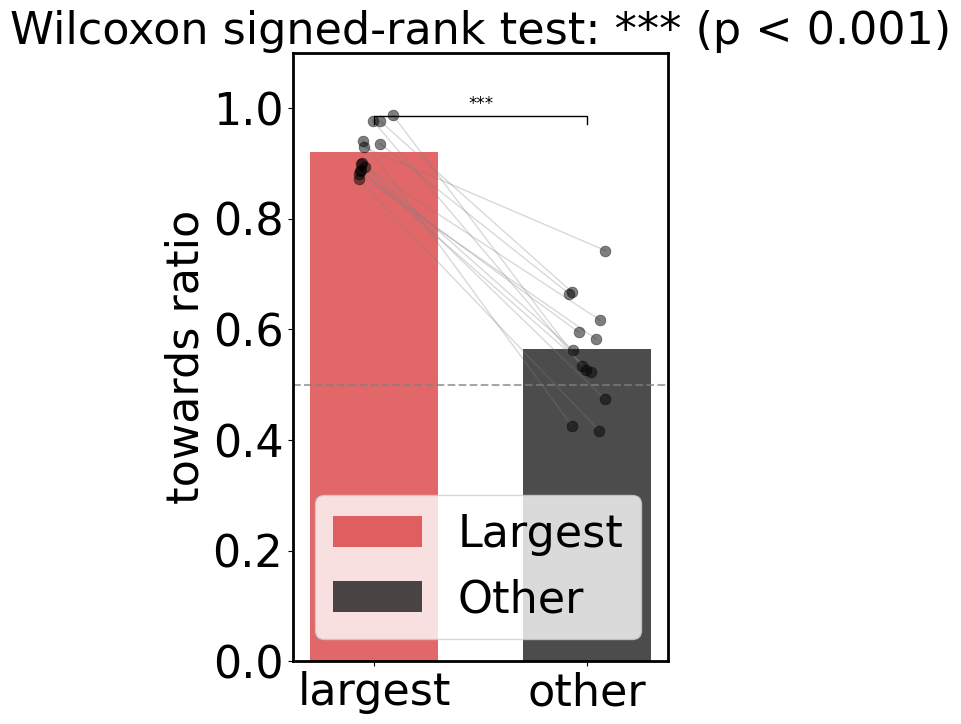


Population statistics (based on animal means):
  Largest turns towards ratio: 0.921 ± 0.040
  Other turns towards ratio: 0.564 ± 0.096

Number of animals: 13
Total trials: 1379

Individual animal data:
  Animal G8CK1LN: largest=0.988, other=0.534
  Animal G8CK1LT: largest=0.872, other=0.417
  Animal G8CK1RT: largest=0.942, other=0.426
  Animal G8CK1TT: largest=0.900, other=0.617
  Animal G8CKLN: largest=0.977, other=0.668
  Animal G8CKLT: largest=0.895, other=0.474
  Animal G8CKRN: largest=0.978, other=0.526
  Animal G8CKRT: largest=0.930, other=0.743
  Animal G8CKTT: largest=0.889, other=0.524
  Animal J701LT: largest=0.881, other=0.583
  Animal J701NN: largest=0.936, other=0.664
  Animal J701RN: largest=0.886, other=0.595
  Animal J701RT: largest=0.901, other=0.563

Summary statistics:
  Median largest ratio: 0.901
  Median other ratio: 0.563
  IQR largest ratio: 0.053
  IQR other ratio: 0.093


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Filter and process data as before
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store results
results = []

# Process each row to calculate towards ratios
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data
    if task != 'oadark':
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60  # Convert as in your code
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Calculate towards ratio for largest turn (negative values)
    largest_towards = 1 if largest_turn < 0 else 0
    
    # Calculate towards ratio for other turns
    if len(other_turns) > 0:
        other_towards = np.sum(np.array(other_turns) < 0) / len(other_turns)
    else:
        other_towards = 0
    
    results.append({
        'animal': animal,
        'task': task,
        'largest_towards': largest_towards,
        'other_towards': other_towards
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Check if we have OA data
if len(results_df) > 0:
    # Calculate individual animal averages for OA
    animal_ratios = results_df.groupby(['animal', 'task']).agg({
        'largest_towards': 'mean',
        'other_towards': 'mean'
    }).reset_index()
    
    # Perform Wilcoxon signed-rank test
    # Extract paired data for each animal
    largest_ratios = animal_ratios['largest_towards'].values
    other_ratios = animal_ratios['other_towards'].values
    
    # Check if we have enough data points for the test
    if len(largest_ratios) > 0 and len(other_ratios) > 0:
        try:
            # Perform Wilcoxon signed-rank test
            stat, p_value = wilcoxon(largest_ratios, other_ratios, 
                                     alternative='two-sided')
            
            print(f"Wilcoxon signed-rank test results:")
            print(f"  Test statistic: {stat}")
            print(f"  p-value: {p_value:.6f}")
            
            if p_value < 0.001:
                significance = "*** (p < 0.001)"
            elif p_value < 0.01:
                significance = "** (p < 0.01)"
            elif p_value < 0.05:
                significance = "* (p < 0.05)"
            else:
                significance = "ns (not significant)"
            
            print(f"  Significance: {significance}")
            print(f"  Number of animals: {len(largest_ratios)}")
            
        except Exception as e:
            print(f"Error performing Wilcoxon test: {e}")
            p_value = np.nan
            significance = "Test failed"
    else:
        print("Not enough data for Wilcoxon test")
        p_value = np.nan
        significance = ""
    
    # Calculate population averages based on animal averages
    population_largest_mean = animal_ratios['largest_towards'].mean()
    population_other_mean = animal_ratios['other_towards'].mean()
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # Bar width and positions
    bar_width = 0.6
    x_positions = [0, 1]
    
    # Plot bars using population averages
    bars1 = ax.bar(0, population_largest_mean, 
                   bar_width, color='tab:red', alpha=0.7, label='Largest')
    bars2 = ax.bar(1, population_other_mean, 
                   bar_width, color='black', alpha=0.7, label='Other')
    
    # Add horizontal dotted line at 0.5
    ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Add individual animal scatter points and connect them with lines
    task_data = animal_ratios[animal_ratios['task'] == 'oadark']
    
    if len(task_data) > 0:
        # Reduced jitter for less spread
        jitter1 = np.random.uniform(-0.09, 0.09, size=len(task_data))
        jitter2 = np.random.uniform(-0.09, 0.09, size=len(task_data))
        
        # Plot individual animal points for largest turns
        ax.scatter([0] * len(task_data) + jitter1, 
                   task_data['largest_towards'], 
                   color='black', alpha=0.5, 
                   linewidth=0.5, s=60, zorder=5)
        
        # Plot individual animal points for other turns
        ax.scatter([1] * len(task_data) + jitter2, 
                   task_data['other_towards'], 
                   color='black', alpha=0.5,  
                   linewidth=0.5, s=60, zorder=5)
        
        # Connect paired points with lines
        for i in range(len(task_data)):
            ax.plot([0 + jitter1[i], 1 + jitter2[i]], 
                    [task_data['largest_towards'].iloc[i], 
                     task_data['other_towards'].iloc[i]], 
                    color='gray', alpha=0.3, linewidth=1, zorder=4)
    
    # Add significance bracket if test was successful
    if not np.isnan(p_value) and p_value < 0.05:
        # Calculate y position for the bracket
        y_max = max(population_largest_mean, population_other_mean)
        bracket_height = 0.05
        bracket_y = y_max + bracket_height
        
        # Draw the bracket
        ax.plot([0, 0, 1, 1], 
                [bracket_y, bracket_y + bracket_height*0.3, 
                 bracket_y + bracket_height*0.3, bracket_y], 
                color='black', linewidth=1, zorder=6)
        
        # Add p-value text
        if p_value < 0.001:
            p_text = "***"
        elif p_value < 0.01:
            p_text = "**"
        elif p_value < 0.05:
            p_text = "*"
        
        ax.text(0.5, bracket_y + bracket_height*0.4, p_text, 
                ha='center', va='bottom', fontsize=12, zorder=6)
    
    # Customize the plot
    ax.set_ylabel('towards ratio')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['largest', 'other'])
    ax.set_ylim(0, 1.1)
    
    # Add title with test results
    if significance:
        ax.set_title(f"Wilcoxon signed-rank test: {significance}")
    
    # Add legend
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print population statistics
    print(f"\nPopulation statistics (based on animal means):")
    print(f"  Largest turns towards ratio: {population_largest_mean:.3f} ± {animal_ratios['largest_towards'].std():.3f}")
    print(f"  Other turns towards ratio: {population_other_mean:.3f} ± {animal_ratios['other_towards'].std():.3f}")
    print(f"\nNumber of animals: {len(task_data)}")
    print(f"Total trials: {len(results_df)}")
    
    # Also print individual animal data for reference
    print("\nIndividual animal data:")
    for i, row in animal_ratios.iterrows():
        print(f"  Animal {row['animal']}: largest={row['largest_towards']:.3f}, other={row['other_towards']:.3f}")
    
    # Print additional summary statistics
    print(f"\nSummary statistics:")
    print(f"  Median largest ratio: {np.median(largest_ratios):.3f}")
    print(f"  Median other ratio: {np.median(other_ratios):.3f}")
    print(f"  IQR largest ratio: {np.percentile(largest_ratios, 75) - np.percentile(largest_ratios, 25):.3f}")
    print(f"  IQR other ratio: {np.percentile(other_ratios, 75) - np.percentile(other_ratios, 25):.3f}")
    
else:
    print("No oadark data found after filtering")

LIGHT VS DARK COMPARISON - PROPORTION OF LARGEST MOVEMENTS
Animals with data in both conditions: 13

Individual animal proportions of largest movements:
  G8CK1LN: Light = 0.360, Dark = 0.417
  G8CK1LT: Light = 0.286, Dark = 0.322
  G8CK1RT: Light = 0.373, Dark = 0.415
  G8CK1TT: Light = 0.368, Dark = 0.346
  G8CKLN: Light = 0.311, Dark = 0.328
  G8CKLT: Light = 0.342, Dark = 0.369
  G8CKRN: Light = 0.320, Dark = 0.341
  G8CKRT: Light = 0.365, Dark = 0.429
  G8CKTT: Light = 0.372, Dark = 0.346
  J701LT: Light = 0.247, Dark = 0.237
  J701NN: Light = 0.233, Dark = 0.293
  J701RN: Light = 0.228, Dark = 0.219
  J701RT: Light = 0.256, Dark = 0.214

Between-animal mean proportion ± SEM:
  Light (oa): 0.312 ± 0.016
  Dark (oadark): 0.329 ± 0.020

----------------------------------------------------------------------
WILCOXON SIGNED-RANK TEST
----------------------------------------------------------------------
Test statistic (W): 23.000
P-value: 0.127
Number of paired samples: 13
Effect size

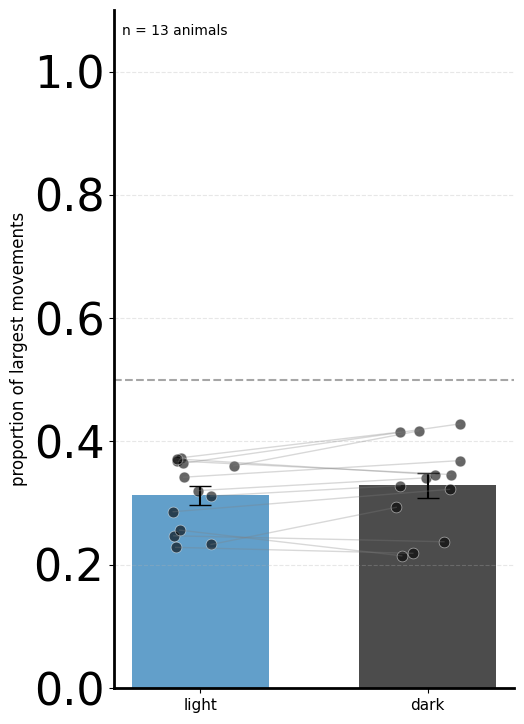


SUMMARY STATISTICS - PROPORTION OF LARGEST MOVEMENTS

    Condition  N Animals  Mean Proportion      SEM  95% CI Lower  95% CI Upper   Median      IQR
   Light (oa)         13         0.312472 0.015587       0.28192      0.343023 0.320261 0.108465
Dark (oadark)         13         0.329028 0.020019       0.28979      0.368266 0.340909 0.075829

Paired data saved to 'light_dark_largest_proportion_paired_data.csv'


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Filter and process data as before
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store movement counts
movement_counts = []

# Process each row to count movements
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data (oadark or oa)
    if task not in ['oadark', 'oa']:
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Count movements
    # Largest turn is always one movement
    num_largest = 1
    
    # Count other turns (only include if they exist)
    num_other = len(other_turns) if len(other_turns) > 0 else 0
    
    movement_counts.append({
        'animal': animal,
        'task': task,
        'num_largest': num_largest,
        'num_other': num_other,
        'total_movements': num_largest + num_other
    })

# Convert to DataFrame
movement_counts_df = pd.DataFrame(movement_counts)

# Check if we have data for both conditions
if len(movement_counts_df) > 0 and set(['oadark', 'oa']).issubset(set(movement_counts_df['task'])):
    print("LIGHT VS DARK COMPARISON - PROPORTION OF LARGEST MOVEMENTS")
    print("=" * 70)
    
    # Calculate between-animal proportions for each condition
    condition_data_list = []
    
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        
        if len(condition_data) > 0:
            # Group by animal to get totals per animal
            animal_totals = condition_data.groupby('animal').agg({
                'num_largest': 'sum',
                'num_other': 'sum',
                'total_movements': 'sum',
                'task': 'count'
            }).rename(columns={'task': 'num_trials'}).reset_index()
            
            # Calculate proportion of largest movements for each animal
            animal_totals['prop_largest'] = animal_totals['num_largest'] / animal_totals['total_movements']
            animal_totals['condition'] = condition
            
            condition_data_list.append(animal_totals)
    
    # Combine data from both conditions
    if len(condition_data_list) == 2:
        # Merge the data to get animals with both conditions
        light_data = condition_data_list[1] if condition_data_list[0]['condition'].iloc[0] == 'oadark' else condition_data_list[0]
        dark_data = condition_data_list[0] if condition_data_list[0]['condition'].iloc[0] == 'oadark' else condition_data_list[1]
        
        # Ensure light_data is 'oa' and dark_data is 'oadark'
        if light_data['condition'].iloc[0] != 'oa':
            light_data, dark_data = dark_data, light_data
        
        # Merge to get paired data
        paired_data = pd.merge(
            light_data[['animal', 'prop_largest', 'num_trials']].rename(
                columns={'prop_largest': 'prop_largest_light', 'num_trials': 'trials_light'}
            ),
            dark_data[['animal', 'prop_largest', 'num_trials']].rename(
                columns={'prop_largest': 'prop_largest_dark', 'num_trials': 'trials_dark'}
            ),
            on='animal',
            how='inner'
        )
        
        # Filter animals that have minimum trials in both conditions (e.g., at least 1)
        valid_paired_data = paired_data.dropna()
        
        if len(valid_paired_data) > 0:
            print(f"Animals with data in both conditions: {len(valid_paired_data)}")
            print("\nIndividual animal proportions of largest movements:")
            for _, row in valid_paired_data.iterrows():
                print(f"  {row['animal']}: Light = {row['prop_largest_light']:.3f}, "
                      f"Dark = {row['prop_largest_dark']:.3f}")
            
            # Calculate between-animal means
            light_mean = valid_paired_data['prop_largest_light'].mean()
            dark_mean = valid_paired_data['prop_largest_dark'].mean()
            
            light_sem = valid_paired_data['prop_largest_light'].std() / np.sqrt(len(valid_paired_data))
            dark_sem = valid_paired_data['prop_largest_dark'].std() / np.sqrt(len(valid_paired_data))
            
            print(f"\nBetween-animal mean proportion ± SEM:")
            print(f"  Light (oa): {light_mean:.3f} ± {light_sem:.3f}")
            print(f"  Dark (oadark): {dark_mean:.3f} ± {dark_sem:.3f}")
            
            # Perform Wilcoxon signed-rank test
            print(f"\n" + "-" * 70)
            print("WILCOXON SIGNED-RANK TEST")
            print("-" * 70)
            
            # Extract paired data
            light_props = valid_paired_data['prop_largest_light'].values
            dark_props = valid_paired_data['prop_largest_dark'].values
            
            # Perform Wilcoxon signed-rank test
            stat, p_value = stats.wilcoxon(light_props, dark_props)
            
            print(f"Test statistic (W): {stat:.3f}")
            print(f"P-value: {p_value:.3f}")
            
            # Calculate effect size (r = Z/√N)
            n = len(light_props)
            z = stats.norm.ppf(1 - p_value/2)  # Convert to z-score for effect size
            r_effect = z / np.sqrt(n)
            
            print(f"Number of paired samples: {n}")
            print(f"Effect size (r): {r_effect:.3f}")
            
            # Interpret p-value
            alpha = 0.05
            if p_value < alpha:
                print(f"\nResult: SIGNIFICANT difference (p = {p_value:.3f} < {alpha})")
                print(f"Conclusion: Proportion of largest movements differs significantly between light and dark conditions.")
            else:
                print(f"\nResult: NO significant difference (p = {p_value:.3f} ≥ {alpha})")
                print(f"Conclusion: No significant difference in proportion of largest movements between conditions.")
            
            # Create the bar plot
            fig, ax = plt.subplots(figsize=(6, 8))
            
            # Bar positions and width
            bar_positions = [0, 1]
            bar_width = 0.6
            
            # Plot bars with specified colors
            light_bar = ax.bar(0, light_mean, bar_width, 
                              color='tab:blue', alpha=0.7, 
                              yerr=light_sem, capsize=8, error_kw={'linewidth': 1.5})
            
            dark_bar = ax.bar(1, dark_mean, bar_width, 
                             color='black', alpha=0.7, 
                             yerr=dark_sem, capsize=8, error_kw={'linewidth': 1.5})
            
            # Add horizontal dotted line at 0.5 (for reference)
            ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
            
            # Add individual animal points with jitter
            jitter_width = 0.15
            light_jitter = np.random.uniform(-jitter_width, jitter_width, size=len(valid_paired_data))
            dark_jitter = np.random.uniform(-jitter_width, jitter_width, size=len(valid_paired_data))
            
            # Plot individual points for light condition
            ax.scatter([0] * len(valid_paired_data) + light_jitter,
                      valid_paired_data['prop_largest_light'],
                      color='black', alpha=0.6,
                      s=60, linewidth=0.5, edgecolor='white')
            
            # Plot individual points for dark condition
            ax.scatter([1] * len(valid_paired_data) + dark_jitter,
                      valid_paired_data['prop_largest_dark'],
                      color='black', alpha=0.6,
                      s=60, linewidth=0.5, edgecolor='white')
            
            # Connect paired points with lines
            for i, (light_val, dark_val) in enumerate(zip(valid_paired_data['prop_largest_light'], 
                                                         valid_paired_data['prop_largest_dark'])):
                jitter1 = light_jitter[i]
                jitter2 = dark_jitter[i]
                ax.plot([0 + jitter1, 1 + jitter2], 
                       [light_val, dark_val],
                       color='gray', alpha=0.3, linewidth=1)
            
            # Add significance bracket if p < 0.05
            if p_value < 0.05:
                # Determine y position for bracket
                y_max = max(light_mean + light_sem, dark_mean + dark_sem)
                y_bracket = y_max + 0.05
                
                # Add bracket
                ax.plot([0, 0, 1, 1], 
                       [y_bracket - 0.02, y_bracket, y_bracket, y_bracket - 0.02],
                       color='black', linewidth=1.5)
                
                # Add p-value text
                if p_value < 0.001:
                    p_text = "***"
                elif p_value < 0.01:
                    p_text = "**"
                elif p_value < 0.05:
                    p_text = "*"
                else:
                    p_text = f"p={p_value:.3f}"
                
                ax.text(0.5, y_bracket + 0.01, p_text,
                       ha='center', va='bottom', fontsize=12)
            
            # Customize the plot
            ax.set_ylabel('proportion of largest movements', fontsize=12)
            ax.set_xticks(bar_positions)
            ax.set_xticklabels(['light', 'dark'], fontsize=11)
            ax.set_ylim(0, 1.1)
            ax.set_yticks(np.arange(0, 1.1, 0.2))
            
            # Add grid for better readability
            ax.grid(True, alpha=0.3, linestyle='--', axis='y')
            
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Add sample size information
            ax.text(0.02, 0.98, f'n = {len(valid_paired_data)} animals',
                    transform=ax.transAxes, fontsize=10, 
                    verticalalignment='top')
            
            plt.tight_layout()
            plt.show()
            
            # Additional statistics table
            print(f"\n" + "=" * 70)
            print("SUMMARY STATISTICS - PROPORTION OF LARGEST MOVEMENTS")
            print("=" * 70)
            
            summary_data = {
                'Condition': ['Light (oa)', 'Dark (oadark)'],
                'N Animals': [len(valid_paired_data), len(valid_paired_data)],
                'Mean Proportion': [light_mean, dark_mean],
                'SEM': [light_sem, dark_sem],
                '95% CI Lower': [light_mean - 1.96*light_sem, dark_mean - 1.96*dark_sem],
                '95% CI Upper': [light_mean + 1.96*light_sem, dark_mean + 1.96*dark_sem],
                'Median': [valid_paired_data['prop_largest_light'].median(), 
                          valid_paired_data['prop_largest_dark'].median()],
                'IQR': [valid_paired_data['prop_largest_light'].quantile(0.75) - 
                       valid_paired_data['prop_largest_light'].quantile(0.25),
                       valid_paired_data['prop_largest_dark'].quantile(0.75) - 
                       valid_paired_data['prop_largest_dark'].quantile(0.25)]
            }
            
            summary_df = pd.DataFrame(summary_data)
            print("\n" + summary_df.to_string(index=False))
            
            # Save the paired data for reference
            valid_paired_data.to_csv('light_dark_largest_proportion_paired_data.csv', index=False)
            print(f"\nPaired data saved to 'light_dark_largest_proportion_paired_data.csv'")
            
        else:
            print("No animals with data in both conditions found.")
    
    else:
        print("Error: Could not process both conditions.")
        
else:
    print("Insufficient data for light vs dark comparison.")
    print(f"Tasks available: {movement_counts_df['task'].unique() if len(movement_counts_df) > 0 else 'None'}")

Number of animals in light condition: 13
Number of animals in dark condition: 13
Number of common animals: 9

Light condition - Animals: 13, Largest: 0.055, Regular: 0.945
Dark condition - Animals: 13, Largest: 0.060, Regular: 0.940


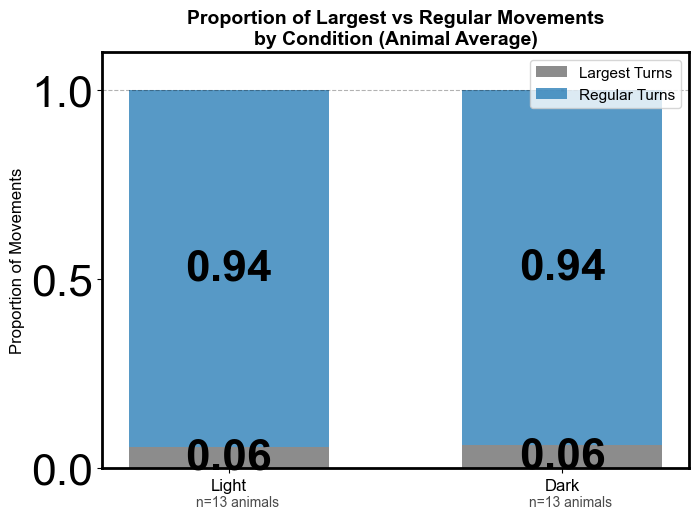


Individual Animal Proportions (common animals):
Animal	Light Largest	Light Regular	Dark Largest	Dark Regular
------------------------------------------------------------
G8CK1LN	0.058		0.942		0.061		0.939
G8CK1LT	0.055		0.945		0.051		0.949
G8CK1RT	0.053		0.947		0.059		0.941
G8CK1TT	0.059		0.941		0.064		0.936
G8CKLN	0.053		0.947		0.068		0.932
G8CKLT	0.059		0.941		0.079		0.921
G8CKRN	0.054		0.946		0.067		0.933
G8CKRT	0.054		0.946		0.053		0.947
G8CKTT	0.053		0.947		0.062		0.938


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'data' is already loaded and contains your columns
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]

# Split into light and dark conditions
light = data[data.task == 'oa'].copy()
dark = data[data.task == 'oadark'].copy()

# Function to calculate proportions for a given dataset
def calculate_proportions(df, animal_col='animal', velocity_col='head_turn_velocity'):
    """Calculate proportion of largest and regular movements for each animal."""
    
    animal_props = {}
    
    # Get unique animals
    animals = df[animal_col].unique()
    
    for animal in animals:
        animal_data = df[df[animal_col] == animal]
        
        # Get velocities and convert to deg/sec
        velocities = animal_data[velocity_col].to_numpy() * 60
        
        # Separate positive and negative
        pos_vel = velocities[velocities > 0]
        neg_vel = velocities[velocities < 0]
        
        # Define largest movements (top 5% by absolute value for each direction)
        if len(pos_vel) > 0:
            pos_threshold = np.percentile(pos_vel, 95)
            largest_pos = pos_vel[pos_vel >= pos_threshold]
            regular_pos = pos_vel[pos_vel < pos_threshold]
        else:
            largest_pos = np.array([])
            regular_pos = np.array([])
        
        if len(neg_vel) > 0:
            neg_threshold = np.percentile(np.abs(neg_vel), 95)
            largest_neg = neg_vel[np.abs(neg_vel) >= neg_threshold]
            regular_neg = neg_vel[np.abs(neg_vel) < neg_threshold]
        else:
            largest_neg = np.array([])
            regular_neg = np.array([])
        
        # Calculate counts
        n_largest = len(largest_pos) + len(largest_neg)
        n_regular = len(regular_pos) + len(regular_neg)
        n_total = n_largest + n_regular
        
        if n_total > 0:
            prop_largest = n_largest / n_total
            prop_regular = n_regular / n_total
        else:
            prop_largest = 0
            prop_regular = 0
        
        animal_props[animal] = {
            'prop_largest': prop_largest,
            'prop_regular': prop_regular,
            'n_largest': n_largest,
            'n_regular': n_regular,
            'n_total': n_total
        }
    
    return animal_props

# Calculate proportions for light and dark conditions
light_props = calculate_proportions(light)
dark_props = calculate_proportions(dark)

# Get common animals between both conditions (optional)
common_animals = set(light_props.keys()) & set(dark_props.keys())
print(f"Number of animals in light condition: {len(light_props)}")
print(f"Number of animals in dark condition: {len(dark_props)}")
print(f"Number of common animals: {len(common_animals)}")

# Calculate population averages
def calculate_population_average(animal_props, animals_subset=None):
    """Calculate mean proportions across animals."""
    if animals_subset is None:
        animals_subset = list(animal_props.keys())
    
    props_largest = []
    props_regular = []
    
    for animal in animals_subset:
        if animal in animal_props:
            props_largest.append(animal_props[animal]['prop_largest'])
            props_regular.append(animal_props[animal]['prop_regular'])
    
    if len(props_largest) > 0:
        mean_largest = np.mean(props_largest)
        mean_regular = np.mean(props_regular)
        sem_largest = np.std(props_largest) / np.sqrt(len(props_largest))
        sem_regular = np.std(props_regular) / np.sqrt(len(props_regular))
    else:
        mean_largest = mean_regular = sem_largest = sem_regular = 0
    
    return {
        'mean_largest': mean_largest,
        'mean_regular': mean_regular,
        'sem_largest': sem_largest,
        'sem_regular': sem_regular,
        'n_animals': len(props_largest)
    }

# Calculate population averages
# Option 1: Use all available animals in each condition
light_avg = calculate_population_average(light_props)
dark_avg = calculate_population_average(dark_props)

# Option 2: Use only common animals (uncomment if preferred)
# light_avg = calculate_population_average(light_props, common_animals)
# dark_avg = calculate_population_average(dark_props, common_animals)

print(f"\nLight condition - Animals: {light_avg['n_animals']}, Largest: {light_avg['mean_largest']:.3f}, Regular: {light_avg['mean_regular']:.3f}")
print(f"Dark condition - Animals: {dark_avg['n_animals']}, Largest: {dark_avg['mean_largest']:.3f}, Regular: {dark_avg['mean_regular']:.3f}")

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 6))

# Set bar positions
conditions = ['Light', 'Dark']
x_pos = np.arange(len(conditions))
bar_width = 0.6

# Prepare data for stacked bars
largest_props = [light_avg['mean_largest'], dark_avg['mean_largest']]
regular_props = [light_avg['mean_regular'], dark_avg['mean_regular']]

largest_sems = [light_avg['sem_largest'], dark_avg['sem_largest']]
regular_sems = [light_avg['sem_regular'], dark_avg['sem_regular']]

# Plot stacked bars
bar_largest = ax.bar(x_pos, largest_props, bar_width, 
                     color='grey', alpha=0.9, label='Largest Turns',
                     yerr=largest_sems, error_kw={'ecolor': 'black', 'capthick': 2, 'elinewidth': 2})

bar_regular = ax.bar(x_pos, regular_props, bar_width, 
                     bottom=largest_props, color='tab:blue', alpha=0.75, label='Regular Turns',
                     yerr=regular_sems, error_kw={'ecolor': 'black', 'capthick': 2, 'elinewidth': 2})

# Add value labels on bars
def add_value_labels(bars, bottoms=None, fmt='.2f'):
    """Add value labels on top of bars."""
    if bottoms is None:
        bottoms = [0] * len(bars)
    
    for bar, bottom in zip(bars, bottoms):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., bottom + height/2,
                f'{height:.2f}', ha='center', va='center', fontweight='bold')

add_value_labels(bar_largest)
add_value_labels(bar_regular, largest_props)

# Configure plot
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylabel('Proportion of Movements', fontsize=12)
ax.set_title('Proportion of Largest vs Regular Movements\nby Condition (Animal Average)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)

# Add legend
ax.legend(loc='upper right', fontsize=11)

# Add sample size annotations
ax.text(-0.1, -0.1, f'n={light_avg["n_animals"]} animals', 
        transform=ax.transData, fontsize=10, alpha=0.7)
ax.text(0.9, -0.1, f'n={dark_avg["n_animals"]} animals', 
        transform=ax.transData, fontsize=10, alpha=0.7)

plt.tight_layout()
plt.show()

# Optional: Create a table with individual animal data
if len(common_animals) > 0:
    print("\nIndividual Animal Proportions (common animals):")
    print("Animal\tLight Largest\tLight Regular\tDark Largest\tDark Regular")
    print("-" * 60)
    
    for animal in sorted(common_animals)[:10]:  # Show first 10
        light_prop = light_props[animal]['prop_largest']
        dark_prop = dark_props[animal]['prop_largest']
        print(f"{animal}\t{light_prop:.3f}\t\t{1-light_prop:.3f}\t\t{dark_prop:.3f}\t\t{1-dark_prop:.3f}")
    
    if len(common_animals) > 10:
        print(f"... and {len(common_animals) - 10} more animals")

J704RT
821.7714966941973
J704NN
676.8319727799461
J704LT
711.6115829871372
J704LN
693.5940056434474
G8CK1RT
420.1552245904775
G8CK1LT
481.8740862648665
G8CK1TT
463.34017618617634
G8CK1LN
365.8256540080724
G8CKRT
470.5661277232496
G8CKLT
515.2745453534598
G8CKTT
477.36419274528714
G8CKRN
506.52327815621254
G8CKLN
494.6886603338934


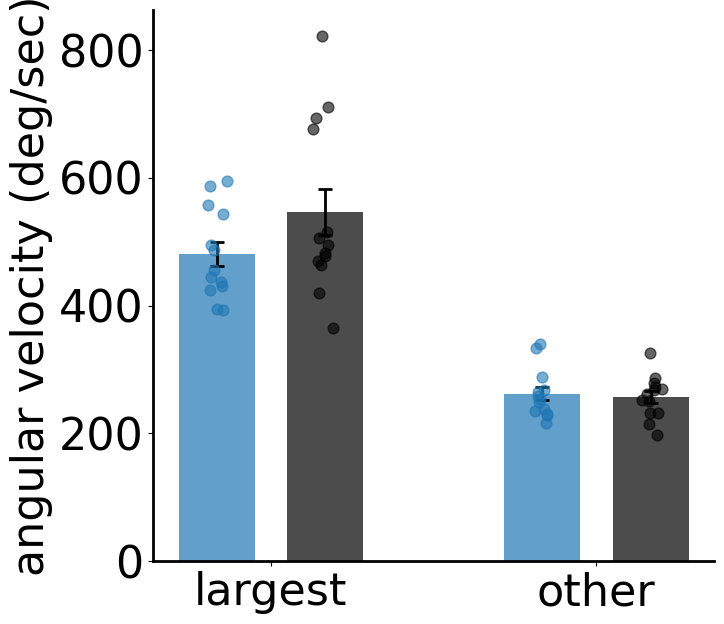

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
oa_data = data[data['task'] == 'oa']
oadark_data = data[data['task'] == 'oadark']

# Calculate animal-level means for plotting
oa_animal_largest = []
oa_animal_other = []
oadark_animal_largest = []
oadark_animal_other = []

for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    after_mean = np.nanmean(np.abs(animal_data['head_turn_velocity'].to_numpy()))*60
    other_movments_after_mean = np.nanmean(np.abs(flatten_list_of_arrays(animal_data.head_turn_velocities.to_list())))*60
    oa_animal_largest.append(after_mean)
    oa_animal_other.append(other_movments_after_mean)

for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    after_mean = np.nanmean(np.abs(animal_data['head_turn_velocity'].to_numpy()))*60
    other_movments_after_mean =  np.nanmean(np.abs(flatten_list_of_arrays(animal_data.head_turn_velocities.to_list())))*60
    print(animal)
    oadark_animal_largest.append(after_mean)
    print(after_mean)
    oadark_animal_other.append(other_movments_after_mean)

# CHANGED: Calculate population means from animal means instead of direct mean
largest_movment_oa_after = np.nanmean(oa_animal_largest)  # Changed
other_movments_oa_after = np.nanmean(oa_animal_other)  # Changed
largest_movment_oadark_after = np.nanmean(oadark_animal_largest)  # Changed
other_movments_oadark_after = np.nanmean(oadark_animal_other)  # Changed

# Calculate SEM for error bars
oa_largest_sem = np.std(oa_animal_largest) / np.sqrt(len(oa_animal_largest))
oa_other_sem = np.std(oa_animal_other) / np.sqrt(len(oa_animal_other))
oadark_largest_sem = np.std(oadark_animal_largest) / np.sqrt(len(oadark_animal_largest))
oadark_other_sem = np.std(oadark_animal_other) / np.sqrt(len(oadark_animal_other))

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 7))

# Bar positions
x_pos = np.array([0, 3, 1, 4])  # OA largest, OA other, OAdark largest, OAdark other
bar_width = 0.7

# Bar heights (means)
heights = [
    largest_movment_oa_after,
    other_movments_oa_after,
    largest_movment_oadark_after,
    other_movments_oadark_after
]

# SEM values for error bars
errors = [oa_largest_sem, oa_other_sem, oadark_largest_sem, oadark_other_sem]

# Colors
colors = ['tab:blue', 'tab:blue', 'black', 'black']

# Create bars
bars = ax.bar(x_pos, heights, bar_width, color=colors, alpha=0.7, 
              yerr=errors, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

# Add individual animal points
# OA largest movements
for i, value in enumerate(oa_animal_largest):
    ax.scatter(x_pos[0] + np.random.normal(0, 0.05), value, color='tab:blue', alpha=0.6, s=60, zorder=3)

# OA other movements
for i, value in enumerate(oa_animal_other):
    ax.scatter(x_pos[1] + np.random.normal(0, 0.05), value, color='tab:blue', alpha=0.6, s=60, zorder=3)

# OAdark largest movements
for i, value in enumerate(oadark_animal_largest):
    ax.scatter(x_pos[2] + np.random.normal(0, 0.05), value, color='black', alpha=0.6, s=60, zorder=3)

# OAdark other movements
for i, value in enumerate(oadark_animal_other):
    ax.scatter(x_pos[3] + np.random.normal(0, 0.05), value, color='black', alpha=0.6, s=60, zorder=3)

# Customize the plot
ax.set_xticks(np.array([.5, 3.5]),['largest','other'])

ax.set_ylabel('angular velocity (deg/sec)')



# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\largest_other_angular_velocity_1.pdf",dpi = 300, transparent=True)

WILCOXON SIGNED-RANK TESTS - ANGULAR VELOCITY

1. TEST FOR LARGEST MOVEMENTS (OA vs OAdark):
----------------------------------------
Number of paired animals: 13
OA mean (largest): 480.51 deg/sec
OAdark mean (largest): 546.11 deg/sec
OA median (largest): 455.69 deg/sec
OAdark median (largest): 494.69 deg/sec
Wilcoxon statistic: 24.000
P-value: 0.146484
Result: p > 0.05 (Not significant)

Individual animal values (deg/sec):
  J701LT: OA=542.97, OAdark=711.61, diff=-168.64
  J701RT: OA=445.28, OAdark=821.77, diff=-376.49
  J701NN: OA=587.70, OAdark=676.83, diff=-89.13
  J701RN: OA=455.69, OAdark=693.59, diff=-237.91
  G8CK1RT: OA=487.19, OAdark=420.16, diff=67.03
  G8CK1LT: OA=595.34, OAdark=481.87, diff=113.46
  G8CK1TT: OA=430.33, OAdark=463.34, diff=-33.01
  G8CK1LN: OA=395.10, OAdark=365.83, diff=29.28
  G8CKRT: OA=424.71, OAdark=470.57, diff=-45.86
  G8CKLT: OA=436.64, OAdark=515.27, diff=-78.63
  G8CKTT: OA=494.45, OAdark=477.36, diff=17.09
  G8CKRN: OA=558.14, OAdark=506.52, diff

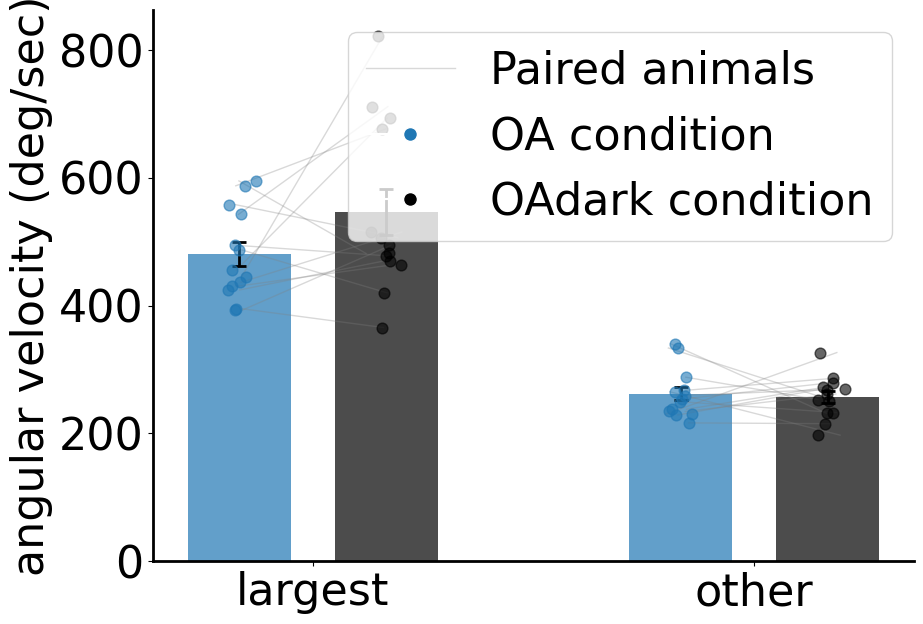

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
oa_data = data[data['task'] == 'oa']
oadark_data = data[data['task'] == 'oadark']

# Calculate animal-level means for plotting
oa_animal_largest = []
oa_animal_other = []
oadark_animal_largest = []
oadark_animal_other = []

# Dictionary to store animal data for paired testing
animal_data_dict = {}

for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    after_mean = np.nanmean(np.abs(animal_data['head_turn_velocity'].to_numpy()))*60
    other_movments_after_mean = np.nanmean(np.abs(flatten_list_of_arrays(animal_data.head_turn_velocities.to_list())))*60
    oa_animal_largest.append(after_mean)
    oa_animal_other.append(other_movments_after_mean)
    
    # Store in dictionary for paired testing
    if animal not in animal_data_dict:
        animal_data_dict[animal] = {'oa': {}, 'oadark': {}}
    animal_data_dict[animal]['oa']['largest'] = after_mean
    animal_data_dict[animal]['oa']['other'] = other_movments_after_mean

for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    after_mean = np.nanmean(np.abs(animal_data['head_turn_velocity'].to_numpy()))*60
    other_movments_after_mean = np.nanmean(np.abs(flatten_list_of_arrays(animal_data.head_turn_velocities.to_list())))*60
    
    oadark_animal_largest.append(after_mean)
    oadark_animal_other.append(other_movments_after_mean)
    
    # Store in dictionary for paired testing
    if animal not in animal_data_dict:
        animal_data_dict[animal] = {'oa': {}, 'oadark': {}}
    animal_data_dict[animal]['oadark']['largest'] = after_mean
    animal_data_dict[animal]['oadark']['other'] = other_movments_after_mean

# CHANGED: Calculate population means from animal means instead of direct mean
largest_movment_oa_after = np.nanmean(oa_animal_largest)  # Changed
other_movments_oa_after = np.nanmean(oa_animal_other)  # Changed
largest_movment_oadark_after = np.nanmean(oadark_animal_largest)  # Changed
other_movments_oadark_after = np.nanmean(oadark_animal_other)  # Changed

# Perform Wilcoxon signed-rank tests
print("=" * 60)
print("WILCOXON SIGNED-RANK TESTS - ANGULAR VELOCITY")
print("=" * 60)

# Test 1: Largest movements comparison (OA vs OAdark)
print("\n1. TEST FOR LARGEST MOVEMENTS (OA vs OAdark):")
print("-" * 40)

# Get paired data for animals that have both OA and OAdark measurements
paired_largest_oa = []
paired_largest_oadark = []
paired_animals_largest = []

for animal in animal_data_dict:
    if 'oa' in animal_data_dict[animal] and 'oadark' in animal_data_dict[animal]:
        if 'largest' in animal_data_dict[animal]['oa'] and 'largest' in animal_data_dict[animal]['oadark']:
            paired_largest_oa.append(animal_data_dict[animal]['oa']['largest'])
            paired_largest_oadark.append(animal_data_dict[animal]['oadark']['largest'])
            paired_animals_largest.append(animal)

if len(paired_largest_oa) > 1 and len(paired_largest_oadark) > 1:
    # Perform Wilcoxon signed-rank test
    stat, p_value = wilcoxon(paired_largest_oa, paired_largest_oadark)
    
    print(f"Number of paired animals: {len(paired_largest_oa)}")
    print(f"OA mean (largest): {np.mean(paired_largest_oa):.2f} deg/sec")
    print(f"OAdark mean (largest): {np.mean(paired_largest_oadark):.2f} deg/sec")
    print(f"OA median (largest): {np.median(paired_largest_oa):.2f} deg/sec")
    print(f"OAdark median (largest): {np.median(paired_largest_oadark):.2f} deg/sec")
    print(f"Wilcoxon statistic: {stat:.3f}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.001:
        print("Result: *** p < 0.001 (Highly significant)")
    elif p_value < 0.01:
        print("Result: ** p < 0.01 (Very significant)")
    elif p_value < 0.05:
        print("Result: * p < 0.05 (Significant)")
    else:
        print("Result: p > 0.05 (Not significant)")
        
    # Print individual animal values
    print("\nIndividual animal values (deg/sec):")
    for animal in paired_animals_largest:
        oa_val = animal_data_dict[animal]['oa']['largest']
        oadark_val = animal_data_dict[animal]['oadark']['largest']
        diff = oa_val - oadark_val
        print(f"  {animal}: OA={oa_val:.2f}, OAdark={oadark_val:.2f}, diff={diff:.2f}")
else:
    print("Insufficient paired data for largest movements test")
    print(f"Animals with OA data: {len(oa_animal_largest)}")
    print(f"Animals with OAdark data: {len(oadark_animal_largest)}")
    print(f"Animals with both: {len(paired_largest_oa)}")

# Test 2: Other movements comparison (OA vs OAdark)
print("\n2. TEST FOR OTHER MOVEMENTS (OA vs OAdark):")
print("-" * 40)

# Get paired data for animals that have both OA and OAdark measurements
paired_other_oa = []
paired_other_oadark = []
paired_animals_other = []

for animal in animal_data_dict:
    if 'oa' in animal_data_dict[animal] and 'oadark' in animal_data_dict[animal]:
        if 'other' in animal_data_dict[animal]['oa'] and 'other' in animal_data_dict[animal]['oadark']:
            paired_other_oa.append(animal_data_dict[animal]['oa']['other'])
            paired_other_oadark.append(animal_data_dict[animal]['oadark']['other'])
            paired_animals_other.append(animal)

if len(paired_other_oa) > 1 and len(paired_other_oadark) > 1:
    # Perform Wilcoxon signed-rank test
    stat, p_value = wilcoxon(paired_other_oa, paired_other_oadark)
    
    print(f"Number of paired animals: {len(paired_other_oa)}")
    print(f"OA mean (other): {np.mean(paired_other_oa):.2f} deg/sec")
    print(f"OAdark mean (other): {np.mean(paired_other_oadark):.2f} deg/sec")
    print(f"OA median (other): {np.median(paired_other_oa):.2f} deg/sec")
    print(f"OAdark median (other): {np.median(paired_other_oadark):.2f} deg/sec")
    print(f"Wilcoxon statistic: {stat:.3f}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.001:
        print("Result: *** p < 0.001 (Highly significant)")
    elif p_value < 0.01:
        print("Result: ** p < 0.01 (Very significant)")
    elif p_value < 0.05:
        print("Result: * p < 0.05 (Significant)")
    else:
        print("Result: p > 0.05 (Not significant)")
        
    # Print individual animal values
    print("\nIndividual animal values (deg/sec):")
    for animal in paired_animals_other:
        oa_val = animal_data_dict[animal]['oa']['other']
        oadark_val = animal_data_dict[animal]['oadark']['other']
        diff = oa_val - oadark_val
        print(f"  {animal}: OA={oa_val:.2f}, OAdark={oadark_val:.2f}, diff={diff:.2f}")
else:
    print("Insufficient paired data for other movements test")
    print(f"Animals with OA data: {len(oa_animal_other)}")
    print(f"Animals with OAdark data: {len(oadark_animal_other)}")
    print(f"Animals with both: {len(paired_other_oa)}")

# Test 3: Within OA condition (largest vs other)
print("\n3. WITHIN OA CONDITION (largest vs other movements):")
print("-" * 40)

# Get paired data for animals that have both largest and other measurements in OA
paired_oa_largest_vs_other = []
paired_oa_largest = []
paired_oa_other = []

for animal in animal_data_dict:
    if 'oa' in animal_data_dict[animal]:
        if ('largest' in animal_data_dict[animal]['oa'] and 
            'other' in animal_data_dict[animal]['oa']):
            paired_oa_largest.append(animal_data_dict[animal]['oa']['largest'])
            paired_oa_other.append(animal_data_dict[animal]['oa']['other'])

if len(paired_oa_largest) > 1 and len(paired_oa_other) > 1:
    # Perform Wilcoxon signed-rank test
    stat, p_value = wilcoxon(paired_oa_largest, paired_oa_other)
    
    print(f"Number of animals: {len(paired_oa_largest)}")
    print(f"Largest movements mean: {np.mean(paired_oa_largest):.2f} deg/sec")
    print(f"Other movements mean: {np.mean(paired_oa_other):.2f} deg/sec")
    print(f"Largest movements median: {np.median(paired_oa_largest):.2f} deg/sec")
    print(f"Other movements median: {np.median(paired_oa_other):.2f} deg/sec")
    print(f"Wilcoxon statistic: {stat:.3f}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.001:
        print("Result: *** p < 0.001 (Highly significant)")
    elif p_value < 0.01:
        print("Result: ** p < 0.01 (Very significant)")
    elif p_value < 0.05:
        print("Result: * p < 0.05 (Significant)")
    else:
        print("Result: p > 0.05 (Not significant)")
else:
    print("Insufficient data for within OA comparison")

# Test 4: Within OAdark condition (largest vs other)
print("\n4. WITHIN OAdark CONDITION (largest vs other movements):")
print("-" * 40)

# Get paired data for animals that have both largest and other measurements in OAdark
paired_oadark_largest_vs_other = []
paired_oadark_largest = []
paired_oadark_other = []

for animal in animal_data_dict:
    if 'oadark' in animal_data_dict[animal]:
        if ('largest' in animal_data_dict[animal]['oadark'] and 
            'other' in animal_data_dict[animal]['oadark']):
            paired_oadark_largest.append(animal_data_dict[animal]['oadark']['largest'])
            paired_oadark_other.append(animal_data_dict[animal]['oadark']['other'])

if len(paired_oadark_largest) > 1 and len(paired_oadark_other) > 1:
    # Perform Wilcoxon signed-rank test
    stat, p_value = wilcoxon(paired_oadark_largest, paired_oadark_other)
    
    print(f"Number of animals: {len(paired_oadark_largest)}")
    print(f"Largest movements mean: {np.mean(paired_oadark_largest):.2f} deg/sec")
    print(f"Other movements mean: {np.mean(paired_oadark_other):.2f} deg/sec")
    print(f"Largest movements median: {np.median(paired_oadark_largest):.2f} deg/sec")
    print(f"Other movements median: {np.median(paired_oadark_other):.2f} deg/sec")
    print(f"Wilcoxon statistic: {stat:.3f}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.001:
        print("Result: *** p < 0.001 (Highly significant)")
    elif p_value < 0.01:
        print("Result: ** p < 0.01 (Very significant)")
    elif p_value < 0.05:
        print("Result: * p < 0.05 (Significant)")
    else:
        print("Result: p > 0.05 (Not significant)")
else:
    print("Insufficient data for within OAdark comparison")

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"\nLargest movements:")
print(f"  OA: n={len(oa_animal_largest)}, mean±SEM={np.mean(oa_animal_largest):.2f}±{np.std(oa_animal_largest)/np.sqrt(len(oa_animal_largest)):.2f} deg/sec, median={np.median(oa_animal_largest):.2f} deg/sec")
print(f"  OAdark: n={len(oadark_animal_largest)}, mean±SEM={np.mean(oadark_animal_largest):.2f}±{np.std(oadark_animal_largest)/np.sqrt(len(oadark_animal_largest)):.2f} deg/sec, median={np.median(oadark_animal_largest):.2f} deg/sec")

print(f"\nOther movements:")
print(f"  OA: n={len(oa_animal_other)}, mean±SEM={np.mean(oa_animal_other):.2f}±{np.std(oa_animal_other)/np.sqrt(len(oa_animal_other)):.2f} deg/sec, median={np.median(oa_animal_other):.2f} deg/sec")
print(f"  OAdark: n={len(oadark_animal_other)}, mean±SEM={np.mean(oadark_animal_other):.2f}±{np.std(oadark_animal_other)/np.sqrt(len(oadark_animal_other)):.2f} deg/sec, median={np.median(oadark_animal_other):.2f} deg/sec")

print("\n" + "=" * 60)

# Continue with the plotting code...
# Calculate SEM for error bars
oa_largest_sem = np.std(oa_animal_largest) / np.sqrt(len(oa_animal_largest))
oa_other_sem = np.std(oa_animal_other) / np.sqrt(len(oa_animal_other))
oadark_largest_sem = np.std(oadark_animal_largest) / np.sqrt(len(oadark_animal_largest))
oadark_other_sem = np.std(oadark_animal_other) / np.sqrt(len(oadark_animal_other))

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Bar positions
x_pos = np.array([0, 3, 1, 4])  # OA largest, OA other, OAdark largest, OAdark other
bar_width = 0.7

# Bar heights (means)
heights = [
    largest_movment_oa_after,
    other_movments_oa_after,
    largest_movment_oadark_after,
    other_movments_oadark_after
]

# SEM values for error bars
errors = [oa_largest_sem, oa_other_sem, oadark_largest_sem, oadark_other_sem]

# Colors
colors = ['tab:blue', 'tab:blue', 'black', 'black']

# Create bars
bars = ax.bar(x_pos, heights, bar_width, color=colors, alpha=0.7, 
              yerr=errors, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

# Add individual animal points with connected lines for paired animals
# Store point positions for connecting lines
point_positions = {}

# OA largest movements
for i, value in enumerate(oa_animal_largest):
    ax.scatter(x_pos[0] + np.random.normal(0, 0.05), value, color='tab:blue', alpha=0.6, s=60, zorder=3)
    # Store position for connecting lines
    animal_id = oa_data['animal'].unique()[i]
    if animal_id not in point_positions:
        point_positions[animal_id] = {}
    point_positions[animal_id]['oa_largest'] = (x_pos[0] + np.random.normal(0, 0.05), value)

# OA other movements
for i, value in enumerate(oa_animal_other):
    ax.scatter(x_pos[1] + np.random.normal(0, 0.05), value, color='tab:blue', alpha=0.6, s=60, zorder=3)
    animal_id = oa_data['animal'].unique()[i]
    if animal_id not in point_positions:
        point_positions[animal_id] = {}
    point_positions[animal_id]['oa_other'] = (x_pos[1] + np.random.normal(0, 0.05), value)

# OAdark largest movements
for i, value in enumerate(oadark_animal_largest):
    ax.scatter(x_pos[2] + np.random.normal(0, 0.05), value, color='black', alpha=0.6, s=60, zorder=3)
    animal_id = oadark_data['animal'].unique()[i]
    if animal_id not in point_positions:
        point_positions[animal_id] = {}
    point_positions[animal_id]['oadark_largest'] = (x_pos[2] + np.random.normal(0, 0.05), value)

# OAdark other movements
for i, value in enumerate(oadark_animal_other):
    ax.scatter(x_pos[3] + np.random.normal(0, 0.05), value, color='black', alpha=0.6, s=60, zorder=3)
    animal_id = oadark_data['animal'].unique()[i]
    if animal_id not in point_positions:
        point_positions[animal_id] = {}
    point_positions[animal_id]['oadark_other'] = (x_pos[3] + np.random.normal(0, 0.05), value)

# Add connecting lines for paired animals
print(f"\nConnecting lines for paired animals:")
print(f"  Largest movements: {len(paired_animals_largest)} animals")
print(f"  Other movements: {len(paired_animals_other)} animals")

# Connect largest movements (OA vs OAdark)
for animal in paired_animals_largest:
    if ('oa_largest' in point_positions.get(animal, {}) and 
        'oadark_largest' in point_positions.get(animal, {})):
        x1, y1 = point_positions[animal]['oa_largest']
        x2, y2 = point_positions[animal]['oadark_largest']
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=1, zorder=1)

# Connect other movements (OA vs OAdark)
for animal in paired_animals_other:
    if ('oa_other' in point_positions.get(animal, {}) and 
        'oadark_other' in point_positions.get(animal, {})):
        x1, y1 = point_positions[animal]['oa_other']
        x2, y2 = point_positions[animal]['oadark_other']
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=1, zorder=1)

# Customize the plot
ax.set_xticks(np.array([.5, 3.5]))
ax.set_xticklabels(['largest','other'])

ax.set_ylabel('angular velocity (deg/sec)')

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', alpha=0.3, linewidth=1, label='Paired animals'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', 
           markersize=10, label='OA condition'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
           markersize=10, label='OAdark condition')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

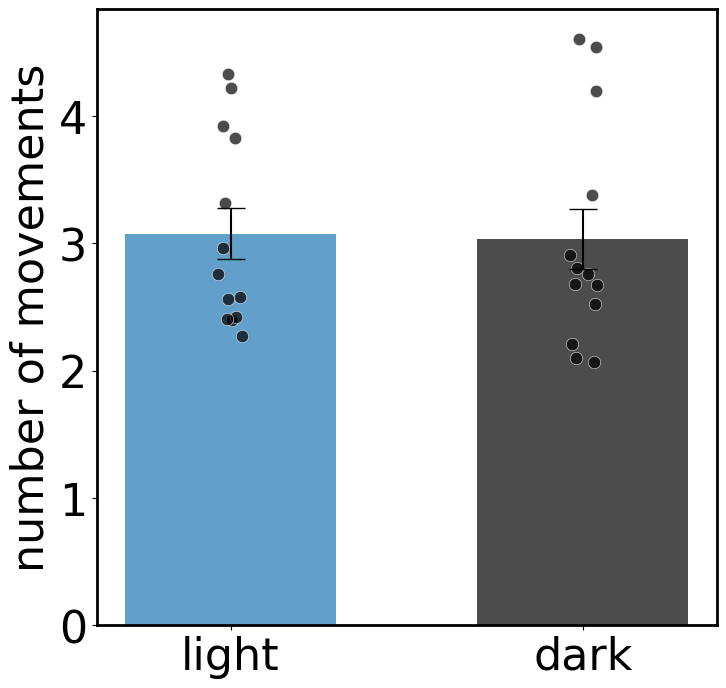

In [16]:
from matplotlib.lines import Line2D

# Prepare data
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.num_turn>=0]  # Only valid distances


# Split by turn direction
left_data = data[data['task'] == 'oa']
right_data = data[data['task'] == 'oadark']

# Calculate animal-level means
left_animal_means = []
right_animal_means = []

for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['num_turn'].mean()
    left_animal_means.append(animal_dist)

for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['num_turn'].mean()
    right_animal_means.append(animal_dist)

# Calculate means and standard errors from animal means
left_mean = np.mean(left_animal_means)  # Changed
right_mean = np.mean(right_animal_means)  # Changed
left_se = np.std(left_animal_means) / np.sqrt(len(left_animal_means))  # Changed
right_se = np.std(right_animal_means) / np.sqrt(len(right_animal_means))  # Changed

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_se, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, right_mean, yerr=right_se, color='black', 
       alpha=0.7, capsize=10, width=0.6, label='dark')

# Jitter settings
jitter_width = 0.04  # Max horizontal spread

# Add individual animal points for left turns with random jitter
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['num_turn'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right turns with random jitter
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['num_turn'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])
#ax.set_yticks([0,5,10,15])
ax.set_ylabel('number of movements')


# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='light'),
                   Line2D([0], [0], color='black', lw=4, label='dark')]
#ax.legend(handles=legend_elements, loc='upper right')
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\light_dark_number_of_movements.pdf",dpi = 300, transparent=True)

WILCOXON SIGNED-RANK TEST - NUMBER OF MOVEMENTS

COMPARISON: OA (light) vs OAdark (dark)
----------------------------------------
Number of paired animals: 13
OA (light) mean: 3.08 movements
OAdark (dark) mean: 3.03 movements
OA (light) median: 2.76 movements
OAdark (dark) median: 2.76 movements
Wilcoxon statistic: 39.000
P-value: 0.684814
Result: p > 0.05 (Not significant)

Individual animal values (number of movements):
  J701LT: OA=3.92, OAdark=4.19, diff=-0.28
  J701RT: OA=3.83, OAdark=4.61, diff=-0.78
  J701NN: OA=4.22, OAdark=3.38, diff=0.84
  J701RN: OA=4.33, OAdark=4.54, diff=-0.21
  G8CK1RT: OA=2.40, OAdark=2.07, diff=0.33
  G8CK1LT: OA=3.32, OAdark=2.81, diff=0.51
  G8CK1TT: OA=2.42, OAdark=2.67, diff=-0.25
  G8CK1LN: OA=2.57, OAdark=2.10, diff=0.47
  G8CKRT: OA=2.40, OAdark=2.21, diff=0.19
  G8CKLT: OA=2.58, OAdark=2.53, diff=0.05
  G8CKTT: OA=2.27, OAdark=2.68, diff=-0.41
  G8CKRN: OA=2.76, OAdark=2.76, diff=0.01
  G8CKLN: OA=2.97, OAdark=2.91, diff=0.06

Summary of differe

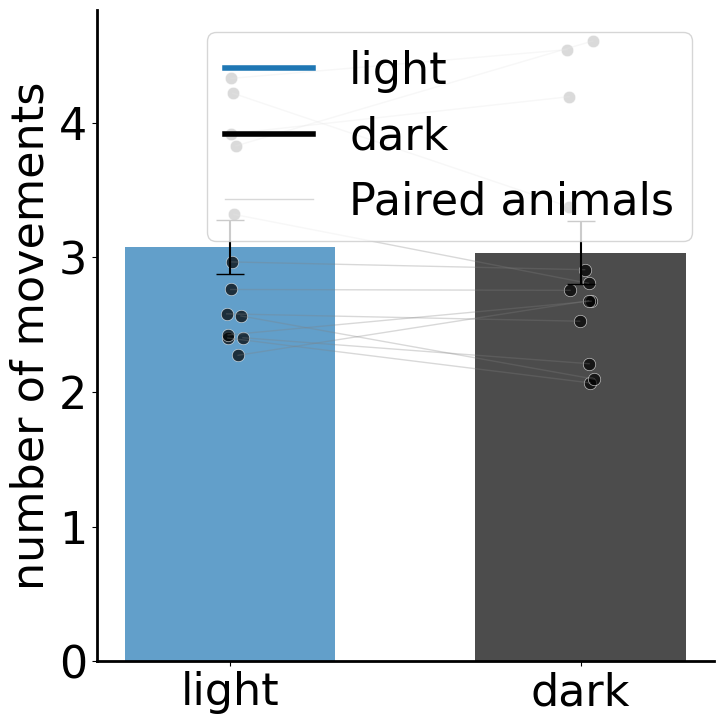


Analysis complete!


In [6]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# Prepare data
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.num_turn>=0]  # Only valid distances

# Split by task
left_data = data[data['task'] == 'oa']
right_data = data[data['task'] == 'oadark']

# Calculate animal-level means
left_animal_means = []
right_animal_means = []

# Dictionary to store animal data for paired testing
animal_data_dict = {}

# Store left data with animal IDs
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['num_turn'].mean()
    left_animal_means.append(animal_dist)
    
    # Store in dictionary for paired testing
    if animal not in animal_data_dict:
        animal_data_dict[animal] = {}
    animal_data_dict[animal]['oa'] = animal_dist

# Store right data with animal IDs
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['num_turn'].mean()
    right_animal_means.append(animal_dist)
    
    # Store in dictionary for paired testing
    if animal not in animal_data_dict:
        animal_data_dict[animal] = {}
    animal_data_dict[animal]['oadark'] = animal_dist

# Perform Wilcoxon signed-rank test
print("=" * 60)
print("WILCOXON SIGNED-RANK TEST - NUMBER OF MOVEMENTS")
print("=" * 60)
print("\nCOMPARISON: OA (light) vs OAdark (dark)")
print("-" * 40)

# Get paired data for animals that have both OA and OAdark measurements
paired_oa_values = []
paired_oadark_values = []
paired_animals = []

for animal in animal_data_dict:
    if 'oa' in animal_data_dict[animal] and 'oadark' in animal_data_dict[animal]:
        paired_oa_values.append(animal_data_dict[animal]['oa'])
        paired_oadark_values.append(animal_data_dict[animal]['oadark'])
        paired_animals.append(animal)

if len(paired_oa_values) > 1 and len(paired_oadark_values) > 1:
    # Perform Wilcoxon signed-rank test
    stat, p_value = wilcoxon(paired_oa_values, paired_oadark_values)
    
    print(f"Number of paired animals: {len(paired_oa_values)}")
    print(f"OA (light) mean: {np.mean(paired_oa_values):.2f} movements")
    print(f"OAdark (dark) mean: {np.mean(paired_oadark_values):.2f} movements")
    print(f"OA (light) median: {np.median(paired_oa_values):.2f} movements")
    print(f"OAdark (dark) median: {np.median(paired_oadark_values):.2f} movements")
    print(f"Wilcoxon statistic: {stat:.3f}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.001:
        print("Result: *** p < 0.001 (Highly significant)")
    elif p_value < 0.01:
        print("Result: ** p < 0.01 (Very significant)")
    elif p_value < 0.05:
        print("Result: * p < 0.05 (Significant)")
    else:
        print("Result: p > 0.05 (Not significant)")
        
    # Print individual animal values
    print("\nIndividual animal values (number of movements):")
    for animal in paired_animals:
        oa_val = animal_data_dict[animal]['oa']
        oadark_val = animal_data_dict[animal]['oadark']
        diff = oa_val - oadark_val
        print(f"  {animal}: OA={oa_val:.2f}, OAdark={oadark_val:.2f}, diff={diff:.2f}")
        
    # Calculate summary statistics
    print(f"\nSummary of differences (OA - OAdark):")
    print(f"  Mean difference: {np.mean([oa - oadark for oa, oadark in zip(paired_oa_values, paired_oadark_values)]):.2f}")
    print(f"  Median difference: {np.median([oa - oadark for oa, oadark in zip(paired_oa_values, paired_oadark_values)]):.2f}")
    print(f"  Range of differences: [{np.min([oa - oadark for oa, oadark in zip(paired_oa_values, paired_oadark_values)]):.2f}, {np.max([oa - oadark for oa, oadark in zip(paired_oa_values, paired_oadark_values)]):.2f}]")
else:
    print("Insufficient paired data for Wilcoxon test")
    print(f"Animals with OA data: {len(left_animal_means)}")
    print(f"Animals with OAdark data: {len(right_animal_means)}")
    print(f"Animals with both: {len(paired_oa_values)}")

# Additional statistics for all animals (including unpaired)
print("\n" + "=" * 60)
print("SUMMARY STATISTICS (ALL ANIMALS)")
print("=" * 60)
print(f"\nOA (light):")
print(f"  n = {len(left_animal_means)} animals")
print(f"  Mean ± SEM = {np.mean(left_animal_means):.2f} ± {np.std(left_animal_means)/np.sqrt(len(left_animal_means)):.2f}")
print(f"  Median = {np.median(left_animal_means):.2f}")
print(f"  Range = [{np.min(left_animal_means):.2f}, {np.max(left_animal_means):.2f}]")
print(f"  Std. Dev. = {np.std(left_animal_means):.2f}")

print(f"\nOAdark (dark):")
print(f"  n = {len(right_animal_means)} animals")
print(f"  Mean ± SEM = {np.mean(right_animal_means):.2f} ± {np.std(right_animal_means)/np.sqrt(len(right_animal_means)):.2f}")
print(f"  Median = {np.median(right_animal_means):.2f}")
print(f"  Range = [{np.min(right_animal_means):.2f}, {np.max(right_animal_means):.2f}]")
print(f"  Std. Dev. = {np.std(right_animal_means):.2f}")

print("\n" + "=" * 60)

# Continue with the original plotting code
# Calculate means and standard errors from animal means
left_mean = np.mean(left_animal_means)  # Changed
right_mean = np.mean(right_animal_means)  # Changed
left_se = np.std(left_animal_means) / np.sqrt(len(left_animal_means))  # Changed
right_se = np.std(right_animal_means) / np.sqrt(len(right_animal_means))  # Changed

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_se, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, right_mean, yerr=right_se, color='black', 
       alpha=0.7, capsize=10, width=0.6, label='dark')

# Jitter settings
jitter_width = 0.04  # Max horizontal spread

# Store point positions for connecting lines
point_positions = {}

# Add individual animal points for left turns with random jitter
for i, animal in enumerate(left_data['animal'].unique()):
    animal_dist = left_data[left_data['animal'] == animal]['num_turn'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)
    
    # Store position for connecting lines
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oa'] = (0 + jitter, animal_dist)

# Add individual animal points for right turns with random jitter
for i, animal in enumerate(right_data['animal'].unique()):
    animal_dist = right_data[right_data['animal'] == animal]['num_turn'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)
    
    # Store position for connecting lines
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oadark'] = (1 + jitter, animal_dist)

# Add connecting lines for paired animals
if len(paired_animals) > 0:
    print(f"\nConnecting lines for {len(paired_animals)} paired animals...")
    for animal in paired_animals:
        if ('oa' in point_positions.get(animal, {}) and 
            'oadark' in point_positions.get(animal, {})):
            x1, y1 = point_positions[animal]['oa']
            x2, y2 = point_positions[animal]['oadark']
            ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=1, zorder=1)

# Customize plot
ax.set_xticks([0, 1])
ax.set_xticklabels(['light', 'dark'])
ax.set_ylabel('number of movements')

# Add legend
legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=4, label='light'),
    Line2D([0], [0], color='black', lw=4, label='dark'),
    Line2D([0], [0], color='gray', alpha=0.3, linewidth=1, label='Paired animals')
]
ax.legend(handles=legend_elements, loc='upper right')

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add significance annotation if significant
if 'p_value' in locals() and p_value < 0.05:
    y_max = max(left_mean + left_se, right_mean + right_se)
    y_pos = y_max + y_max * 0.1
    
    # Determine significance level
    if p_value < 0.001:
        sig_text = '***'
    elif p_value < 0.01:
        sig_text = '**'
    else:
        sig_text = '*'
    
    # Add significance line and text
    ax.plot([0, 1], [y_pos, y_pos], 'k', linewidth=1)
    ax.plot([0, 0], [y_pos, y_pos - y_max * 0.02], 'k', linewidth=1)
    ax.plot([1, 1], [y_pos, y_pos - y_max * 0.02], 'k', linewidth=1)
    ax.text(0.5, y_pos + y_max * 0.02, sig_text, ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Analysis complete!")
print("=" * 60)

J701RT
3.4944965361667393
J701NN
15.84285493490102
J701LT
2.836590430174226
J701RN
8.923304913861955
G8CK1RT
10.490440634746452
G8CK1LT
12.698744753017785
G8CK1TT
2.490058216780829
G8CK1LN
7.582921855110147
G8CKRT
1.9167592575845092
G8CKLT
2.4265895182481785
G8CKTT
9.629089232280322
G8CKRN
3.5690702207623293
G8CKLN
2.3576545535878957


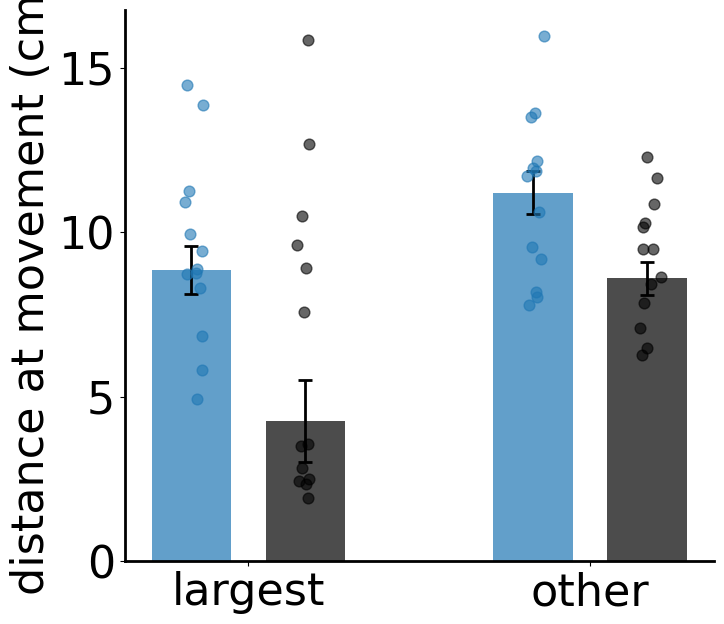

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
oa_data = data[data['task'] == 'oa']
oadark_data = data[data['task'] == 'oadark']

largest_movment_oa_after = oa_data['distance_at_head_turn'].median()
other_movments_oa_after = np.nanmedian(flatten_list_of_arrays(oa_data.distances_at_head_turns.to_list()))

largest_movment_oadark_after = oadark_data['distance_at_head_turn'].median()
other_movments_oadark_after = np.nanmedian(flatten_list_of_arrays(oadark_data.distances_at_head_turns.to_list()))

# Calculate animal-level medians for plotting
oa_animal_largest = []
oa_animal_other = []
oadark_animal_largest = []
oadark_animal_other = []

for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    after_median = animal_data['distance_at_head_turn'].median()
    other_movments_after_median = np.nanmedian(flatten_list_of_arrays(animal_data.distances_at_head_turns.to_list()))
    oa_animal_largest.append(after_median)
    oa_animal_other.append(other_movments_after_median)

for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    after_median = animal_data['distance_at_head_turn'].median()
    other_movments_after_median = np.nanmedian(flatten_list_of_arrays(animal_data.distances_at_head_turns.to_list()))
    print(animal)
    oadark_animal_largest.append(after_median)
    print(after_median)
    oadark_animal_other.append(other_movments_after_median)

# Calculate SEM for error bars
oa_largest_sem = np.std(oa_animal_largest) / np.sqrt(len(oa_animal_largest))
oa_other_sem = np.std(oa_animal_other) / np.sqrt(len(oa_animal_other))
oadark_largest_sem = np.std(oadark_animal_largest) / np.sqrt(len(oadark_animal_largest))
oadark_other_sem = np.std(oadark_animal_other) / np.sqrt(len(oadark_animal_other))

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 7))

# Bar positions
x_pos = np.array([0, 3, 1, 4])  # OA largest, OA other, OAdark largest, OAdark other
bar_width = 0.7

# Bar heights (medians)
heights = [
    largest_movment_oa_after,
    other_movments_oa_after,
    largest_movment_oadark_after,
    other_movments_oadark_after
]

# SEM values for error bars
errors = [oa_largest_sem, oa_other_sem, oadark_largest_sem, oadark_other_sem]

# Colors
colors = ['tab:blue', 'tab:blue', 'black', 'black']

# Create bars
bars = ax.bar(x_pos, heights, bar_width, color=colors, alpha=0.7, 
              yerr=errors, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

# Add individual animal points
# OA largest movements
for i, value in enumerate(oa_animal_largest):
    ax.scatter(x_pos[0] + np.random.normal(0, 0.05), value, color='tab:blue', alpha=0.6, s=60, zorder=3)

# OA other movements
for i, value in enumerate(oa_animal_other):
    ax.scatter(x_pos[1] + np.random.normal(0, 0.05), value, color='tab:blue', alpha=0.6, s=60, zorder=3)

# OAdark largest movements
for i, value in enumerate(oadark_animal_largest):
    ax.scatter(x_pos[2] + np.random.normal(0, 0.05), value, color='black', alpha=0.6, s=60, zorder=3)

# OAdark other movements
for i, value in enumerate(oadark_animal_other):
    ax.scatter(x_pos[3] + np.random.normal(0, 0.05), value, color='black', alpha=0.6, s=60, zorder=3)

# Customize the plot
ax.set_xticks(np.array([.5, 3.5]),['largest','other'])

ax.set_ylabel('distance at movement (cm)')



# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

STATISTICAL TESTS (Paired and Unpaired)

1. TEST FOR LARGEST MOVEMENTS (OA vs OAdark):
----------------------------------------
Total animals in OA (largest): 13
Total animals in OAdark (largest): 13
OA median (largest): 8.87
OAdark median (largest): 3.57

   A. PAIRED TEST (Wilcoxon signed-rank):
   Number of paired animals: 13
   Wilcoxon statistic: 17.000
   P-value: 0.047852
   Result: * p < 0.05

   B. UNPAIRED TEST (Mann-Whitney U):
   Mann-Whitney U statistic: 118.000
   P-value: 0.090587
   Result: p > 0.05 (ns)

2. TEST FOR OTHER MOVEMENTS (OA vs OAdark):
----------------------------------------
Total animals in OA (other): 13
Total animals in OAdark (other): 13
OA median (other): 11.70
OAdark median (other): 9.51

   A. PAIRED TEST (Wilcoxon signed-rank):
   Number of paired animals: 13
   Wilcoxon statistic: 19.000
   P-value: 0.068115
   Result: p > 0.05 (ns)

   B. UNPAIRED TEST (Mann-Whitney U):
   Mann-Whitney U statistic: 122.000
   P-value: 0.057770
   Result: p > 0.05

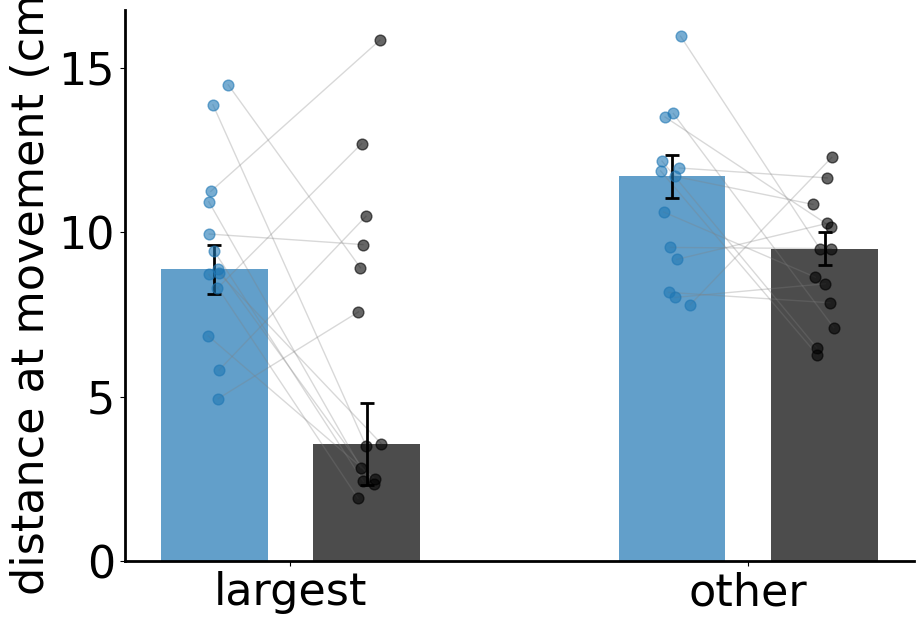


Analysis complete!


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, mannwhitneyu

# Your existing data processing code
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
oa_data = data[data['task'] == 'oa']
oadark_data = data[data['task'] == 'oadark']

largest_movment_oa_after = oa_data['distance_at_head_turn'].median()
other_movments_oa_after = np.nanmedian(flatten_list_of_arrays(oa_data.distances_at_head_turns.to_list()))

largest_movment_oadark_after = oadark_data['distance_at_head_turn'].median()
other_movments_oadark_after = np.nanmedian(flatten_list_of_arrays(oadark_data.distances_at_head_turns.to_list()))

# Calculate animal-level medians for plotting AND testing
oa_animal_largest = []
oa_animal_other = []
oadark_animal_largest = []
oadark_animal_other = []

# Dictionary to store animal-level data for paired testing and plotting
animal_data_dict = {}
animal_ids = []

# Process OA data
for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    after_median = animal_data['distance_at_head_turn'].median()
    other_movments_after_median = np.nanmedian(flatten_list_of_arrays(animal_data.distances_at_head_turns.to_list()))
    oa_animal_largest.append(after_median)
    oa_animal_other.append(other_movments_after_median)
    
    # Store in dictionary for paired testing
    if animal not in animal_data_dict:
        animal_data_dict[animal] = {'oa': {}, 'oadark': {}}
        animal_ids.append(animal)
    animal_data_dict[animal]['oa']['largest'] = after_median
    animal_data_dict[animal]['oa']['other'] = other_movments_after_median

# Process OAdark data
for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    after_median = animal_data['distance_at_head_turn'].median()
    other_movments_after_median = np.nanmedian(flatten_list_of_arrays(animal_data.distances_at_head_turns.to_list()))
    
    oadark_animal_largest.append(after_median)
    oadark_animal_other.append(other_movments_after_median)
    
    # Store in dictionary for paired testing
    if animal not in animal_data_dict:
        animal_data_dict[animal] = {'oa': {}, 'oadark': {}}
        animal_ids.append(animal)
    animal_data_dict[animal]['oadark']['largest'] = after_median
    animal_data_dict[animal]['oadark']['other'] = other_movments_after_median

# Perform statistical tests
print("=" * 70)
print("STATISTICAL TESTS (Paired and Unpaired)")
print("=" * 70)

# Test 1: Largest movements comparison (OA vs OAdark)
print("\n1. TEST FOR LARGEST MOVEMENTS (OA vs OAdark):")
print("-" * 40)

# Get ALL data for largest movements (for unpaired test)
all_oa_largest = oa_animal_largest
all_oadark_largest = oadark_animal_largest

print(f"Total animals in OA (largest): {len(all_oa_largest)}")
print(f"Total animals in OAdark (largest): {len(all_oadark_largest)}")
print(f"OA median (largest): {np.median(all_oa_largest):.2f}")
print(f"OAdark median (largest): {np.median(all_oadark_largest):.2f}")

# Get PAIRED data for largest movements (for paired test)
paired_largest_oa = []
paired_largest_oadark = []
paired_animals_largest = []

for animal in animal_data_dict:
    if 'oa' in animal_data_dict[animal] and 'oadark' in animal_data_dict[animal]:
        if 'largest' in animal_data_dict[animal]['oa'] and 'largest' in animal_data_dict[animal]['oadark']:
            paired_largest_oa.append(animal_data_dict[animal]['oa']['largest'])
            paired_largest_oadark.append(animal_data_dict[animal]['oadark']['largest'])
            paired_animals_largest.append(animal)

# Perform Paired Test (Wilcoxon signed-rank)
print("\n   A. PAIRED TEST (Wilcoxon signed-rank):")
if len(paired_largest_oa) > 1 and len(paired_largest_oadark) > 1:
    stat, p_value = wilcoxon(paired_largest_oa, paired_largest_oadark,alternative='two-sided')
    print(f"   Number of paired animals: {len(paired_largest_oa)}")
    print(f"   Wilcoxon statistic: {stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    if p_value < 0.001:
        print("   Result: *** p < 0.001")
    elif p_value < 0.01:
        print("   Result: ** p < 0.01")
    elif p_value < 0.05:
        print("   Result: * p < 0.05")
    else:
        print("   Result: p > 0.05 (ns)")
else:
    print("   Insufficient paired data (need at least 2 pairs)")

# Perform Unpaired Test (Mann-Whitney U)
print("\n   B. UNPAIRED TEST (Mann-Whitney U):")
if len(all_oa_largest) > 1 and len(all_oadark_largest) > 1:
    stat, p_value = mannwhitneyu(all_oa_largest, all_oadark_largest, alternative='two-sided')
    print(f"   Mann-Whitney U statistic: {stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    if p_value < 0.001:
        print("   Result: *** p < 0.001")
    elif p_value < 0.01:
        print("   Result: ** p < 0.01")
    elif p_value < 0.05:
        print("   Result: * p < 0.05")
    else:
        print("   Result: p > 0.05 (ns)")
else:
    print("   Insufficient data for unpaired test")

# Test 2: Other movements comparison (OA vs OAdark)
print("\n2. TEST FOR OTHER MOVEMENTS (OA vs OAdark):")
print("-" * 40)

# Get ALL data for other movements (for unpaired test)
all_oa_other = oa_animal_other
all_oadark_other = oadark_animal_other

print(f"Total animals in OA (other): {len(all_oa_other)}")
print(f"Total animals in OAdark (other): {len(all_oadark_other)}")
print(f"OA median (other): {np.median(all_oa_other):.2f}")
print(f"OAdark median (other): {np.median(all_oadark_other):.2f}")

# Get PAIRED data for other movements (for paired test)
paired_other_oa = []
paired_other_oadark = []
paired_animals_other = []

for animal in animal_data_dict:
    if 'oa' in animal_data_dict[animal] and 'oadark' in animal_data_dict[animal]:
        if 'other' in animal_data_dict[animal]['oa'] and 'other' in animal_data_dict[animal]['oadark']:
            paired_other_oa.append(animal_data_dict[animal]['oa']['other'])
            paired_other_oadark.append(animal_data_dict[animal]['oadark']['other'])
            paired_animals_other.append(animal)

# Perform Paired Test (Wilcoxon signed-rank)
print("\n   A. PAIRED TEST (Wilcoxon signed-rank):")
if len(paired_other_oa) > 1 and len(paired_other_oadark) > 1:
    stat, p_value = wilcoxon(paired_other_oa, paired_other_oadark)
    print(f"   Number of paired animals: {len(paired_other_oa)}")
    print(f"   Wilcoxon statistic: {stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    if p_value < 0.001:
        print("   Result: *** p < 0.001")
    elif p_value < 0.01:
        print("   Result: ** p < 0.01")
    elif p_value < 0.05:
        print("   Result: * p < 0.05")
    else:
        print("   Result: p > 0.05 (ns)")
else:
    print("   Insufficient paired data (need at least 2 pairs)")

# Perform Unpaired Test (Mann-Whitney U)
print("\n   B. UNPAIRED TEST (Mann-Whitney U):")
if len(all_oa_other) > 1 and len(all_oadark_other) > 1:
    stat, p_value = mannwhitneyu(all_oa_other, all_oadark_other, alternative='two-sided')
    print(f"   Mann-Whitney U statistic: {stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    if p_value < 0.001:
        print("   Result: *** p < 0.001")
    elif p_value < 0.01:
        print("   Result: ** p < 0.01")
    elif p_value < 0.05:
        print("   Result: * p < 0.05")
    else:
        print("   Result: p > 0.05 (ns)")
else:
    print("   Insufficient data for unpaired test")

# Within-condition comparisons (using all available data)
print("\n" + "=" * 70)
print("WITHIN-CONDITION COMPARISONS")
print("=" * 70)

# Test 3: Within OA condition (largest vs other)
print("\n3. WITHIN OA CONDITION (largest vs other movements):")
print("-" * 40)

if len(all_oa_largest) > 1 and len(all_oa_other) > 1:
    # Get the minimum length for paired comparison
    min_length = min(len(all_oa_largest), len(all_oa_other))
    if min_length > 1:
        # Check if we have the same animals for both (paired)
        # For simplicity, we'll use the first min_length elements
        # (assuming lists are in same order)
        print(f"Total animals (largest): {len(all_oa_largest)}")
        print(f"Total animals (other): {len(all_oa_other)}")
        
        # Paired test (if we assume same animals in same order)
        print("\n   A. PAIRED TEST (assuming same animals):")
        stat, p_value = wilcoxon(all_oa_largest[:min_length], all_oa_other[:min_length])
        print(f"   Number of animals: {min_length}")
        print(f"   Wilcoxon statistic: {stat:.3f}")
        print(f"   P-value: {p_value:.6f}")
        if p_value < 0.001:
            print("   Result: *** p < 0.001")
        elif p_value < 0.01:
            print("   Result: ** p < 0.01")
        elif p_value < 0.05:
            print("   Result: * p < 0.05")
        else:
            print("   Result: p > 0.05 (ns)")
        
        # Unpaired test (using all data)
        print("\n   B. UNPAIRED TEST (using all data):")
        stat, p_value = mannwhitneyu(all_oa_largest, all_oa_other, alternative='two-sided')
        print(f"   Mann-Whitney U statistic: {stat:.3f}")
        print(f"   P-value: {p_value:.6f}")
        if p_value < 0.001:
            print("   Result: *** p < 0.001")
        elif p_value < 0.01:
            print("   Result: ** p < 0.01")
        elif p_value < 0.05:
            print("   Result: * p < 0.05")
        else:
            print("   Result: p > 0.05 (ns)")
    else:
        print("Insufficient data for within-condition test")
else:
    print("Insufficient data for within-condition test")

# Test 4: Within OAdark condition (largest vs other)
print("\n4. WITHIN OAdark CONDITION (largest vs other movements):")
print("-" * 40)

if len(all_oadark_largest) > 1 and len(all_oadark_other) > 1:
    # Get the minimum length for paired comparison
    min_length = min(len(all_oadark_largest), len(all_oadark_other))
    if min_length > 1:
        print(f"Total animals (largest): {len(all_oadark_largest)}")
        print(f"Total animals (other): {len(all_oadark_other)}")
        
        # Paired test (if we assume same animals in same order)
        print("\n   A. PAIRED TEST (assuming same animals):")
        stat, p_value = wilcoxon(all_oadark_largest[:min_length], all_oadark_other[:min_length])
        print(f"   Number of animals: {min_length}")
        print(f"   Wilcoxon statistic: {stat:.3f}")
        print(f"   P-value: {p_value:.6f}")
        if p_value < 0.001:
            print("   Result: *** p < 0.001")
        elif p_value < 0.01:
            print("   Result: ** p < 0.01")
        elif p_value < 0.05:
            print("   Result: * p < 0.05")
        else:
            print("   Result: p > 0.05 (ns)")
        
        # Unpaired test (using all data)
        print("\n   B. UNPAIRED TEST (using all data):")
        stat, p_value = mannwhitneyu(all_oadark_largest, all_oadark_other, alternative='two-sided')
        print(f"   Mann-Whitney U statistic: {stat:.3f}")
        print(f"   P-value: {p_value:.6f}")
        if p_value < 0.001:
            print("   Result: *** p < 0.001")
        elif p_value < 0.01:
            print("   Result: ** p < 0.01")
        elif p_value < 0.05:
            print("   Result: * p < 0.05")
        else:
            print("   Result: p > 0.05 (ns)")
    else:
        print("Insufficient data for within-condition test")
else:
    print("Insufficient data for within-condition test")

print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(f"\nLargest movements:")
print(f"  OA: n={len(all_oa_largest)}, median={np.median(all_oa_largest):.2f}, mean±SEM={np.mean(all_oa_largest):.2f}±{np.std(all_oa_largest)/np.sqrt(len(all_oa_largest)):.2f}")
print(f"  OAdark: n={len(all_oadark_largest)}, median={np.median(all_oadark_largest):.2f}, mean±SEM={np.mean(all_oadark_largest):.2f}±{np.std(all_oadark_largest)/np.sqrt(len(all_oadark_largest)):.2f}")

print(f"\nOther movements:")
print(f"  OA: n={len(all_oa_other)}, median={np.median(all_oa_other):.2f}, mean±SEM={np.mean(all_oa_other):.2f}±{np.std(all_oa_other)/np.sqrt(len(all_oa_other)):.2f}")
print(f"  OAdark: n={len(all_oadark_other)}, median={np.median(all_oadark_other):.2f}, mean±SEM={np.mean(all_oadark_other):.2f}±{np.std(all_oadark_other)/np.sqrt(len(all_oadark_other)):.2f}")

print(f"\nPaired animals:")
print(f"  Largest movements: {len(paired_animals_largest)} animals")
print(f"  Other movements: {len(paired_animals_other)} animals")

print("\n" + "=" * 70)

# Plotting code (same as before, with connected lines)
# Calculate SEM for error bars
oa_largest_sem = np.std(all_oa_largest) / np.sqrt(len(all_oa_largest))
oa_other_sem = np.std(all_oa_other) / np.sqrt(len(all_oa_other))
oadark_largest_sem = np.std(all_oadark_largest) / np.sqrt(len(all_oadark_largest))
oadark_other_sem = np.std(all_oadark_other) / np.sqrt(len(all_oadark_other))

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Bar positions
x_pos = np.array([0, 3, 1, 4])  # OA largest, OA other, OAdark largest, OAdark other
bar_width = 0.7

# Bar heights (medians)
heights = [
    np.median(all_oa_largest),
    np.median(all_oa_other),
    np.median(all_oadark_largest),
    np.median(all_oadark_other)
]

# SEM values for error bars
errors = [oa_largest_sem, oa_other_sem, oadark_largest_sem, oadark_other_sem]

# Colors
colors = ['tab:blue', 'tab:blue', 'black', 'black']

# Create bars
bars = ax.bar(x_pos, heights, bar_width, color=colors, alpha=0.7, 
              yerr=errors, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

# Add individual animal points
point_positions = {}

# OA largest movements
for i, animal in enumerate(oa_data['animal'].unique()):
    animal_data = oa_data[oa_data['animal'] == animal]
    value = animal_data['distance_at_head_turn'].median()
    x = x_pos[0] + np.random.normal(0, 0.05)
    ax.scatter(x, value, color='tab:blue', alpha=0.6, s=60, zorder=3)
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oa_largest'] = (x, value)

# OA other movements
for i, animal in enumerate(oa_data['animal'].unique()):
    animal_data = oa_data[oa_data['animal'] == animal]
    value = np.nanmedian(flatten_list_of_arrays(animal_data.distances_at_head_turns.to_list()))
    x = x_pos[1] + np.random.normal(0, 0.05)
    ax.scatter(x, value, color='tab:blue', alpha=0.6, s=60, zorder=3)
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oa_other'] = (x, value)

# OAdark largest movements
for i, animal in enumerate(oadark_data['animal'].unique()):
    animal_data = oadark_data[oadark_data['animal'] == animal]
    value = animal_data['distance_at_head_turn'].median()
    x = x_pos[2] + np.random.normal(0, 0.05)
    ax.scatter(x, value, color='black', alpha=0.6, s=60, zorder=3)
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oadark_largest'] = (x, value)

# OAdark other movements
for i, animal in enumerate(oadark_data['animal'].unique()):
    animal_data = oadark_data[oadark_data['animal'] == animal]
    value = np.nanmedian(flatten_list_of_arrays(animal_data.distances_at_head_turns.to_list()))
    x = x_pos[3] + np.random.normal(0, 0.05)
    ax.scatter(x, value, color='black', alpha=0.6, s=60, zorder=3)
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oadark_other'] = (x, value)

# ADD CONNECTED LINES FOR PAIRED ANIMALS
# For largest movements (OA vs OAdark)
print(f"\nConnecting lines for {len(paired_animals_largest)} paired animals in largest movements...")
for animal in paired_animals_largest:
    if ('oa_largest' in point_positions.get(animal, {}) and 
        'oadark_largest' in point_positions.get(animal, {})):
        x1, y1 = point_positions[animal]['oa_largest']
        x2, y2 = point_positions[animal]['oadark_largest']
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=1, zorder=1)

# For other movements (OA vs OAdark)
print(f"Connecting lines for {len(paired_animals_other)} paired animals in other movements...")
for animal in paired_animals_other:
    if ('oa_other' in point_positions.get(animal, {}) and 
        'oadark_other' in point_positions.get(animal, {})):
        x1, y1 = point_positions[animal]['oa_other']
        x2, y2 = point_positions[animal]['oadark_other']
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=1, zorder=1)

# Customize the plot
ax.set_xticks(np.array([.5, 3.5]))
ax.set_xticklabels(['largest','other'])

ax.set_ylabel('distance at movement (cm)')

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend for the lines
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', alpha=0.3, linewidth=1, label='Paired animals'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', 
           markersize=10, label='OA condition'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
           markersize=10, label='OAdark condition')
]


plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Analysis complete!")
print("=" * 70)

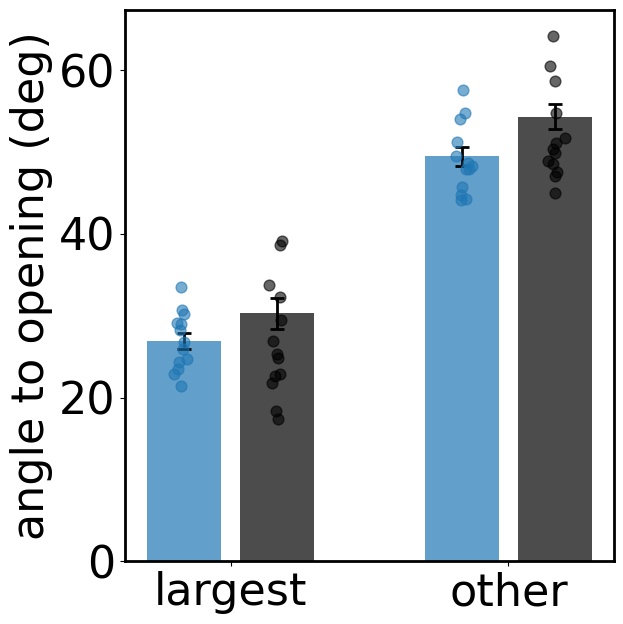

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
oa_data = data[data['task'] == 'oa']
oadark_data = data[data['task'] == 'oadark']

largest_movment_oa_after = oa_data['angle_after_head_turn'].mean()
other_movments_oa_after = np.nanmean(flatten_list_of_arrays(oa_data.angles_after_head_turns.to_list()))

largest_movment_oadark_after = oadark_data['angle_after_head_turn'].mean()
other_movments_oadark_after = np.nanmean(flatten_list_of_arrays(oadark_data.angles_after_head_turns.to_list()))

# Calculate animal-level means for plotting
oa_animal_largest = []
oa_animal_other = []
oadark_animal_largest = []
oadark_animal_other = []

for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    after_mean = animal_data['angle_after_head_turn'].mean()
    other_movments_after_mean = np.nanmean(flatten_list_of_arrays(animal_data.angles_after_head_turns.to_list()))
    oa_animal_largest.append(after_mean)
    oa_animal_other.append(other_movments_after_mean)

for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    after_mean = animal_data['angle_after_head_turn'].mean()
    other_movments_after_mean = np.nanmean(flatten_list_of_arrays(animal_data.angles_after_head_turns.to_list()))
    oadark_animal_largest.append(after_mean)
    oadark_animal_other.append(other_movments_after_mean)

# Calculate SEM for error bars
oa_largest_sem = np.std(oa_animal_largest) / np.sqrt(len(oa_animal_largest))
oa_other_sem = np.std(oa_animal_other) / np.sqrt(len(oa_animal_other))
oadark_largest_sem = np.std(oadark_animal_largest) / np.sqrt(len(oadark_animal_largest))
oadark_other_sem = np.std(oadark_animal_other) / np.sqrt(len(oadark_animal_other))

# Set up the plot
fig, ax = plt.subplots(figsize=(7, 7))

# Bar positions
x_pos = np.array([0, 3, 1, 4])  # OA largest, OA other, OAdark largest, OAdark other
bar_width = 0.8

# Bar heights (means)
heights = [
    largest_movment_oa_after,
    other_movments_oa_after,
    largest_movment_oadark_after,
    other_movments_oadark_after
]

# SEM values for error bars
errors = [oa_largest_sem, oa_other_sem, oadark_largest_sem, oadark_other_sem]

# Colors
colors = ['tab:blue', 'tab:blue', 'black', 'black']

# Create bars
bars = ax.bar(x_pos, heights, bar_width, color=colors, alpha=0.7, 
              yerr=errors, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

# Add individual animal points
# OA largest movements
for i, value in enumerate(oa_animal_largest):
    ax.scatter(x_pos[0] + np.random.normal(0, 0.05), value, color='tab:blue', alpha=0.6, s=60, zorder=3)

# OA other movements
for i, value in enumerate(oa_animal_other):
    ax.scatter(x_pos[1] + np.random.normal(0, 0.05), value, color='tab:blue', alpha=0.6, s=60, zorder=3)

# OAdark largest movements
for i, value in enumerate(oadark_animal_largest):
    ax.scatter(x_pos[2] + np.random.normal(0, 0.05), value, color='black', alpha=0.6, s=60, zorder=3)

# OAdark other movements
for i, value in enumerate(oadark_animal_other):
    ax.scatter(x_pos[3] + np.random.normal(0, 0.05), value, color='black', alpha=0.6, s=60, zorder=3)

# Customize the plot
ax.set_xticks(np.array([.5, 3.5]),['largest','other'])

ax.set_ylabel('angle to opening (deg)')

# Add legend for movement types
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:blue', alpha=0.7, label='OA'),
    Patch(facecolor='black', alpha=0.7, label='OAdark'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Individual Animals')
]




plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\angle_to_oppening_mean.pdf", dpi=300, transparent=True)
plt.show()

STATISTICAL TESTS FOR ANGLE TO OPENING (Paired and Unpaired)

1. TEST FOR LARGEST MOVEMENTS (OA vs OAdark):
----------------------------------------
Total animals in OA (largest): 13
Total animals in OAdark (largest): 13
OA mean (largest): 26.93
OAdark mean (largest): 27.17

   A. PAIRED TEST (Wilcoxon signed-rank):
   Number of paired animals: 13
   Wilcoxon statistic: 44.000
   P-value: 0.946045
   Result: p > 0.05 (ns)

   B. UNPAIRED TEST (Mann-Whitney U):
   Mann-Whitney U statistic: 87.000
   P-value: 0.918309
   Result: p > 0.05 (ns)

2. TEST FOR OTHER MOVEMENTS (OA vs OAdark):
----------------------------------------
Total animals in OA (other): 13
Total animals in OAdark (other): 13
OA mean (other): 49.17
OAdark mean (other): 52.19

   A. PAIRED TEST (Wilcoxon signed-rank):
   Number of paired animals: 13
   Wilcoxon statistic: 24.000
   P-value: 0.146484
   Result: p > 0.05 (ns)

   B. UNPAIRED TEST (Mann-Whitney U):
   Mann-Whitney U statistic: 55.000
   P-value: 0.136967
  

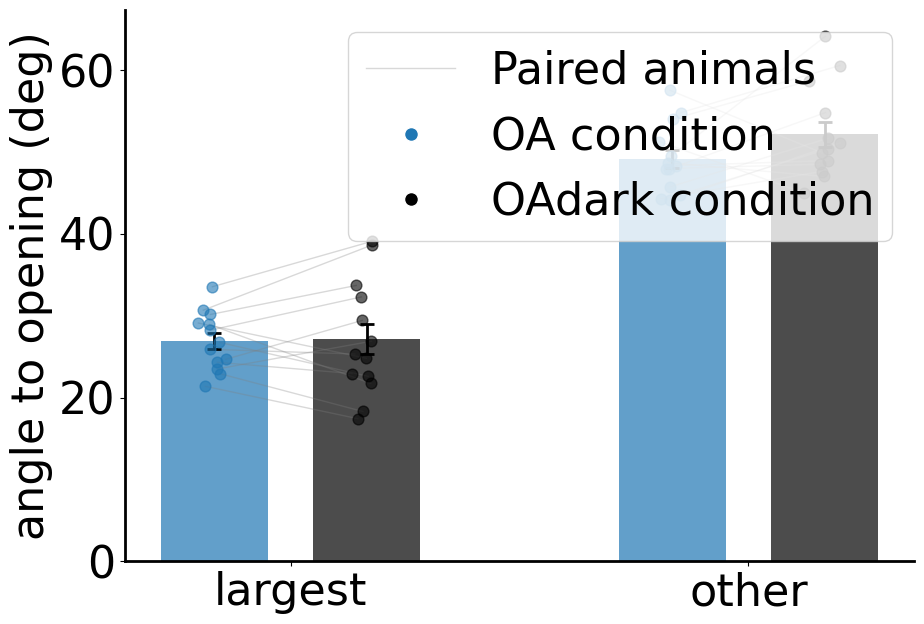


Angle to opening analysis complete!


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, mannwhitneyu

# Your data processing code
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
oa_data = data[data['task'] == 'oa']
oadark_data = data[data['task'] == 'oadark']

largest_movment_oa_after = oa_data['angle_after_head_turn'].mean()
other_movments_oa_after = np.nanmean(flatten_list_of_arrays(oa_data.angles_after_head_turns.to_list()))

largest_movment_oadark_after = oadark_data['angle_after_head_turn'].mean()
other_movments_oadark_after = np.nanmean(flatten_list_of_arrays(oadark_data.angles_after_head_turns.to_list()))

# Calculate animal-level means for plotting AND testing
oa_animal_largest = []
oa_animal_other = []
oadark_animal_largest = []
oadark_animal_other = []

# Dictionary to store animal-level data for paired testing and plotting
animal_data_dict = {}
animal_ids = []

# Process OA data
for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    after_mean = animal_data['angle_after_head_turn'].mean()
    other_movments_after_mean = np.nanmean(flatten_list_of_arrays(animal_data.angles_after_head_turns.to_list()))
    oa_animal_largest.append(after_mean)
    oa_animal_other.append(other_movments_after_mean)
    
    # Store in dictionary for paired testing
    if animal not in animal_data_dict:
        animal_data_dict[animal] = {'oa': {}, 'oadark': {}}
        animal_ids.append(animal)
    animal_data_dict[animal]['oa']['largest'] = after_mean
    animal_data_dict[animal]['oa']['other'] = other_movments_after_mean

# Process OAdark data
for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    after_mean = animal_data['angle_after_head_turn'].mean()
    other_movments_after_mean = np.nanmean(flatten_list_of_arrays(animal_data.angles_after_head_turns.to_list()))
    
    oadark_animal_largest.append(after_mean)
    oadark_animal_other.append(other_movments_after_mean)
    
    # Store in dictionary for paired testing
    if animal not in animal_data_dict:
        animal_data_dict[animal] = {'oa': {}, 'oadark': {}}
        animal_ids.append(animal)
    animal_data_dict[animal]['oadark']['largest'] = after_mean
    animal_data_dict[animal]['oadark']['other'] = other_movments_after_mean

# Perform statistical tests
print("=" * 70)
print("STATISTICAL TESTS FOR ANGLE TO OPENING (Paired and Unpaired)")
print("=" * 70)

# Test 1: Largest movements comparison (OA vs OAdark)
print("\n1. TEST FOR LARGEST MOVEMENTS (OA vs OAdark):")
print("-" * 40)

# Get ALL data for largest movements (for unpaired test)
all_oa_largest = oa_animal_largest
all_oadark_largest = oadark_animal_largest

print(f"Total animals in OA (largest): {len(all_oa_largest)}")
print(f"Total animals in OAdark (largest): {len(all_oadark_largest)}")
print(f"OA mean (largest): {np.mean(all_oa_largest):.2f}")
print(f"OAdark mean (largest): {np.mean(all_oadark_largest):.2f}")

# Get PAIRED data for largest movements (for paired test)
paired_largest_oa = []
paired_largest_oadark = []
paired_animals_largest = []

for animal in animal_data_dict:
    if 'oa' in animal_data_dict[animal] and 'oadark' in animal_data_dict[animal]:
        if 'largest' in animal_data_dict[animal]['oa'] and 'largest' in animal_data_dict[animal]['oadark']:
            paired_largest_oa.append(animal_data_dict[animal]['oa']['largest'])
            paired_largest_oadark.append(animal_data_dict[animal]['oadark']['largest'])
            paired_animals_largest.append(animal)

# Perform Paired Test (Wilcoxon signed-rank)
print("\n   A. PAIRED TEST (Wilcoxon signed-rank):")
if len(paired_largest_oa) > 1 and len(paired_largest_oadark) > 1:
    stat, p_value = wilcoxon(paired_largest_oa, paired_largest_oadark, alternative='two-sided')
    print(f"   Number of paired animals: {len(paired_largest_oa)}")
    print(f"   Wilcoxon statistic: {stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    if p_value < 0.001:
        print("   Result: *** p < 0.001")
    elif p_value < 0.01:
        print("   Result: ** p < 0.01")
    elif p_value < 0.05:
        print("   Result: * p < 0.05")
    else:
        print("   Result: p > 0.05 (ns)")
else:
    print("   Insufficient paired data (need at least 2 pairs)")

# Perform Unpaired Test (Mann-Whitney U)
print("\n   B. UNPAIRED TEST (Mann-Whitney U):")
if len(all_oa_largest) > 1 and len(all_oadark_largest) > 1:
    stat, p_value = mannwhitneyu(all_oa_largest, all_oadark_largest, alternative='two-sided')
    print(f"   Mann-Whitney U statistic: {stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    if p_value < 0.001:
        print("   Result: *** p < 0.001")
    elif p_value < 0.01:
        print("   Result: ** p < 0.01")
    elif p_value < 0.05:
        print("   Result: * p < 0.05")
    else:
        print("   Result: p > 0.05 (ns)")
else:
    print("   Insufficient data for unpaired test")

# Test 2: Other movements comparison (OA vs OAdark)
print("\n2. TEST FOR OTHER MOVEMENTS (OA vs OAdark):")
print("-" * 40)

# Get ALL data for other movements (for unpaired test)
all_oa_other = oa_animal_other
all_oadark_other = oadark_animal_other

print(f"Total animals in OA (other): {len(all_oa_other)}")
print(f"Total animals in OAdark (other): {len(all_oadark_other)}")
print(f"OA mean (other): {np.mean(all_oa_other):.2f}")
print(f"OAdark mean (other): {np.mean(all_oadark_other):.2f}")

# Get PAIRED data for other movements (for paired test)
paired_other_oa = []
paired_other_oadark = []
paired_animals_other = []

for animal in animal_data_dict:
    if 'oa' in animal_data_dict[animal] and 'oadark' in animal_data_dict[animal]:
        if 'other' in animal_data_dict[animal]['oa'] and 'other' in animal_data_dict[animal]['oadark']:
            paired_other_oa.append(animal_data_dict[animal]['oa']['other'])
            paired_other_oadark.append(animal_data_dict[animal]['oadark']['other'])
            paired_animals_other.append(animal)

# Perform Paired Test (Wilcoxon signed-rank)
print("\n   A. PAIRED TEST (Wilcoxon signed-rank):")
if len(paired_other_oa) > 1 and len(paired_other_oadark) > 1:
    stat, p_value = wilcoxon(paired_other_oa, paired_other_oadark)
    print(f"   Number of paired animals: {len(paired_other_oa)}")
    print(f"   Wilcoxon statistic: {stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    if p_value < 0.001:
        print("   Result: *** p < 0.001")
    elif p_value < 0.01:
        print("   Result: ** p < 0.01")
    elif p_value < 0.05:
        print("   Result: * p < 0.05")
    else:
        print("   Result: p > 0.05 (ns)")
else:
    print("   Insufficient paired data (need at least 2 pairs)")

# Perform Unpaired Test (Mann-Whitney U)
print("\n   B. UNPAIRED TEST (Mann-Whitney U):")
if len(all_oa_other) > 1 and len(all_oadark_other) > 1:
    stat, p_value = mannwhitneyu(all_oa_other, all_oadark_other, alternative='two-sided')
    print(f"   Mann-Whitney U statistic: {stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    if p_value < 0.001:
        print("   Result: *** p < 0.001")
    elif p_value < 0.01:
        print("   Result: ** p < 0.01")
    elif p_value < 0.05:
        print("   Result: * p < 0.05")
    else:
        print("   Result: p > 0.05 (ns)")
else:
    print("   Insufficient data for unpaired test")

# Within-condition comparisons (using all available data)
print("\n" + "=" * 70)
print("WITHIN-CONDITION COMPARISONS")
print("=" * 70)

# Test 3: Within OA condition (largest vs other)
print("\n3. WITHIN OA CONDITION (largest vs other movements):")
print("-" * 40)

if len(all_oa_largest) > 1 and len(all_oa_other) > 1:
    # Get the minimum length for paired comparison
    min_length = min(len(all_oa_largest), len(all_oa_other))
    if min_length > 1:
        print(f"Total animals (largest): {len(all_oa_largest)}")
        print(f"Total animals (other): {len(all_oa_other)}")
        
        # Paired test (if we assume same animals in same order)
        print("\n   A. PAIRED TEST (assuming same animals):")
        stat, p_value = wilcoxon(all_oa_largest[:min_length], all_oa_other[:min_length])
        print(f"   Number of animals: {min_length}")
        print(f"   Wilcoxon statistic: {stat:.3f}")
        print(f"   P-value: {p_value:.6f}")
        if p_value < 0.001:
            print("   Result: *** p < 0.001")
        elif p_value < 0.01:
            print("   Result: ** p < 0.01")
        elif p_value < 0.05:
            print("   Result: * p < 0.05")
        else:
            print("   Result: p > 0.05 (ns)")
        
        # Unpaired test (using all data)
        print("\n   B. UNPAIRED TEST (using all data):")
        stat, p_value = mannwhitneyu(all_oa_largest, all_oa_other, alternative='two-sided')
        print(f"   Mann-Whitney U statistic: {stat:.3f}")
        print(f"   P-value: {p_value:.6f}")
        if p_value < 0.001:
            print("   Result: *** p < 0.001")
        elif p_value < 0.01:
            print("   Result: ** p < 0.01")
        elif p_value < 0.05:
            print("   Result: * p < 0.05")
        else:
            print("   Result: p > 0.05 (ns)")
    else:
        print("Insufficient data for within-condition test")
else:
    print("Insufficient data for within-condition test")

# Test 4: Within OAdark condition (largest vs other)
print("\n4. WITHIN OAdark CONDITION (largest vs other movements):")
print("-" * 40)

if len(all_oadark_largest) > 1 and len(all_oadark_other) > 1:
    # Get the minimum length for paired comparison
    min_length = min(len(all_oadark_largest), len(all_oadark_other))
    if min_length > 1:
        print(f"Total animals (largest): {len(all_oadark_largest)}")
        print(f"Total animals (other): {len(all_oadark_other)}")
        
        # Paired test (if we assume same animals in same order)
        print("\n   A. PAIRED TEST (assuming same animals):")
        stat, p_value = wilcoxon(all_oadark_largest[:min_length], all_oadark_other[:min_length])
        print(f"   Number of animals: {min_length}")
        print(f"   Wilcoxon statistic: {stat:.3f}")
        print(f"   P-value: {p_value:.6f}")
        if p_value < 0.001:
            print("   Result: *** p < 0.001")
        elif p_value < 0.01:
            print("   Result: ** p < 0.01")
        elif p_value < 0.05:
            print("   Result: * p < 0.05")
        else:
            print("   Result: p > 0.05 (ns)")
        
        # Unpaired test (using all data)
        print("\n   B. UNPAIRED TEST (using all data):")
        stat, p_value = mannwhitneyu(all_oadark_largest, all_oadark_other, alternative='two-sided')
        print(f"   Mann-Whitney U statistic: {stat:.3f}")
        print(f"   P-value: {p_value:.6f}")
        if p_value < 0.001:
            print("   Result: *** p < 0.001")
        elif p_value < 0.01:
            print("   Result: ** p < 0.01")
        elif p_value < 0.05:
            print("   Result: * p < 0.05")
        else:
            print("   Result: p > 0.05 (ns)")
    else:
        print("Insufficient data for within-condition test")
else:
    print("Insufficient data for within-condition test")

print("\n" + "=" * 70)
print("SUMMARY STATISTICS FOR ANGLE TO OPENING")
print("=" * 70)
print(f"\nLargest movements:")
print(f"  OA: n={len(all_oa_largest)}, mean={np.mean(all_oa_largest):.2f}, median={np.median(all_oa_largest):.2f}, SEM={np.std(all_oa_largest)/np.sqrt(len(all_oa_largest)):.2f}")
print(f"  OAdark: n={len(all_oadark_largest)}, mean={np.mean(all_oadark_largest):.2f}, median={np.median(all_oadark_largest):.2f}, SEM={np.std(all_oadark_largest)/np.sqrt(len(all_oadark_largest)):.2f}")

print(f"\nOther movements:")
print(f"  OA: n={len(all_oa_other)}, mean={np.mean(all_oa_other):.2f}, median={np.median(all_oa_other):.2f}, SEM={np.std(all_oa_other)/np.sqrt(len(all_oa_other)):.2f}")
print(f"  OAdark: n={len(all_oadark_other)}, mean={np.mean(all_oadark_other):.2f}, median={np.median(all_oadark_other):.2f}, SEM={np.std(all_oadark_other)/np.sqrt(len(all_oadark_other)):.2f}")

print(f"\nPaired animals:")
print(f"  Largest movements: {len(paired_animals_largest)} animals")
print(f"  Other movements: {len(paired_animals_other)} animals")

print("\n" + "=" * 70)

# Plotting code with connected lines
# Calculate SEM for error bars
oa_largest_sem = np.std(all_oa_largest) / np.sqrt(len(all_oa_largest))
oa_other_sem = np.std(all_oa_other) / np.sqrt(len(all_oa_other))
oadark_largest_sem = np.std(all_oadark_largest) / np.sqrt(len(all_oadark_largest))
oadark_other_sem = np.std(all_oadark_other) / np.sqrt(len(all_oadark_other))

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Bar positions
x_pos = np.array([0, 3, 1, 4])  # OA largest, OA other, OAdark largest, OAdark other
bar_width = 0.7

# Bar heights (means)
heights = [
    np.mean(all_oa_largest),
    np.mean(all_oa_other),
    np.mean(all_oadark_largest),
    np.mean(all_oadark_other)
]

# SEM values for error bars
errors = [oa_largest_sem, oa_other_sem, oadark_largest_sem, oadark_other_sem]

# Colors
colors = ['tab:blue', 'tab:blue', 'black', 'black']

# Create bars
bars = ax.bar(x_pos, heights, bar_width, color=colors, alpha=0.7, 
              yerr=errors, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

# Dictionary to store point positions for connecting lines
point_positions = {}

# Add individual animal points with unique positions
# OA largest movements
for i, animal in enumerate(oa_data['animal'].unique()):
    animal_data = oa_data[oa_data['animal'] == animal]
    value = animal_data['angle_after_head_turn'].mean()
    x = x_pos[0] + np.random.normal(0, 0.05)
    ax.scatter(x, value, color='tab:blue', alpha=0.6, s=60, zorder=3)
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oa_largest'] = (x, value)

# OA other movements
for i, animal in enumerate(oa_data['animal'].unique()):
    animal_data = oa_data[oa_data['animal'] == animal]
    value = np.nanmean(flatten_list_of_arrays(animal_data.angles_after_head_turns.to_list()))
    x = x_pos[1] + np.random.normal(0, 0.05)
    ax.scatter(x, value, color='tab:blue', alpha=0.6, s=60, zorder=3)
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oa_other'] = (x, value)

# OAdark largest movements
for i, animal in enumerate(oadark_data['animal'].unique()):
    animal_data = oadark_data[oadark_data['animal'] == animal]
    value = animal_data['angle_after_head_turn'].mean()
    x = x_pos[2] + np.random.normal(0, 0.05)
    ax.scatter(x, value, color='black', alpha=0.6, s=60, zorder=3)
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oadark_largest'] = (x, value)

# OAdark other movements
for i, animal in enumerate(oadark_data['animal'].unique()):
    animal_data = oadark_data[oadark_data['animal'] == animal]
    value = np.nanmean(flatten_list_of_arrays(animal_data.angles_after_head_turns.to_list()))
    x = x_pos[3] + np.random.normal(0, 0.05)
    ax.scatter(x, value, color='black', alpha=0.6, s=60, zorder=3)
    if animal not in point_positions:
        point_positions[animal] = {}
    point_positions[animal]['oadark_other'] = (x, value)

# ADD CONNECTED LINES FOR PAIRED ANIMALS
# For largest movements (OA vs OAdark)
print(f"\nConnecting lines for {len(paired_animals_largest)} paired animals in largest movements...")
for animal in paired_animals_largest:
    if ('oa_largest' in point_positions.get(animal, {}) and 
        'oadark_largest' in point_positions.get(animal, {})):
        x1, y1 = point_positions[animal]['oa_largest']
        x2, y2 = point_positions[animal]['oadark_largest']
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=1, zorder=1)

# For other movements (OA vs OAdark)
print(f"Connecting lines for {len(paired_animals_other)} paired animals in other movements...")
for animal in paired_animals_other:
    if ('oa_other' in point_positions.get(animal, {}) and 
        'oadark_other' in point_positions.get(animal, {})):
        x1, y1 = point_positions[animal]['oa_other']
        x2, y2 = point_positions[animal]['oadark_other']
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=1, zorder=1)

# Customize the plot
ax.set_xticks(np.array([.5, 3.5]))
ax.set_xticklabels(['largest', 'other'])
ax.set_ylabel('angle to opening (deg)')

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend for the lines
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', alpha=0.3, linewidth=1, label='Paired animals'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', 
           markersize=10, label='OA condition'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
           markersize=10, label='OAdark condition')
]

ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Angle to opening analysis complete!")
print("=" * 70)

<AxesSubplot: >

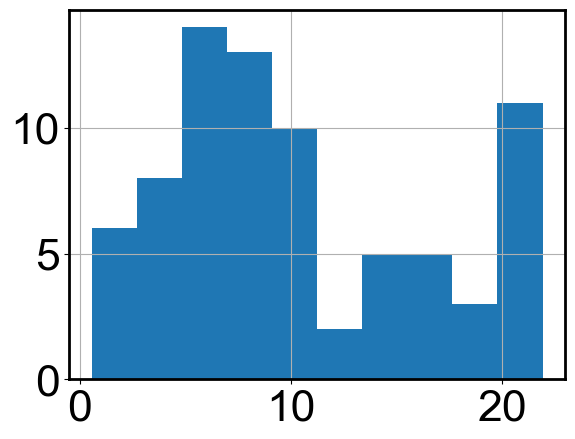

In [69]:
oa_data[oa_data.animal=='G8CK1LT'].distance_at_head_turn.hist()

<AxesSubplot: >

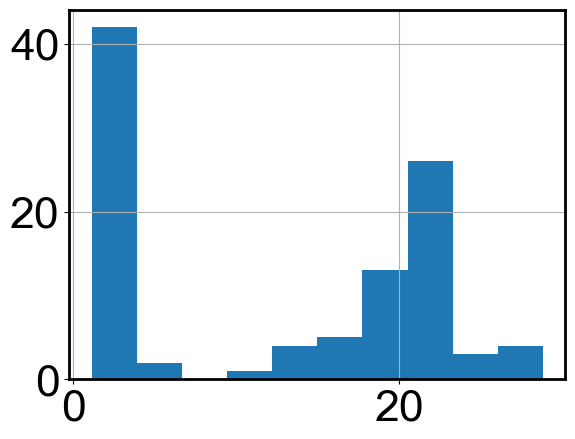

In [62]:
oadark_data[oadark_data.animal=='J704NN'].distance_at_head_turn.hist()


In [8]:
import pandas as pd
import numpy as np

# Filter and process data as before
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error < 0]
data = data[data.intial_distance >= 15]

# Create lists to store movement counts
movement_counts = []

# Process each row to count movements
for ind, row in data.iterrows():
    animal = row['animal']
    task = row['task']
    
    # Only process OA data (oadark or oa)
    if task not in ['oadark', 'oa']:
        continue
        
    # Get the largest turn (corner_turn_velocity)
    largest_turn = row['corner_turn_velocity'] * 60
    
    # Get other turns (corner_turn_velocities)
    other_turns = row['corner_turn_velocities'] * 60 if hasattr(row['corner_turn_velocities'], '__len__') else []
    
    # Count movements
    # Largest turn is always one movement
    num_largest = 1
    
    # Count other turns (only include if they exist)
    num_other = len(other_turns) if len(other_turns) > 0 else 0
    
    movement_counts.append({
        'animal': animal,
        'task': task,
        'num_largest': num_largest,
        'num_other': num_other,
        'total_movements': num_largest + num_other
    })

# Convert to DataFrame
movement_counts_df = pd.DataFrame(movement_counts)

# Function to calculate SEM
def sem(data):
    """Calculate standard error of the mean"""
    if len(data) > 0:
        return np.std(data, ddof=1) / np.sqrt(len(data))
    else:
        return 0

# Check if we have OA data
if len(movement_counts_df) > 0:
    print("TOTAL MOVEMENT COUNTS ANALYSIS")
    print("=" * 70)
    
    # 1. Calculate total counts across all trials
    total_largest_all = movement_counts_df['num_largest'].sum()
    total_other_all = movement_counts_df['num_other'].sum()
    total_all = total_largest_all + total_other_all
    
    print("1. TOTAL MOVEMENTS ACROSS ALL TRIALS:")
    print("-" * 40)
    print(f"   Largest movements: {total_largest_all:,}")
    print(f"   Other movements: {total_other_all:,}")
    print(f"   Total movements: {total_all:,}")
    print(f"   Proportion largest: {total_largest_all/total_all:.3f}")
    print(f"   Proportion other: {total_other_all/total_all:.3f}")
    
    # 2. Calculate total counts by condition
    print(f"\n2. TOTAL MOVEMENTS BY CONDITION:")
    print("-" * 40)
    
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        if len(condition_data) > 0:
            total_largest_cond = condition_data['num_largest'].sum()
            total_other_cond = condition_data['num_other'].sum()
            total_cond = total_largest_cond + total_other_cond
            
            print(f"\n   Condition: {condition}")
            print(f"   Largest movements: {total_largest_cond:,}")
            print(f"   Other movements: {total_other_cond:,}")
            print(f"   Total movements: {total_cond:,}")
            print(f"   Proportion largest: {total_largest_cond/total_cond:.3f}")
            print(f"   Proportion other: {total_other_cond/total_cond:.3f}")
            print(f"   Number of trials: {len(condition_data):,}")
    
    # 3. Calculate BETWEEN-ANIMAL AVERAGES (mean per animal)
    print(f"\n3. BETWEEN-ANIMAL AVERAGES (mean per animal):")
    print("-" * 40)
    
    # Calculate total counts per animal
    animal_totals = movement_counts_df.groupby('animal').agg({
        'num_largest': 'sum',
        'num_other': 'sum',
        'total_movements': 'sum',
        'task': 'count'  # Number of trials
    }).rename(columns={'task': 'num_trials'}).reset_index()
    
    # Calculate averages per animal
    animal_totals['largest_per_trial'] = animal_totals['num_largest'] / animal_totals['num_trials']
    animal_totals['other_per_trial'] = animal_totals['num_other'] / animal_totals['num_trials']
    animal_totals['total_per_trial'] = animal_totals['total_movements'] / animal_totals['num_trials']
    
    print(f"\n   Individual animal totals:")
    for _, row in animal_totals.iterrows():
        print(f"   {row['animal']}: Largest={row['num_largest']:,}, "
              f"Other={row['num_other']:,}, Total={row['total_movements']:,}, "
              f"Trials={row['num_trials']}")
    
    # Calculate between-animal statistics with SEM
    n_animals = len(animal_totals)
    between_animal_stats = {
        'mean_largest_per_animal': animal_totals['num_largest'].mean(),
        'sem_largest_per_animal': sem(animal_totals['num_largest']),
        'mean_other_per_animal': animal_totals['num_other'].mean(),
        'sem_other_per_animal': sem(animal_totals['num_other']),
        'mean_total_per_animal': animal_totals['total_movements'].mean(),
        'sem_total_per_animal': sem(animal_totals['total_movements']),
        'mean_largest_per_trial': animal_totals['largest_per_trial'].mean(),
        'sem_largest_per_trial': sem(animal_totals['largest_per_trial']),
        'mean_other_per_trial': animal_totals['other_per_trial'].mean(),
        'sem_other_per_trial': sem(animal_totals['other_per_trial']),
        'mean_total_per_trial': animal_totals['total_per_trial'].mean(),
        'sem_total_per_trial': sem(animal_totals['total_per_trial'])
    }
    
    print(f"\n   Between-animal statistics (averaging across {n_animals} animals):")
    print(f"   Largest movements per animal: {between_animal_stats['mean_largest_per_animal']:.1f} ± {between_animal_stats['sem_largest_per_animal']:.1f} (SEM)")
    print(f"   Other movements per animal: {between_animal_stats['mean_other_per_animal']:.1f} ± {between_animal_stats['sem_other_per_animal']:.1f} (SEM)")
    print(f"   Total movements per animal: {between_animal_stats['mean_total_per_animal']:.1f} ± {between_animal_stats['sem_total_per_animal']:.1f} (SEM)")
    
    print(f"\n   Per trial averages (between-animal means):")
    print(f"   Largest movements per trial: {between_animal_stats['mean_largest_per_trial']:.3f} ± {between_animal_stats['sem_largest_per_trial']:.3f} (SEM)")
    print(f"   Other movements per trial: {between_animal_stats['mean_other_per_trial']:.3f} ± {between_animal_stats['sem_other_per_trial']:.3f} (SEM)")
    print(f"   Total movements per trial: {between_animal_stats['mean_total_per_trial']:.3f} ± {between_animal_stats['sem_total_per_trial']:.3f} (SEM)")
    
    # 4. Calculate between-animal averages by condition
    print(f"\n4. BETWEEN-ANIMAL AVERAGES BY CONDITION:")
    print("-" * 40)
    
    for condition in ['oadark', 'oa']:
        condition_data = movement_counts_df[movement_counts_df['task'] == condition]
        if len(condition_data) > 0:
            # Calculate totals per animal for this condition
            animal_condition_totals = condition_data.groupby('animal').agg({
                'num_largest': 'sum',
                'num_other': 'sum',
                'total_movements': 'sum',
                'task': 'count'
            }).rename(columns={'task': 'num_trials'}).reset_index()
            
            # Calculate per trial averages per animal
            animal_condition_totals['largest_per_trial'] = animal_condition_totals['num_largest'] / animal_condition_totals['num_trials']
            animal_condition_totals['other_per_trial'] = animal_condition_totals['num_other'] / animal_condition_totals['num_trials']
            animal_condition_totals['total_per_trial'] = animal_condition_totals['total_movements'] / animal_condition_totals['num_trials']
            
            # Calculate between-animal means with SEM for this condition
            n_animals_cond = len(animal_condition_totals)
            mean_largest = animal_condition_totals['largest_per_trial'].mean()
            sem_largest = sem(animal_condition_totals['largest_per_trial'])
            mean_other = animal_condition_totals['other_per_trial'].mean()
            sem_other = sem(animal_condition_totals['other_per_trial'])
            mean_total = animal_condition_totals['total_per_trial'].mean()
            sem_total = sem(animal_condition_totals['total_per_trial'])
            
            print(f"\n   Condition: {condition}")
            print(f"   Number of animals: {n_animals_cond}")
            print(f"   Total trials: {len(condition_data)}")
            print(f"   Largest movements per trial (mean ± SEM): {mean_largest:.3f} ± {sem_largest:.3f}")
            print(f"   Other movements per trial (mean ± SEM): {mean_other:.3f} ± {sem_other:.3f}")
            print(f"   Total movements per trial (mean ± SEM): {mean_total:.3f} ± {sem_total:.3f}")
            print(f"   Proportion largest: {mean_largest/mean_total:.3f}")
            print(f"   Proportion other: {mean_other/mean_total:.3f}")
    
    # 5. Summary statistics
    print(f"\n5. SUMMARY STATISTICS:")
    print("-" * 40)
    print(f"   Total animals: {n_animals}")
    print(f"   Total trials: {len(movement_counts_df):,}")
    print(f"   Average trials per animal: {len(movement_counts_df)/n_animals:.1f}")
    print(f"   Range of trials per animal: {animal_totals['num_trials'].min()} - {animal_totals['num_trials'].max()}")
    
    # Save the data for further analysis
    print(f"\nData variables available:")
    print(f"   'movement_counts_df' - Raw movement counts per trial")
    print(f"   'animal_totals' - Total counts and per trial averages per animal")
    print(f"   'between_animal_stats' - Dictionary with between-animal statistics")
    
else:
    print("No OA data found after filtering")

TOTAL MOVEMENT COUNTS ANALYSIS
1. TOTAL MOVEMENTS ACROSS ALL TRIALS:
----------------------------------------
   Largest movements: 3,584
   Other movements: 8,641
   Total movements: 12,225
   Proportion largest: 0.293
   Proportion other: 0.707

2. TOTAL MOVEMENTS BY CONDITION:
----------------------------------------

   Condition: oadark
   Largest movements: 1,379
   Other movements: 3,506
   Total movements: 4,885
   Proportion largest: 0.282
   Proportion other: 0.718
   Number of trials: 1,379

   Condition: oa
   Largest movements: 2,205
   Other movements: 5,135
   Total movements: 7,340
   Proportion largest: 0.300
   Proportion other: 0.700
   Number of trials: 2,205

3. BETWEEN-ANIMAL AVERAGES (mean per animal):
----------------------------------------

   Individual animal totals:
   G8CK1LN: Largest=221, Other=361, Total=582, Trials=221
   G8CK1LT: Largest=225, Other=531, Total=756, Trials=225
   G8CK1RT: Largest=255, Other=400, Total=655, Trials=255
   G8CK1TT: Largest=